# 🎯 Trace the Ace — Phase 2: Advanced EDA
## Notebook 04 — Dialogue Sequence Dynamics

Hmm, Phase 1 is frozen ✅ — so now we can finally focus on the **conversation itself**.

In this notebook, we will study how Student–Tutor dialogue changes from the **start → middle → end** of a session: turn-taking, timing, activity, repetition, structural response patterns, and other temporal behaviour.

> **Important:** This notebook is objective-agnostic.  
> We are **not** measuring mastery or objective relevance yet.

Okay, let's move on 🚀

# 04.0 — Phase-2 Bootstrap 🚀

Alright, first we need a clean starting point.

Phase 1 already certified the data, so we won't repeat schema, duplicate, ordering, or integrity checks here. We only:

- confirm the final Phase-1 gate is ✅ PASS
- connect to the frozen canonical data
- load only the structural columns needed now
- prepare Notebook-04's output folder

`responses.parquet` will be used later in **04.7**, so there is no reason to load it yet.

Let's set things up 👇

In [1]:
from pathlib import Path
import json, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler



cwd = Path.cwd().resolve()
roots = [Path(os.environ["TRACE_THE_ACE_PROJECT_ROOT"]).expanduser().resolve()] if os.environ.get("TRACE_THE_ACE_PROJECT_ROOT") else []
roots += [cwd, *cwd.parents]

REGISTRY_PATH = next((r / "scratch_mastery_outputs" / "00_project_setup" / "path_registry.json" for r in roots
                      if (r / "scratch_mastery_outputs" / "00_project_setup" / "path_registry.json").exists()), None)
if REGISTRY_PATH is None: raise FileNotFoundError("path_registry.json not found from the current project tree.")

with REGISTRY_PATH.open(encoding="utf-8") as f: paths = json.load(f)

PROJECT_ROOT = Path(paths["project_root"])
SCRATCH_OUTPUT_ROOT = Path(paths["scratch_output_root"])
FOUNDATION_ROOT = SCRATCH_OUTPUT_ROOT / "01_data_foundation"
INTEGRITY_DIR = FOUNDATION_ROOT / "03_integrity"
CANONICAL_DIR = INTEGRITY_DIR / "canonical"

PHASE1_GATE_PATH = INTEGRITY_DIR / "phase1_gate.json"
TURNS_PATH = CANONICAL_DIR / "turns.parquet"
SESSIONS_PATH = CANONICAL_DIR / "sessions.parquet"
RESPONSES_PATH = CANONICAL_DIR / "responses.parquet"

OUTPUT_DIR = SCRATCH_OUTPUT_ROOT / "02_advanced_eda" / "04_dialogue_sequence_dynamics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with PHASE1_GATE_PATH.open(encoding="utf-8") as f: phase1_gate = json.load(f)

assert phase1_gate["PHASE_1_FOUNDATION_READY"]
assert phase1_gate["canonical_publication_ready"]
assert phase1_gate["hard_gates_passed"] == phase1_gate["hard_gates_total"]

print("Phase 1 gate       : PASS ✅")
print(f"Canonical source    : {CANONICAL_DIR}")
print(f"Notebook-04 outputs : {OUTPUT_DIR}")

Phase 1 gate       : PASS ✅
Canonical source    : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\scratch_mastery_outputs\01_data_foundation\03_integrity\canonical
Notebook-04 outputs : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\scratch_mastery_outputs\02_advanced_eda\04_dialogue_sequence_dynamics


## Load the structural working data 📦

Oh, one important thing — `turns.parquet` has millions of rows, so loading every column would be wasteful.

For now, we only need the already-frozen **sequence + role + time** fields. Text-heavy columns will be loaded later only when a section actually needs them.

So our main working objects will be:

- `turns_core` → ordered turn-level structural information
- `sessions` → one row per tutoring session

Nice and simple 🙂

In [2]:
TURN_CORE_COLS = [
    "session_id", "turn_index", "role", "relative_turn_position",
    "previous_role", "next_role", "speaker_switch",
    "time_since_previous_turn", "elapsed_from_session_start"
]

SESSION_CORE_COLS = ["session_id", "n_turns", "duration_seconds"]

turns_core = pd.read_parquet(TURNS_PATH, columns=TURN_CORE_COLS)
sessions = pd.read_parquet(SESSIONS_PATH, columns=SESSION_CORE_COLS)

print(f"Sessions loaded : {len(sessions):,}")
print(f"Turns loaded    : {len(turns_core):,}")
print(f"Turn columns    : {len(turns_core.columns)}")
print("04.0 Bootstrap : READY ✅")

display(turns_core.head())
sessions.head()

Sessions loaded : 22,821
Turns loaded    : 6,139,854
Turn columns    : 9
04.0 Bootstrap : READY ✅


,session_id,turn_index,role,relative_turn_position,previous_role,next_role,speaker_switch,time_since_previous_turn,elapsed_from_session_start
0,aaaedit,0,tutor,0.000000,None,background,False,NaN,0.0
1,aaaedit,1,background,0.003953,tutor,background,True,0.0,0.0
2,aaaedit,2,background,0.007905,background,tutor,False,1.0,1.0
3,aaaedit,3,tutor,0.011858,background,student,True,0.0,1.0
4,aaaedit,4,student,0.015810,tutor,tutor,True,6.0,7.0


,session_id,n_turns,duration_seconds
0,aaaedit,254,2629.0
1,aaaptjd,360,2730.0
2,aabkeov,281,2208.0
3,aacggvb,235,2776.0
4,aadexbc,104,2642.0


### 🧰 Notebook-04 Helper Utilities

Okay, we'll keep the reusable logic in one small place.

This class will only contain helpers that are genuinely reused across Notebook 04 — things like temporal summaries and plots.  
We'll extend it gradually as new sections need something reusable.

> No giant analyzer, no duplicate logic — just small shared utilities 🙂

In [3]:
class DialogueEDAUtils:
    @staticmethod
    def style_ax(ax, title, xlabel, ylabel):
        ax.set_title(title, pad=10, fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.spines[["top", "right"]].set_visible(False)
        return ax

    @staticmethod
    def temporal_bins(turn_index, n_turns, n_bins):
        bins = (turn_index.to_numpy() * n_bins) // (n_turns - 1)
        return np.minimum(bins, n_bins - 1).astype("int8")

# 04.1 — Two Temporal Coordinates ⏱️

Hmm, conversation time can mean two different things.

### 🔄 Turn-progress clock

`relative_turn_position` tells us **where a turn sits inside its own session**:

$$
u_t = \frac{t}{n_{\text{turns}} - 1}
$$

So roughly:

- `0.0` → start
- `0.5` → middle
- `1.0` → end

This lets us compare sessions even when their turn counts are very different.

### ⏱️ Wall-time clock

`elapsed_from_session_start` tells us how much **real interaction time** has passed.

A session can move quickly through many turns, while another may take much longer for the same number of turns.

Both clocks are already frozen in the canonical data, so we will **reuse them rather than rebuild them**.

Okay, let's see their scale 👇

In [4]:
session_clock = sessions[["session_id", "n_turns", "duration_seconds"]].copy()
session_clock["turn_step_pct"] = 100 / (session_clock["n_turns"] - 1)
session_clock["duration_minutes"] = session_clock["duration_seconds"] / 60
session_clock["avg_seconds_per_transition"] = session_clock["duration_seconds"] / (session_clock["n_turns"] - 1)

median_gap = (
    turns_core.loc[turns_core["turn_index"].gt(0)]
    .groupby("session_id", sort=False)["time_since_previous_turn"]
    .median()
    .rename("median_interturn_seconds")
)

session_clock = session_clock.join(median_gap, on="session_id")

summary_cols = ["n_turns", "turn_step_pct", "duration_minutes", "avg_seconds_per_transition", "median_interturn_seconds"]
clock_summary = session_clock[summary_cols].quantile([.10, .25, .50, .75, .90]).T
clock_summary.columns = ["p10", "p25", "median", "p75", "p90"]

display(clock_summary.round(3))
session_clock.head()

print(f"Sessions                : {len(session_clock):,}")
print(f"Median turns            : {session_clock['n_turns'].median():.0f}")
print(f"Median duration         : {session_clock['duration_minutes'].median():.2f} min")
print(f"Median progress / turn  : {session_clock['turn_step_pct'].median():.3f}%")
print(f"Median inter-turn gap   : {session_clock['median_interturn_seconds'].median():.2f} sec")

,p10,p25,median,p75,p90
n_turns,179.000,222.000,267.000,316.000,362.000
turn_step_pct,0.277,0.317,0.376,0.452,0.562
duration_minutes,34.167,39.183,43.383,45.083,45.883
avg_seconds_per_transition,7.123,8.077,9.345,10.971,13.042
median_interturn_seconds,4.000,5.000,6.000,7.000,8.000


Sessions                : 22,821
Median turns            : 267
Median duration         : 43.38 min
Median progress / turn  : 0.376%
Median inter-turn gap   : 6.00 sec


## Temporal scale at a glance 📊

Oh, instead of plotting all normalized turn positions directly, we'll look at something more useful:

1. how fine the turn-progress clock is across sessions,
2. how long sessions actually last,
3. how turn count and real duration move together.

One session stays one observation here — no turn-level pseudo-replication.

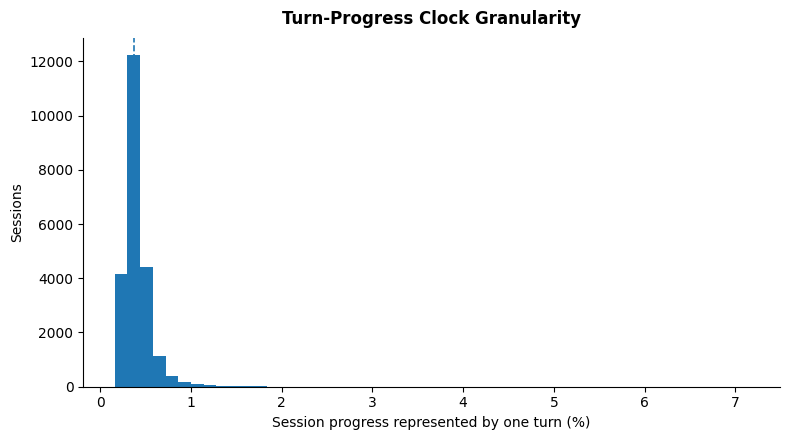

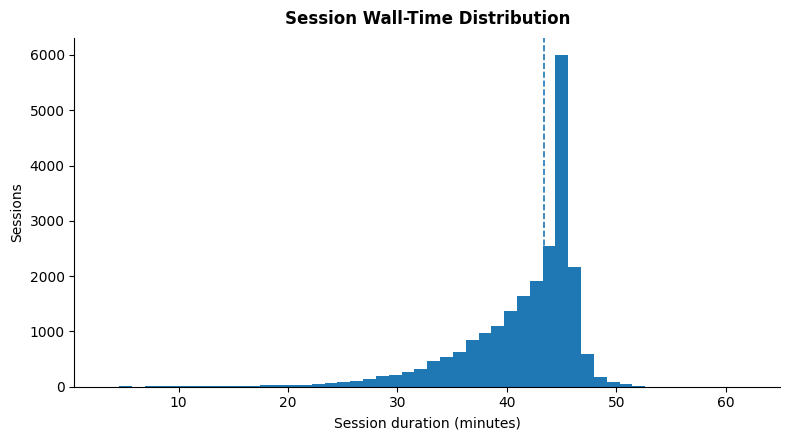

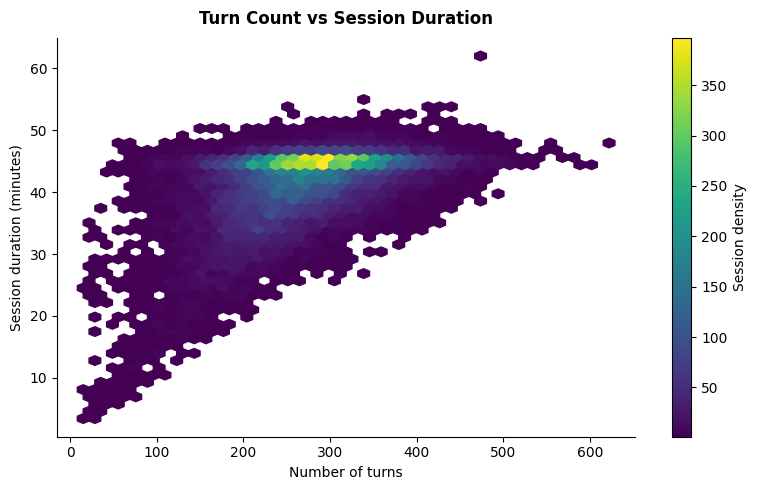

In [5]:
def plot_turn_progress(clock):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(clock["turn_step_pct"], bins=50)
    ax.axvline(clock["turn_step_pct"].median(), linestyle="--", linewidth=1.2)
    DialogueEDAUtils.style_ax(
        ax,
        "Turn-Progress Clock Granularity",
        "Session progress represented by one turn (%)",
        "Sessions"
    )
    fig.tight_layout()
    return fig


def plot_wall_time(clock):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(clock["duration_minutes"], bins=50)
    ax.axvline(clock["duration_minutes"].median(), linestyle="--", linewidth=1.2)
    DialogueEDAUtils.style_ax(
        ax,
        "Session Wall-Time Distribution",
        "Session duration (minutes)",
        "Sessions"
    )
    fig.tight_layout()
    return fig


def plot_turns_vs_duration(clock):
    fig, ax = plt.subplots(figsize=(8, 5))
    hb = ax.hexbin(clock["n_turns"], clock["duration_minutes"], gridsize=45, mincnt=1)
    DialogueEDAUtils.style_ax(
        ax,
        "Turn Count vs Session Duration",
        "Number of turns",
        "Session duration (minutes)"
    )
    fig.colorbar(hb, ax=ax, label="Session density")
    fig.tight_layout()
    return fig

figs = [
    plot_turn_progress(session_clock),
    plot_wall_time(session_clock),
    plot_turns_vs_duration(session_clock)
]

for fig in figs:
    plt.show()
    plt.close(fig)

### 04.1 — Insight 💡

Hmm, the two clocks are clearly capturing different parts of the dialogue.

Most sessions have a **fine turn-progress resolution**, so normalized 3 / 5 / 10-bin trajectories should work well for the majority of sessions. Wall time, however, is strongly concentrated around **~44–46 minutes**, while turn counts vary widely even within that same duration range.

The turn-count vs duration pattern also looks **nonlinear** — session duration tends to plateau while conversational density keeps changing.

> **Takeaway:** relative turn position is the better clock for aligning dialogue trajectories, while wall time and inter-turn pace provide complementary information about **how quickly the interaction unfolds**. ⏱️

# 04.2 — Multi-Resolution Dialogue Trajectories 🧭

Okay, now we can divide each conversation into comparable temporal regions.

But relying on only one split could be misleading, so we'll create the same timeline at three resolutions:

- **3 bins** → broad `early → middle → late`
- **5 bins** → medium-resolution progression
- **10 bins** → finer dialogue movement

For a session with relative position \(u_t\), the temporal bin is:

$$
b_t=\min\left(\lfloor u_tB \rfloor,\ B-1\right)
$$

where \(B\) is the number of bins.

We'll keep the stored bin values as simple integers `0 ... B-1`.  
Hmm, that makes later aggregation much cleaner and avoids maintaining different label systems for each resolution.

Let's build them 👇

In [6]:
n_turns = turns_core["session_id"].map(sessions.set_index("session_id")["n_turns"])

turns_core["bin_3"] = DialogueEDAUtils.temporal_bins(turns_core["turn_index"], n_turns, 3)
turns_core["bin_5"] = DialogueEDAUtils.temporal_bins(turns_core["turn_index"], n_turns, 5)
turns_core["bin_10"] = DialogueEDAUtils.temporal_bins(turns_core["turn_index"], n_turns, 10)

print(f"3-bin range  : {turns_core['bin_3'].min()} → {turns_core['bin_3'].max()}")
print(f"5-bin range  : {turns_core['bin_5'].min()} → {turns_core['bin_5'].max()}")
print(f"10-bin range : {turns_core['bin_10'].min()} → {turns_core['bin_10'].max()}")

turns_core.head(250)

3-bin range  : 0 → 2
5-bin range  : 0 → 4
10-bin range : 0 → 9


,session_id,turn_index,role,relative_turn_position,previous_role,next_role,speaker_switch,time_since_previous_turn,elapsed_from_session_start,bin_3,bin_5,bin_10
0,aaaedit,0,tutor,0.000000,None,background,False,NaN,0.0,0,0,0
1,aaaedit,1,background,0.003953,tutor,background,True,0.0,0.0,0,0,0
2,aaaedit,2,background,0.007905,background,tutor,False,1.0,1.0,0,0,0
3,aaaedit,3,tutor,0.011858,background,student,True,0.0,1.0,0,0,0
4,aaaedit,4,student,0.015810,tutor,tutor,True,6.0,7.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
245,aaaedit,245,student,0.968379,tutor,tutor,True,1.0,2578.0,2,4,9
246,aaaedit,246,tutor,0.972332,student,student,True,2.0,2580.0,2,4,9
247,aaaedit,247,student,0.976285,tutor,tutor,True,6.0,2586.0,2,4,9
248,aaaedit,248,tutor,0.980237,student,student,True,1.0,2587.0,2,4,9


In [7]:
bin_summary = pd.concat([
    turns_core["bin_3"].value_counts().sort_index().rename("turns").to_frame().assign(resolution=3),
    turns_core["bin_5"].value_counts().sort_index().rename("turns").to_frame().assign(resolution=5),
    turns_core["bin_10"].value_counts().sort_index().rename("turns").to_frame().assign(resolution=10)
]).reset_index(names="bin")

bin_summary["turn_share"] = bin_summary.groupby("resolution")["turns"].transform(lambda x: x / x.sum())

display(bin_summary[["resolution", "bin", "turns", "turn_share"]].style.format({
    "turns": "{:,.0f}",
    "turn_share": "{:.2%}"
}))

,resolution,bin,turns,turn_share
0,3,0,"2,046,625",33.33%
1,3,1,"2,039,059",33.21%
2,3,2,"2,054,170",33.46%
3,5,0,"1,232,543",20.07%
4,5,1,"1,223,420",19.93%
5,5,2,"1,223,333",19.92%
6,5,3,"1,223,420",19.93%
7,5,4,"1,237,138",20.15%
8,10,0,"621,976",10.13%
9,10,1,"610,567",9.94%


### 04.2 — Insight 💡

Nice — all three temporal resolutions are very evenly populated.

- **3-bin:** each region contains roughly one-third of all turns
- **5-bin:** each region stays close to 20%
- **10-bin:** each region stays close to 10%

The small edge-bin differences are expected from finite session lengths and deterministic boundary assignment.

> **Takeaway:** our 3 / 5 / 10-bin timelines are well balanced and do not introduce any meaningful temporal weighting bias. We can safely use them to compare dialogue behaviour across resolutions. ✅

# 04.3 — Role Transition System 🔄

Okay, now we move from **how much each role speaks** to **how the dialogue actually moves between roles**.

We'll study five related pieces:

- Student / Tutor / Background composition
- role dominance
- who tends to speak after whom
- speaker switching and uninterrupted role runs
- how predictable the next-speaker pattern is

The important part is that all transition metadata is already canonical — we will **reuse `role`, `next_role`, `previous_role`, and `speaker_switch` rather than reconstruct them**.

Hmm, let's map the turn-taking structure 👇

In [8]:
ROLES = ["student", "tutor", "background"]

def role_composition(turns):
    counts = turns.groupby(["session_id", "role"], sort=False).size().unstack(fill_value=0).reindex(columns=ROLES, fill_value=0)
    out = counts.div(counts.sum(axis=1), axis=0).add_suffix("_share")

    ped = counts[["student", "tutor"]]
    out["pedagogical_dominance"] = ped.max(axis=1) / ped.sum(axis=1)
    out["dominant_role"] = np.select(
        [ped["student"] > ped["tutor"], ped["tutor"] > ped["student"]],
        ["student", "tutor"], default="balanced"
    )
    return out.reset_index()


def transition_summary(turns):
    tr = turns.loc[turns["next_role"].notna(), ["session_id", "role", "next_role", "speaker_switch"]]

    # Global P(next role | current role)
    matrix = pd.crosstab(tr["role"], tr["next_role"]).reindex(index=ROLES, columns=ROLES, fill_value=0)
    matrix = matrix.div(matrix.sum(axis=1), axis=0)

    # Session-level transition probabilities
    x = tr.groupby(["session_id", "role", "next_role"], sort=False).size().rename("count").reset_index()
    x["prob"] = x["count"] / x.groupby(["session_id", "role"])["count"].transform("sum")

    probs = x.pivot(index="session_id", columns=["role", "next_role"], values="prob")
    probs = probs.reindex(columns=pd.MultiIndex.from_product([ROLES, ROLES]))
    probs.columns = [f"p_{dst}_given_{src}" for src, dst in probs.columns]

    # Speaker switching
    switch = tr.groupby("session_id")["speaker_switch"].mean().rename("speaker_switch_rate")
    st = tr[tr["role"].isin(["student", "tutor"]) & tr["next_role"].isin(["student", "tutor"])]
    st_switch = st.groupby("session_id")["speaker_switch"].mean().rename("student_tutor_switch_rate")

    # Normalized conditional transition entropy
    x["entropy_part"] = -(x["prob"] * np.log(x["prob"])) / np.log(len(ROLES))
    entropy = x.groupby(["session_id", "role"]).agg(entropy=("entropy_part", "sum"), support=("count", "sum")).reset_index()
    entropy["weighted"] = entropy["entropy"] * entropy["support"]
    entropy = (entropy.groupby("session_id")["weighted"].sum() / entropy.groupby("session_id")["support"].sum()).rename("transition_entropy")

    return matrix, probs.join(switch).join(st_switch).join(entropy).reset_index()


def role_run_summary(turns):
    new_run = turns["previous_role"].isna() | turns["role"].ne(turns["previous_role"])
    run_id = new_run.groupby(turns["session_id"], sort=False).cumsum()

    runs = (
        pd.DataFrame({"session_id": turns["session_id"], "role": turns["role"], "run_id": run_id})
        .groupby(["session_id", "role", "run_id"], sort=False).size()
        .rename("run_length").reset_index()
    )

    out = runs.groupby(["session_id", "role"])["run_length"].agg(["mean", "max"]).unstack("role")
    out = out.reindex(columns=pd.MultiIndex.from_product([["mean", "max"], ROLES]))
    out.columns = [f"{role}_run_{stat}" for stat, role in out.columns]
    return out.reset_index()


role_stats = role_composition(turns_core)
global_transition_prob, transition_stats = transition_summary(turns_core)
run_stats = role_run_summary(turns_core)

session_role_dynamics = (
    role_stats
    .merge(transition_stats, on="session_id", validate="1:1")
    .merge(run_stats, on="session_id", validate="1:1")
)

print(f"Sessions summarized : {len(session_role_dynamics):,}")
print(f"Role metrics        : {session_role_dynamics.shape[1] - 1}")

display(run_stats.head())
display(role_stats.head())
display(global_transition_prob.head())
display(transition_stats.head())

Sessions summarized : 22,821
Role metrics        : 23


,session_id,student_run_mean,tutor_run_mean,background_run_mean,student_run_max,tutor_run_max,background_run_max
0,aaaedit,1.175258,1.346535,1.333333,4.0,6.0,2.0
1,aaaptjd,1.163399,1.078431,1.000000,3.0,2.0,1.0
2,aabkeov,1.162393,1.170940,1.000000,4.0,3.0,1.0
3,aacggvb,1.191489,1.255319,1.250000,3.0,3.0,2.0
4,aadexbc,1.052632,3.857143,1.000000,2.0,24.0,1.0


role,session_id,student_share,tutor_share,background_share,pedagogical_dominance,dominant_role
0,aaaedit,0.448819,0.535433,0.015748,0.544000,tutor
1,aaaptjd,0.494444,0.458333,0.047222,0.518950,student
2,aabkeov,0.483986,0.487544,0.028470,0.501832,tutor
3,aacggvb,0.476596,0.502128,0.021277,0.513043,tutor
4,aadexbc,0.192308,0.778846,0.028846,0.801980,tutor


next_role,student,tutor,background
role,,,
student,0.107913,0.863222,0.028864
tutor,0.728325,0.224974,0.046701
background,0.348589,0.618387,0.033024


,session_id,p_student_given_student,p_tutor_given_student,p_background_given_student,p_student_given_tutor,p_tutor_given_tutor,p_background_given_tutor,p_student_given_background,p_tutor_given_background,p_background_given_background,speaker_switch_rate,student_tutor_switch_rate,transition_entropy
0,aaaedit,0.149123,0.850877,NaN,0.718519,0.259259,0.022222,NaN,0.750000,0.25,0.786561,0.788618,0.507275
1,aaaptjd,0.141243,0.819209,0.039548,0.872727,0.072727,0.054545,0.529412,0.470588,NaN,0.894150,0.889571,0.480340
2,aabkeov,0.139706,0.816176,0.044118,0.838235,0.147059,0.014706,0.250000,0.750000,NaN,0.860714,0.859848,0.487825
3,aacggvb,0.162162,0.837838,NaN,0.771186,0.203390,0.025424,0.600000,0.200000,0.20,0.811966,0.823009,0.493374
4,aadexbc,0.050000,0.900000,0.050000,0.237500,0.750000,0.012500,NaN,1.000000,NaN,0.407767,0.397959,0.502355


In [9]:
summary_cols = [
    "student_share", "tutor_share", "background_share",
    "pedagogical_dominance", "speaker_switch_rate", "student_tutor_switch_rate",
    "student_run_mean", "student_run_max",
    "tutor_run_mean", "tutor_run_max", "transition_entropy"
]

role_summary = session_role_dynamics[summary_cols].quantile([.10, .25, .50, .75, .90]).T
role_summary.columns = ["p10", "p25", "median", "p75", "p90"]

print("Global transition probability")
display(global_transition_prob.style.format("{:.2%}"))

print("\nSession-level role dynamics")
display(role_summary.round(3))

print("\nDominant pedagogical role")
display(
    session_role_dynamics["dominant_role"]
    .value_counts(normalize=True)
    .rename("session_share")
    .to_frame()
    .style.format("{:.2%}")
)

Global transition probability


next_role,student,tutor,background
role,,,
student,10.79%,86.32%,2.89%
tutor,72.83%,22.50%,4.67%
background,34.86%,61.84%,3.30%



Session-level role dynamics


,p10,p25,median,p75,p90
student_share,0.365,0.410,0.446,0.473,0.493
tutor_share,0.477,0.496,0.518,0.546,0.580
background_share,0.011,0.019,0.032,0.051,0.077
pedagogical_dominance,0.507,0.518,0.540,0.571,0.611
speaker_switch_rate,0.734,0.790,0.833,0.866,0.888
student_tutor_switch_rate,0.727,0.784,0.829,0.863,0.888
student_run_mean,1.048,1.074,1.110,1.158,1.223
student_run_max,2.000,2.000,3.000,3.000,4.000
tutor_run_mean,1.135,1.190,1.272,1.395,1.588
tutor_run_max,3.000,3.000,4.000,5.000,7.000



Dominant pedagogical role


,session_share
dominant_role,
tutor,85.34%
student,13.41%
balanced,1.24%


## Role dynamics at a glance 📊

Nice, now let's visualize the three main structural patterns:

- **Who usually follows whom?**
- **How often does the speaker change?**
- **How balanced are Student and Tutor turns?**

We'll keep run-length and entropy in the numerical summary for now unless they show something worth exploring further.

In [10]:
def plot_transition_matrix(matrix):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    im = ax.imshow(matrix)

    ax.set_xticks(range(len(ROLES)), [r.title() for r in ROLES])
    ax.set_yticks(range(len(ROLES)), [r.title() for r in ROLES])

    for i in range(len(ROLES)):
        for j in range(len(ROLES)):
            ax.text(j, i, f"{matrix.iloc[i, j]:.1%}", ha="center", va="center")

    DialogueEDAUtils.style_ax(ax, "Global Role Transition Probability", "Next role", "Current role")
    fig.colorbar(im, ax=ax, label="Probability")
    fig.tight_layout()
    return fig


def plot_switch_rates(data):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(
        [data["speaker_switch_rate"].dropna(), data["student_tutor_switch_rate"].dropna()],
        bins=40, alpha=.65, label=["All roles", "Student ↔ Tutor"]
    )
    DialogueEDAUtils.style_ax(ax, "Speaker-Switch Rate", "Switch rate", "Sessions")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


def plot_role_dominance(data):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(data["pedagogical_dominance"], bins=40)
    ax.axvline(data["pedagogical_dominance"].median(), linestyle="--")
    DialogueEDAUtils.style_ax(
        ax, "Student–Tutor Role Dominance",
        "Dominance (0.5 = balanced, 1.0 = fully dominated)", "Sessions"
    )
    fig.tight_layout()
    return fig

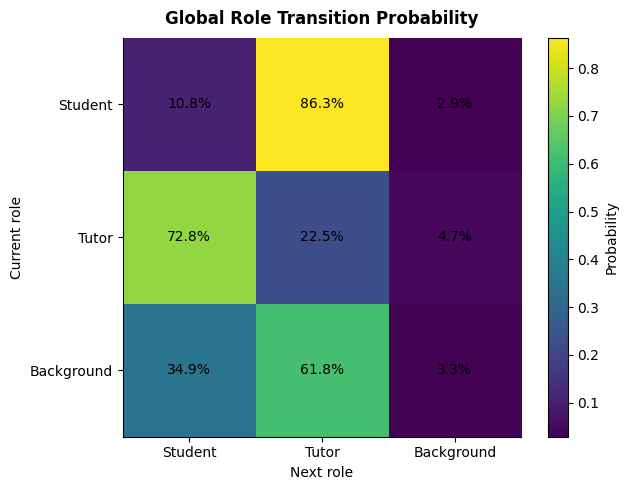

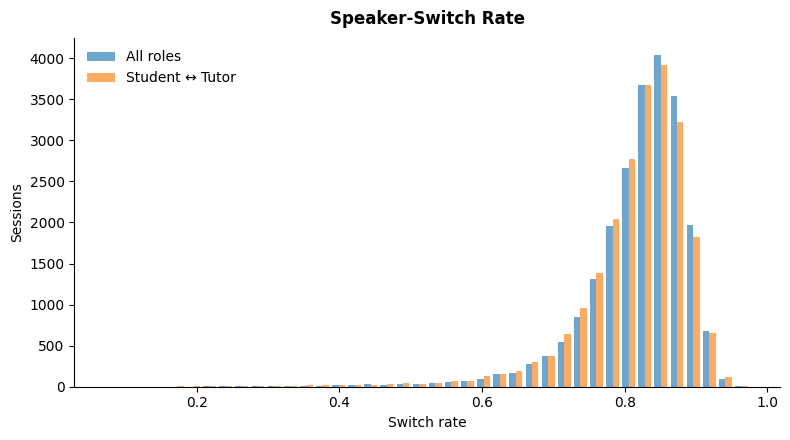

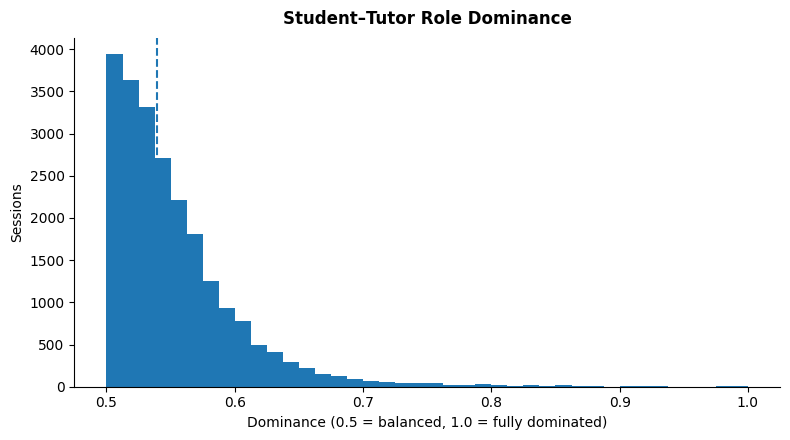

In [11]:
figs = [
    plot_transition_matrix(global_transition_prob),
    plot_switch_rates(session_role_dynamics),
    plot_role_dominance(session_role_dynamics)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.3 — Insight 💡

Oh, the dialogue structure is strongly interactive.

Student turns are followed by Tutor turns **86.3%** of the time, while Tutor turns return to Student **72.8%** of the time. Speaker switching is also high across most sessions, with the main distribution concentrated around roughly **0.8–0.9**.

At the same time, Student–Tutor turn volume is usually quite balanced — most sessions stay close to the `0.5` dominance boundary — although a small tail contains strongly role-dominated conversations.

One interesting asymmetry remains: **Tutor → Tutor (22.5%)** is notably more common than **Student → Student (10.8%)**, suggesting Tutor speech more often forms short consecutive blocks.

> **Takeaway:** the corpus is dominated by rapid Student–Tutor alternation rather than long single-speaker monologues, making local role sequences especially meaningful for the next structural-cycle analysis. 🔄

# 04.4 — Structural Response Cycles 🔁

Okay, now we'll look at **local dialogue patterns** rather than only overall role transitions.

We'll track four neutral structural patterns:

- `Tutor → Student`
- `Student → Tutor → Student`
- `Tutor → Tutor → Student`
- `Student → Student`

These patterns are structural only — a Tutor turn is **not automatically feedback, correction, or scaffolding**.

For the main `Student → Tutor → Student` cycle, we'll compare:

```text
PRE-STUDENT → TUTOR ANCHOR → POST-STUDENT

In [12]:
TEXT_COLS = ["session_id", "turn_index", "text_norm", "content_hash"]

turn_text_metrics = pd.read_parquet(TURNS_PATH, columns=TEXT_COLS)
turn_text_metrics = turn_text_metrics.merge(
    turns_core[["session_id", "turn_index", "role", "time_since_previous_turn"]],
    on=["session_id", "turn_index"], validate="1:1"
)

NUMBER_PATTERN = r"(?<!\w)\d+(?:\.\d+)?(?:/\d+(?:\.\d+)?)?(?!\w)"
MATH_PATTERN = r"[+\-×÷*/=<>≤≥^%]"

turn_text_metrics["word_count"] = turn_text_metrics["text_norm"].str.count(r"\S+").astype("int16")
turn_text_metrics["numeric_count"] = turn_text_metrics["text_norm"].str.count(NUMBER_PATTERN).astype("int16")
turn_text_metrics["math_count"] = turn_text_metrics["text_norm"].str.count(MATH_PATTERN).astype("int16")

display(turn_text_metrics.head(100))



,session_id,turn_index,text_norm,content_hash,role,time_since_previous_turn,word_count,numeric_count,math_count
0,aaaedit,0,Hello?,c36b40652bc4e6a89a36d5fd0a79cacb49f113c865de86...,tutor,NaN,1,0,0
1,aaaedit,1,[unclear],239674fd86ecd7be8672a4f17e6de45a479c64086d40bb...,background,0.0,1,0,0
2,aaaedit,2,Hello.,4487548212d8f2f4736ac097d1a3043ffa5f56459056b8...,background,1.0,1,0,0
3,aaaedit,3,"Hi, Lachlan. How are you doing today?",6b610cd18373d7c9bb11b884b2f5a1aa62152d1838b9e0...,tutor,0.0,7,0,0
4,aaaedit,4,Good.,22c16c191562325739cf592873463b98dcee8635a53e52...,student,6.0,1,0,0
...,...,...,...,...,...,...,...,...,...
95,aaaedit,95,So which numbers are we going to add first? [u...,eb32d4de7c749848abb11abbf717bd32b9086bedd20131...,tutor,26.0,11,0,0
96,aaaedit,96,[UNCLEAR] [unclear],f46f06c1163838ffc9dcb00e924b56c40317e7edf4327e...,student,0.0,2,0,0
97,aaaedit,97,[unclear] [unclear],f5faa690f1cf746efd0807869f374acf6a1c9ffd65d041...,student,0.0,2,0,0
98,aaaedit,98,"All right, what do we do next? [unclear]",6a3e4d460728e7d3900b92c459769075e4507b87b64ba7...,tutor,64.0,8,0,0


In [13]:
def structural_cycles(turns):
    masks = {
        "tutor_student": turns["role"].eq("tutor") & turns["next_role"].eq("student"),
        "student_tutor_student": turns["previous_role"].eq("student") & turns["role"].eq("tutor") & turns["next_role"].eq("student"),
        "tutor_tutor_student": turns["previous_role"].eq("tutor") & turns["role"].eq("tutor") & turns["next_role"].eq("student"),
        "student_student": turns["role"].eq("student") & turns["next_role"].eq("student")
    }

    counts = pd.concat(
        {name: turns.loc[mask].groupby("session_id", sort=False).size() for name, mask in masks.items()},
        axis=1
    ).fillna(0).astype("int32")

    counts = (
        turns[["session_id"]].drop_duplicates().set_index("session_id")
        .join(counts).fillna(0).astype("int32")
    )
    counts.columns = [f"n_{c}" for c in counts.columns]

    census = pd.DataFrame({
        "cycles": counts.sum(),
        "sessions": counts.gt(0).sum()
    })
    census["session_share"] = census["sessions"] / len(counts)

    anchors = (
        turns.loc[masks["student_tutor_student"], ["session_id", "turn_index"]]
        .rename(columns={"turn_index": "anchor_turn_index"})
        .reset_index(drop=True)
    )

    return counts.reset_index(), census.rename_axis("pattern").reset_index(), anchors





cycle_counts, pattern_census, sts_anchors = structural_cycles(turns_core)
display(
    pattern_census.style.format({
        "cycles": "{:,.0f}",
        "sessions": "{:,.0f}",
        "session_share": "{:.2%}"
    })
)
print(f"Student → Tutor → Student cycles : {len(sts_anchors):,}")

,pattern,cycles,sessions,session_share
0,n_tutor_student,"2,320,538","22,816",99.98%
1,n_student_tutor_student,"1,745,545","22,796",99.89%
2,n_tutor_tutor_student,"497,352","22,811",99.96%
3,n_student_student,"289,845","22,551",98.82%


Student → Tutor → Student cycles : 1,745,545


## Student → Tutor → Student cycle 🎯

Now we'll focus on the one pattern where a genuine **Student-before and Student-after comparison** exists:

```text
PRE-STUDENT
     ↓
TUTOR ANCHOR
     ↓
POST-STUDENT

In [14]:
CYCLE_COLS = [
    "text_norm", "content_hash", "word_count",
    "numeric_count", "math_count", "time_since_previous_turn"
]

def cycle_view(df, prefix):
    rename = {"turn_index": f"{prefix}_turn_index", **{c: f"{prefix}_{c}" for c in CYCLE_COLS}}
    return df[["session_id", "turn_index", *CYCLE_COLS]].rename(columns=rename)

sts_cycles = sts_anchors.assign(
    pre_turn_index=sts_anchors["anchor_turn_index"] - 1,
    post_turn_index=sts_anchors["anchor_turn_index"] + 1
)
sts_cycles = (
    sts_cycles
    .merge(cycle_view(turn_text_metrics, "pre"), on=["session_id", "pre_turn_index"], how="left", validate="1:1")
    .merge(cycle_view(turn_text_metrics, "anchor"), on=["session_id", "anchor_turn_index"], how="left", validate="1:1")
    .merge(cycle_view(turn_text_metrics, "post"), on=["session_id", "post_turn_index"], how="left", validate="1:1")
)

def lexical_novelty(a, b):
    a, b = set(a.lower().split()), set(b.lower().split())
    union = a | b
    return 1 - len(a & b) / len(union) if union else 0.0

def anchor_post_overlap(anchor, post):
    anchor, post = set(anchor.lower().split()), set(post.lower().split())
    return len(anchor & post) / len(post) if post else 0.0



sts_cycles["delta_word_count"] = sts_cycles["post_word_count"] - sts_cycles["pre_word_count"]
sts_cycles["delta_numeric_count"] = sts_cycles["post_numeric_count"] - sts_cycles["pre_numeric_count"]
sts_cycles["delta_math_count"] = sts_cycles["post_math_count"] - sts_cycles["pre_math_count"]

sts_cycles["lexical_novelty"] = np.fromiter(
    (lexical_novelty(a, b) for a, b in zip(sts_cycles["pre_text_norm"], sts_cycles["post_text_norm"])),
    dtype="float32", count=len(sts_cycles)
)

sts_cycles["anchor_post_overlap"] = np.fromiter(
    (anchor_post_overlap(a, b) for a, b in zip(sts_cycles["anchor_text_norm"], sts_cycles["post_text_norm"])),
    dtype="float32", count=len(sts_cycles)
)

sts_cycles["post_latency_seconds"] = sts_cycles["post_time_since_previous_turn"]
sts_cycles["post_exact_anchor_match"] = sts_cycles["post_content_hash"].eq(sts_cycles["anchor_content_hash"])

n_sts = sts_cycles.groupby("session_id")["anchor_turn_index"].transform("size")
sts_cycles["session_weight"] = 1 / n_sts

In [15]:
sts_cycles.head(100)

,session_id,anchor_turn_index,pre_turn_index,post_turn_index,pre_text_norm,pre_content_hash,pre_word_count,pre_numeric_count,pre_math_count,pre_time_since_previous_turn,...,post_math_count,post_time_since_previous_turn,delta_word_count,delta_numeric_count,delta_math_count,lexical_novelty,anchor_post_overlap,post_latency_seconds,post_exact_anchor_match,session_weight
0,aaaedit,5,4,6,Good.,22c16c191562325739cf592873463b98dcee8635a53e52...,1,0,0,6.0,...,0,4.0,0,0,0,0.0,0.000000,4.0,False,0.014493
1,aaaedit,7,6,8,Good.,22c16c191562325739cf592873463b98dcee8635a53e52...,1,0,0,4.0,...,0,5.0,65,0,0,1.0,0.048780,5.0,False,0.014493
2,aaaedit,9,8,10,"During the weekend, on the 15th of February st...",016166726e7f62cbda2f71a6b71d2919ed8ff519faefa8...,66,0,0,5.0,...,0,10.0,-65,0,0,1.0,0.000000,10.0,False,0.014493
3,aaaedit,11,10,12,Yeah.,4aee62307dc3bb7003686fd5cc96433ec7074bb4b87870...,1,0,0,10.0,...,0,32.0,2,0,0,1.0,0.333333,32.0,False,0.014493
4,aaaedit,13,12,14,"Yeah, I know.",5f3ae5049949f6dd9f1986ccf528fc68d8b866946bf400...,3,0,0,32.0,...,0,5.0,12,0,0,1.0,0.066667,5.0,False,0.014493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,aaaptjd,69,68,70,"Oh, sorry, 6.",14d7671ccc2fd72047927216314608b4a0123967b87dea...,3,1,0,1.0,...,0,39.0,31,1,0,1.0,0.173913,39.0,False,0.007874
96,aaaptjd,71,70,72,[unclear] pays for the £5 note. She gets 2 ide...,3ce57ed28535840365b526604efe72598c79d869d9cfb9...,34,2,0,39.0,...,0,6.0,-32,-2,0,1.0,0.000000,6.0,False,0.007874
97,aaaptjd,73,72,74,"Oh, yeah.",ab8e35ca90250d22f8f91650a9a88567c27752ab9e50c7...,2,0,0,6.0,...,0,8.0,7,0,0,1.0,0.111111,8.0,False,0.007874
98,aaaptjd,75,74,76,"I only understood like the first part, terrifi...",32b1f85e3f1bd4cbf22a8129cbf8e0a6bf2a1b3ad8c318...,9,0,0,8.0,...,0,17.0,-7,0,0,1.0,0.500000,17.0,False,0.007874


In [16]:
cycle_features = (
    sts_cycles.groupby("session_id", sort=False)
    .agg(
        median_delta_word_count=("delta_word_count", "median"),
        p90_delta_word_count=("delta_word_count", lambda x: x.quantile(.90)),
        delta_word_std=("delta_word_count", "std"),
        median_delta_numeric_count=("delta_numeric_count", "median"),
        median_delta_math_count=("delta_math_count", "median"),
        median_lexical_novelty=("lexical_novelty", "median"),
        median_post_latency_seconds=("post_latency_seconds", "median"),
        median_anchor_post_overlap=("anchor_post_overlap", "median"),
        exact_anchor_post_rate=("post_exact_anchor_match", "mean")
    )
    .reset_index()
)

session_response_cycles = cycle_counts.merge(cycle_features, on="session_id", how="left", validate="1:1")

summary_cols = [
    "median_delta_word_count", "p90_delta_word_count",
    "median_delta_numeric_count", "median_delta_math_count",
    "median_lexical_novelty", "median_post_latency_seconds",
    "median_anchor_post_overlap", "exact_anchor_post_rate"
]

cycle_summary = session_response_cycles[summary_cols].quantile([.10, .25, .50, .75, .90]).T
cycle_summary.columns = ["p10", "p25", "median", "p75", "p90"]

display(cycle_summary.round(3))

,p10,p25,median,p75,p90
median_delta_word_count,0.0,0.0,0.0,0.00,0.000
p90_delta_word_count,6.6,9.0,12.6,17.00,22.000
median_delta_numeric_count,0.0,0.0,0.0,0.00,0.000
median_delta_math_count,0.0,0.0,0.0,0.00,0.000
median_lexical_novelty,1.0,1.0,1.0,1.00,1.000
median_post_latency_seconds,4.0,5.0,6.0,8.00,9.000
median_anchor_post_overlap,0.0,0.0,0.0,0.00,0.000
exact_anchor_post_rate,0.0,0.0,0.0,0.01,0.022


## Structural cycle behaviour 📊

Okay, let's look at three simple views:

1. **Pre vs Post Student length** — does the response usually expand or shrink?
2. **Δ Length distribution** — what direction is most common?
3. **Latency vs Δ Length** — is structural response change related to response timing?

The plots are session-weighted, so sessions with many cycles won't dominate the picture.

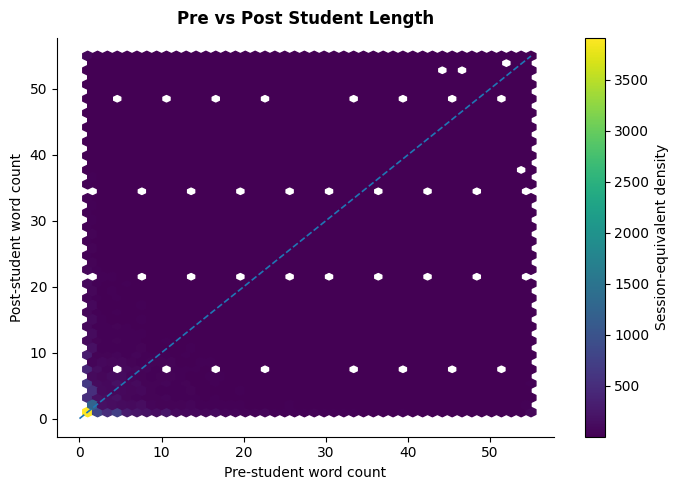

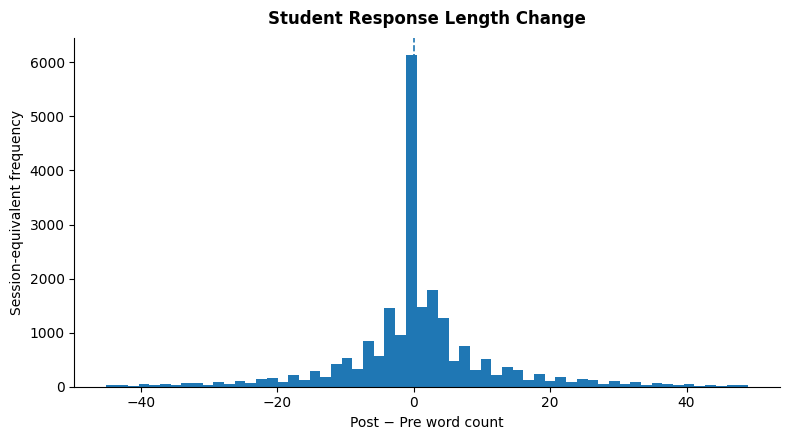

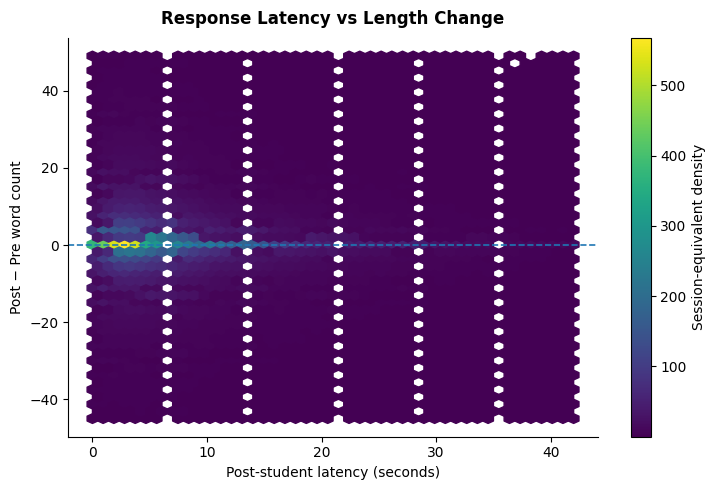

In [17]:
def plot_pre_post_length(cycles):
    q = pd.concat([cycles["pre_word_count"], cycles["post_word_count"]]).quantile(.99)
    x = cycles["pre_word_count"].clip(upper=q)
    y = cycles["post_word_count"].clip(upper=q)

    fig, ax = plt.subplots(figsize=(7, 5))
    hb = ax.hexbin(x, y, C=cycles["session_weight"], reduce_C_function=np.sum, gridsize=45, mincnt=1)
    ax.plot([0, q], [0, q], linestyle="--", linewidth=1.2)

    DialogueEDAUtils.style_ax(ax, "Pre vs Post Student Length", "Pre-student word count", "Post-student word count")
    fig.colorbar(hb, ax=ax, label="Session-equivalent density")
    fig.tight_layout()
    return fig


def plot_delta_length(cycles):
    lo, hi = cycles["delta_word_count"].quantile([.01, .99])
    view = cycles["delta_word_count"].between(lo, hi)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(cycles.loc[view, "delta_word_count"], bins=60, weights=cycles.loc[view, "session_weight"])
    ax.axvline(0, linestyle="--", linewidth=1.2)

    DialogueEDAUtils.style_ax(ax, "Student Response Length Change", "Post − Pre word count", "Session-equivalent frequency")
    fig.tight_layout()
    return fig


def plot_latency_vs_delta(cycles):
    latency_hi = cycles["post_latency_seconds"].quantile(.99)
    delta_lo, delta_hi = cycles["delta_word_count"].quantile([.01, .99])

    view = cycles["post_latency_seconds"].le(latency_hi) & cycles["delta_word_count"].between(delta_lo, delta_hi)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    hb = ax.hexbin(
        cycles.loc[view, "post_latency_seconds"], cycles.loc[view, "delta_word_count"],
        C=cycles.loc[view, "session_weight"], reduce_C_function=np.sum, gridsize=45, mincnt=1
    )
    ax.axhline(0, linestyle="--", linewidth=1.2)

    DialogueEDAUtils.style_ax(ax, "Response Latency vs Length Change", "Post-student latency (seconds)", "Post − Pre word count")
    fig.colorbar(hb, ax=ax, label="Session-equivalent density")
    fig.tight_layout()
    return fig


figs = [
    plot_pre_post_length(sts_cycles),
    plot_delta_length(sts_cycles),
    plot_latency_vs_delta(sts_cycles)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.4 — Insight 💡

The local dialogue structure is extremely consistent across the corpus. `Student → Tutor → Student` cycles appear in **99.89% of sessions**, confirming that this is a core interaction pattern rather than a rare event.

Student responses before and after the Tutor anchor are usually short, and the strongest mass of the `ΔLength` distribution sits near **zero**. However, both expansion and compression occur, so there is no universal post-anchor length increase.

Response latency is also concentrated at shorter delays, but it shows no clear monotonic relationship with response-length change.

> **Takeaway:** local response cycles are structurally important, but simple length or latency changes are not enough to imply improvement. Their value is in describing **how dialogue behaviour changes around an anchor**, which can later be combined with objective-specific evidence. 🔁

# 04.5 — Temporal Dynamics 📈

Okay, now we already know **where** each turn sits in the conversation.

The next question is:

> **How does dialogue behaviour change from early → late session?**

Instead of carrying full 3 / 5 / 10-bin trajectories everywhere, we'll summarize their shapes using a few target-blind descriptors:

- **Early-to-Late Change** → direction of change
- **Volatility** → how much the trajectory moves around
- **Concentration** → whether activity is localized in a small temporal region
- **Persistence** → how continuously an activity remains present
- **Entropy** → how evenly activity is distributed through time

We'll use **5 bins as the primary interpretable view**, while 3 and 10 bins will tell us whether the findings are resolution-stable.

And as always:

> **Temporal change ≠ learning change.**

Let's build the trajectories first 👇

In [18]:
# Temporal source
def prepare_temporal_source(turns, text_metrics):
    text = text_metrics[["session_id", "turn_index", "text_norm", "word_count", "numeric_count", "math_count"]].copy()
    text["unclear_count"] = text["text_norm"].str.contains("[UNCLEAR]", regex=False).astype("int8")
    text.drop(columns="text_norm", inplace=True)

    out = turns[
        ["session_id", "turn_index", "role", "speaker_switch", "bin_3", "bin_5", "bin_10"]
    ].merge(text, on=["session_id", "turn_index"], validate="1:1")

    student, tutor = out["role"].eq("student"), out["role"].eq("tutor")
    out["student_turn"] = student.astype("int8")
    out["tutor_turn"] = tutor.astype("int8")
    out["student_word_count"] = out["word_count"].where(student, 0)
    out["tutor_word_count"] = out["word_count"].where(tutor, 0)

    out["switch_event"] = out["speaker_switch"].astype("float32")
    out.loc[out["turn_index"].eq(0), "switch_event"] = np.nan
    return out


# Session-bin trajectory
def build_temporal_trajectory(source, bin_col):
    out = (
        source.groupby(["session_id", bin_col], sort=False)
        .agg(
            turns=("turn_index", "size"),
            student_turns=("student_turn", "sum"), tutor_turns=("tutor_turn", "sum"),
            word_count=("word_count", "sum"),
            student_word_count=("student_word_count", "sum"), tutor_word_count=("tutor_word_count", "sum"),
            math_count=("math_count", "sum"), numeric_count=("numeric_count", "sum"),
            unclear_count=("unclear_count", "sum"), speaker_switch_rate=("switch_event", "mean")
        )
        .reset_index().rename(columns={bin_col: "bin"})
    )

    words = out["word_count"].replace(0, np.nan)
    out["student_turn_share"] = out["student_turns"] / out["turns"]
    out["tutor_turn_share"] = out["tutor_turns"] / out["turns"]
    out["student_word_share"] = out["student_word_count"] / words
    out["tutor_word_share"] = out["tutor_word_count"] / words
    out["math_token_rate"] = out["math_count"] / words
    out["numeric_token_rate"] = out["numeric_count"] / words
    out["unclear_turn_share"] = out["unclear_count"] / out["turns"]
    return out

In [19]:
RATE_METRICS = [
    "student_turn_share", "tutor_turn_share",
    "student_word_share", "tutor_word_share",
    "speaker_switch_rate", "math_token_rate",
    "numeric_token_rate", "unclear_turn_share"
]

MASS_METRICS = [
    "student_word_count", "tutor_word_count",
    "math_count", "numeric_count", "unclear_count"
]


# Consecutive activity
def longest_active_run(values):
    active = np.asarray(values) > 0
    padded = np.r_[False, active, False].astype("int8")
    edges = np.diff(padded)
    starts, ends = np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)
    return (ends - starts).max() / len(active) if len(starts) else 0.0


# Temporal descriptors
def summarize_temporal_dynamics(trajectory, n_bins):
    out = pd.DataFrame(index=trajectory["session_id"].drop_duplicates())

    for metric in RATE_METRICS:
        x = trajectory.pivot(index="session_id", columns="bin", values=metric).reindex(columns=range(n_bins))
        out[f"{metric}_delta_el"] = x.iloc[:, -1] - x.iloc[:, 0]
        out[f"{metric}_volatility"] = x.std(axis=1, ddof=0)

    for metric in MASS_METRICS:
        x = trajectory.pivot(index="session_id", columns="bin", values=metric).reindex(columns=range(n_bins)).fillna(0)
        total = x.sum(axis=1)

        concentration = x.max(axis=1) / total.replace(0, np.nan)
        out[f"{metric}_concentration"] = (concentration - 1 / n_bins) / (1 - 1 / n_bins)

        p = x.div(total.replace(0, np.nan), axis=0)
        out[f"{metric}_entropy"] = -(p * np.log(p.where(p > 0))).sum(axis=1, min_count=1) / np.log(n_bins)

        out[f"{metric}_persistence"] = x.apply(longest_active_run, axis=1)

    return out.reset_index()


# Resolution stability
def compare_resolutions(t3, t5, t10):
    a, b, c = (x.set_index("session_id") for x in (t3, t5, t10))
    features = a.columns.intersection(b.columns).intersection(c.columns)
    rows = []

    for feature in features:
        row = {
            "feature": feature,
            "rho_3_5": a[feature].corr(b[feature], method="spearman"),
            "rho_5_10": b[feature].corr(c[feature], method="spearman"),
            "rho_3_10": a[feature].corr(c[feature], method="spearman")
        }

        if feature.endswith("_delta_el"):
            valid = a[feature].notna() & b[feature].notna() & c[feature].notna()
            row["direction_agreement"] = (
                (np.sign(a.loc[valid, feature]) == np.sign(b.loc[valid, feature])) &
                (np.sign(b.loc[valid, feature]) == np.sign(c.loc[valid, feature]))
            ).mean()
        else:
            row["direction_agreement"] = np.nan

        rows.append(row)

    out = pd.DataFrame(rows)
    out["mean_spearman"] = out[["rho_3_5", "rho_5_10", "rho_3_10"]].mean(axis=1)
    out["min_spearman"] = out[["rho_3_5", "rho_5_10", "rho_3_10"]].min(axis=1)
    return out.sort_values("mean_spearman", ascending=False).reset_index(drop=True)

In [20]:
temporal_source = prepare_temporal_source(turns_core, turn_text_metrics)

trajectory_3 = build_temporal_trajectory(temporal_source, "bin_3")
trajectory_5 = build_temporal_trajectory(temporal_source, "bin_5")
trajectory_10 = build_temporal_trajectory(temporal_source, "bin_10")

temporal_3 = summarize_temporal_dynamics(trajectory_3, 3)
temporal_5 = summarize_temporal_dynamics(trajectory_5, 5)
temporal_10 = summarize_temporal_dynamics(trajectory_10, 10)

resolution_stability = compare_resolutions(temporal_3, temporal_5, temporal_10)
session_temporal_dynamics = temporal_5.copy()

print(f"Sessions summarized : {len(session_temporal_dynamics):,}")
print(f"5-bin descriptors   : {session_temporal_dynamics.shape[1] - 1}")
print("Primary resolution  : 5 bins ✅")

Sessions summarized : 22,821
5-bin descriptors   : 31
Primary resolution  : 5 bins ✅


## Temporal shape at a glance 📊

Okay, now let's visualize three complementary questions:

1. **Student activity direction** — does Student participation shift toward early or late session?
2. **Direction × volatility** — is that change smooth or unstable?
3. **Math concentration × entropy** — is mathematical activity localized or spread throughout the dialogue?

These are session-level plots, so every session contributes only one observation.

In [21]:
# Student early-to-late change
def plot_student_delta(data):
    x = data["student_turn_share_delta_el"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(x.dropna(), bins=50)
    ax.axvline(0, linestyle="--", linewidth=1.2)
    ax.axvline(x.median(), linestyle=":", linewidth=1.2)

    DialogueEDAUtils.style_ax(
        ax, "Student Activity: Early → Late Change",
        "Late − Early student turn share", "Sessions"
    )
    fig.tight_layout()
    return fig


# Direction vs volatility
def plot_student_delta_volatility(data):
    fig, ax = plt.subplots(figsize=(7.5, 5))
    hb = ax.hexbin(
        data["student_turn_share_delta_el"],
        data["student_turn_share_volatility"],
        gridsize=45, mincnt=1
    )
    ax.axvline(0, linestyle="--", linewidth=1.2)

    DialogueEDAUtils.style_ax(
        ax, "Student Activity Direction vs Volatility",
        "Late − Early student turn share", "Student activity volatility"
    )
    fig.colorbar(hb, ax=ax, label="Sessions")
    fig.tight_layout()
    return fig


# Math localization
def plot_math_concentration_entropy(data):
    view = data[["math_count_concentration", "math_count_entropy"]].dropna()

    fig, ax = plt.subplots(figsize=(7.5, 5))
    hb = ax.hexbin(
        view["math_count_concentration"], view["math_count_entropy"],
        gridsize=40, mincnt=1
    )

    DialogueEDAUtils.style_ax(
        ax, "Temporal Distribution of Math Activity",
        "Normalized concentration", "Normalized entropy"
    )
    fig.colorbar(hb, ax=ax, label="Sessions")
    fig.tight_layout()
    return fig

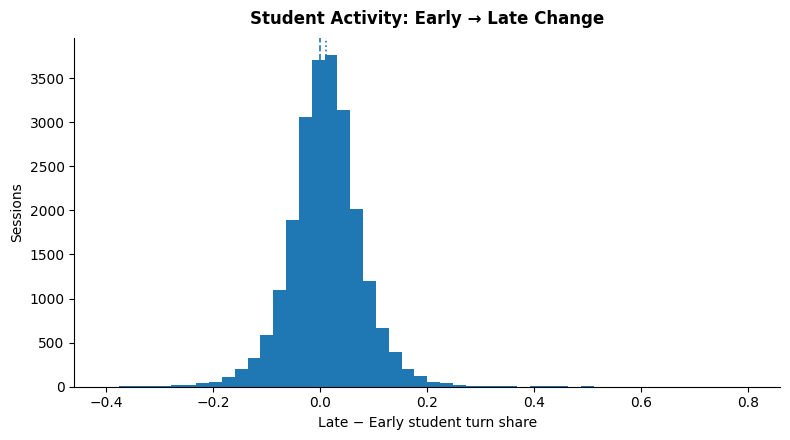

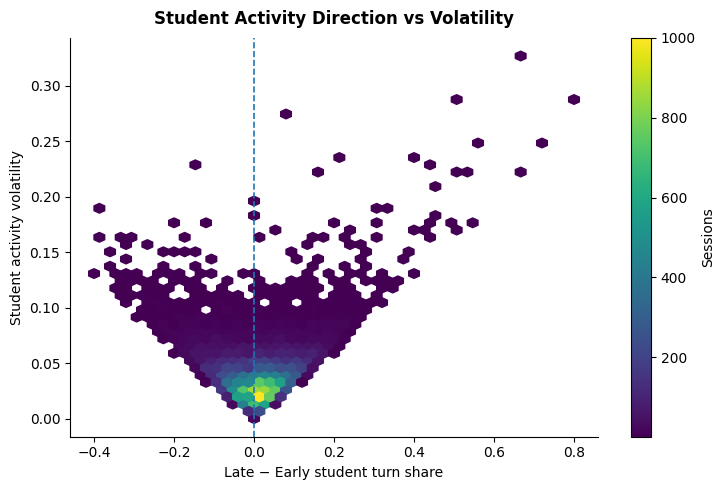

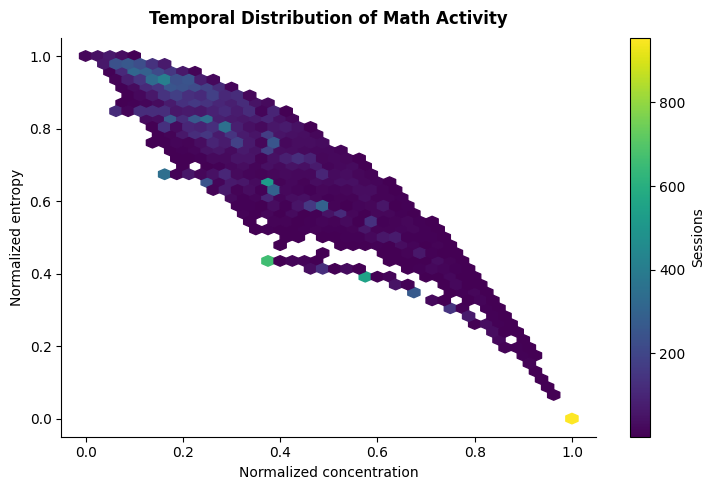

In [22]:
figs = [
    plot_student_delta(session_temporal_dynamics),
    plot_student_delta_volatility(session_temporal_dynamics),
    plot_math_concentration_entropy(session_temporal_dynamics)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.5 — Insight 💡

Most sessions show relatively small **early-to-late changes in Student turn share**, with the strongest mass concentrated near zero. A smaller subset shows much stronger late-session or early-session shifts.

The direction–volatility plot forms a clear V-shaped geometry, but this should not be interpreted as an independent behavioural relationship. Large early-to-late differences mechanically require some temporal variation, so `ΔEL` and volatility are partly dependent summaries of the same trajectory.

Math concentration and normalized entropy show an even stronger inverse relationship. This is expected because both describe the same temporal mass distribution from opposite perspectives: localized activity produces high concentration and low entropy, while distributed activity produces the reverse.

> **Takeaway:** the temporal descriptors are useful for interpretation, but several are structurally dependent. For archetype discovery, we should cluster the underlying standardized trajectories rather than blindly combining every derived descriptor. 🧭

# 04.6 — Target-Blind Dialogue Archetypes 🧩

Hmm, we now have thousands of session trajectories — but are there a few recurring **dialogue shapes** hidden inside them?

Here we'll use clustering to discover naturally recurring session patterns.

The important rule is simple:

> **Targets do not participate in archetype discovery.**

We'll cluster the underlying **5-bin dialogue trajectories**, while the temporal descriptors from 04.5 will be used later to explain what each cluster looks like.

Our flow is:

```text
5-bin trajectories
→ standardize
→ evaluate K = 2...8
→ check separation + stability + support
→ freeze K
→ fit archetypes
→ profile and visualize

In [23]:
ARCHETYPE_METRICS = [
    "student_turn_share",
    "student_word_share",
    "speaker_switch_rate",
    "math_token_rate",
    "unclear_turn_share"
]

# Archetype matrix
def build_archetype_matrix(trajectory, metrics, n_bins=5):
    wide = trajectory.pivot(index="session_id", columns="bin", values=metrics)
    wide = wide.reindex(columns=pd.MultiIndex.from_product([metrics, range(n_bins)]))
    wide.columns = [f"{metric}_b{bin_id}" for metric, bin_id in wide.columns]
    return wide

archetype_matrix = build_archetype_matrix(trajectory_5, ARCHETYPE_METRICS)

scaler = StandardScaler()
X_archetype = pd.DataFrame(
    scaler.fit_transform(archetype_matrix),
    index=archetype_matrix.index,
    columns=archetype_matrix.columns
)

print(f"Sessions          : {len(X_archetype):,}")
print(f"Trajectory fields : {X_archetype.shape[1]}")

Sessions          : 22,821
Trajectory fields : 25


## How many archetypes? 🤔

We won't choose the number of clusters from outcome differences.

Instead, every candidate `K` will be judged using three target-free questions:

1. **Separation** → are the clusters actually distinct?
2. **Stability** → do similar groups reappear after resampling?
3. **Support** → does an extra cluster represent a real group or only a tiny fragment?

We'll inspect `K = 2 ... 8`.

Silhouette measures separation, while resampled **Adjusted Rand Index (ARI)** measures clustering stability.

In [24]:
# Cluster stability
def cluster_stability(X, k, reference_labels, n_runs=8, sample_frac=.80, random_state=42):
    X = np.asarray(X)
    rng = np.random.default_rng(random_state + k)
    scores = []

    for run in range(n_runs):
        idx = rng.choice(len(X), int(len(X) * sample_frac), replace=False)
        model = KMeans(n_clusters=k, n_init=10, random_state=random_state + run)
        model.fit(X[idx])
        scores.append(adjusted_rand_score(reference_labels, model.predict(X)))

    return np.mean(scores), np.std(scores)


# Candidate K evaluation
def evaluate_cluster_solutions(X, k_values=range(2, 9), silhouette_sample=5000, random_state=42):
    X = np.asarray(X)
    rows = []

    for k in k_values:
        model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = model.fit_predict(X)

        stability, stability_std = cluster_stability(X, k, labels, random_state=random_state)
        sizes = np.bincount(labels, minlength=k)

        rows.append({
            "k": k,
            "silhouette": silhouette_score(
                X, labels, sample_size=min(silhouette_sample, len(X)), random_state=random_state
            ),
            "stability_ari": stability,
            "stability_std": stability_std,
            "min_cluster_size": sizes.min(),
            "min_cluster_share": sizes.min() / len(X),
            "max_cluster_share": sizes.max() / len(X),
            "inertia_per_session": model.inertia_ / len(X)
        })

    return pd.DataFrame(rows)




cluster_selection = evaluate_cluster_solutions(X_archetype)

display(
    cluster_selection.style.format({
        "silhouette": "{:.3f}",
        "stability_ari": "{:.3f}",
        "stability_std": "{:.3f}",
        "min_cluster_size": "{:,.0f}",
        "min_cluster_share": "{:.2%}",
        "max_cluster_share": "{:.2%}",
        "inertia_per_session": "{:.2f}"
    })
)

,k,silhouette,stability_ari,stability_std,min_cluster_size,min_cluster_share,max_cluster_share,inertia_per_session
0,2,0.211,0.983,0.008,"5,351",23.45%,76.55%,21.58
1,3,0.178,0.989,0.005,"3,509",15.38%,66.00%,19.90
2,4,0.095,0.969,0.023,"2,271",9.95%,44.56%,18.53
3,5,0.081,0.975,0.007,673,2.95%,38.44%,17.70
4,6,0.074,0.961,0.017,633,2.77%,36.91%,17.23
5,7,0.048,0.950,0.020,321,1.41%,28.14%,16.86
6,8,0.047,0.644,0.091,289,1.27%,26.13%,16.55


## Target-free K diagnostics 📊

Okay, one metric alone should not decide the cluster count.

- **Silhouette** tells us how separated the groups are.
- **Stability ARI** tells us whether similar groups survive resampling.
- **Cluster support** tells us whether additional clusters remain substantial or fragment into tiny groups.

We'll inspect these together before freezing any archetype solution.

In [25]:
# Cluster separation
def plot_k_silhouette(results):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.plot(results["k"], results["silhouette"], marker="o")

    DialogueEDAUtils.style_ax(
        ax, "Cluster Separation by K",
        "Number of clusters (K)", "Silhouette score"
    )
    ax.set_xticks(results["k"])
    fig.tight_layout()
    return fig


# Resampling stability
def plot_k_stability(results):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.errorbar(
        results["k"], results["stability_ari"],
        yerr=results["stability_std"], marker="o", capsize=3
    )

    DialogueEDAUtils.style_ax(
        ax, "Cluster Stability by K",
        "Number of clusters (K)", "Resampled ARI"
    )
    ax.set_xticks(results["k"])
    fig.tight_layout()
    return fig


# Cluster support
def plot_k_support(results):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.plot(results["k"], 100 * results["min_cluster_share"], marker="o", label="Smallest cluster")
    ax.plot(results["k"], 100 * results["max_cluster_share"], marker="o", label="Largest cluster")

    DialogueEDAUtils.style_ax(
        ax, "Cluster Support by K",
        "Number of clusters (K)", "Share of sessions (%)"
    )
    ax.set_xticks(results["k"])
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig



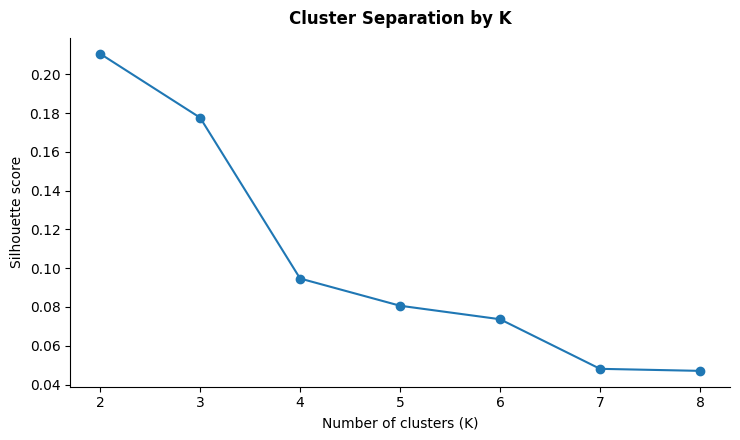

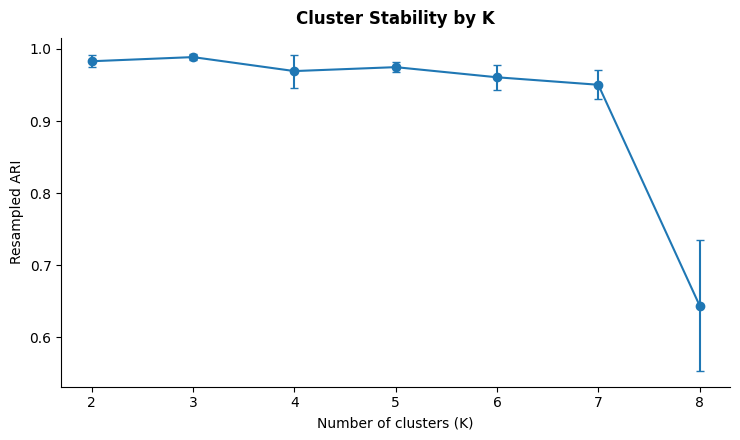

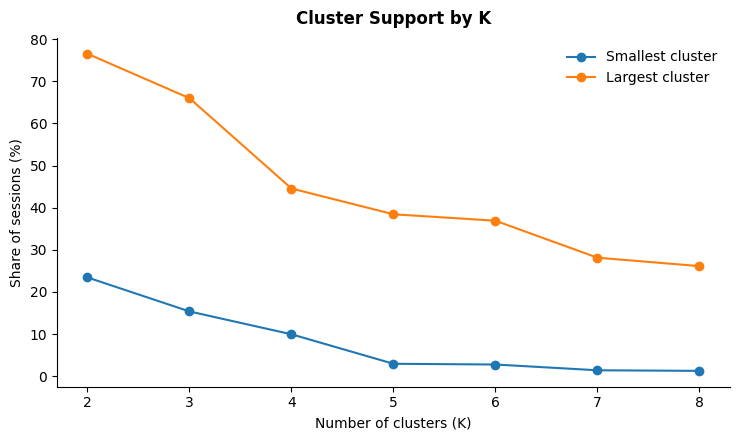

In [26]:
figs = [
    plot_k_silhouette(cluster_selection),
    plot_k_stability(cluster_selection),
    plot_k_support(cluster_selection)
]

for fig in figs:
    display(fig)
    plt.close(fig)

## Freeze the archetype solution 🧊

Once the target-free diagnostics support a particular `K`, we'll freeze that solution and inspect what the groups actually look like.

The cluster IDs will remain neutral:

```text
Archetype 0
Archetype 1
...

In [27]:
# Final archetype fit
def fit_dialogue_archetypes(X, n_clusters, random_state=42):
    model = KMeans(n_clusters=n_clusters, n_init=30, random_state=random_state)
    labels = model.fit_predict(X)

    assignments = pd.DataFrame({
        "session_id": X.index,
        "archetype": labels
    })

    sizes = (
        assignments["archetype"].value_counts().sort_index()
        .rename_axis("archetype").rename("sessions").reset_index()
    )
    sizes["session_share"] = sizes["sessions"] / len(assignments)

    return assignments, model, sizes

BEST_K = 3  # set only after reviewing the target-free K diagnostics

dialogue_archetypes, archetype_model, archetype_sizes = fit_dialogue_archetypes(
    X_archetype, BEST_K
)

display(
    archetype_sizes.style.format({
        "sessions": "{:,.0f}",
        "session_share": "{:.2%}"
    })
)

,archetype,sessions,session_share
0,0,"4,251",18.63%
1,1,"15,061",66.00%
2,2,"3,509",15.38%


In [28]:
PROFILE_METRICS = [
    "student_turn_share_delta_el",
    "student_turn_share_volatility",
    "speaker_switch_rate_delta_el",
    "speaker_switch_rate_volatility",
    "math_count_concentration",
    "math_count_entropy",
    "math_count_persistence",
    "unclear_count_concentration",
    "unclear_count_entropy"
]

TRAJECTORY_PROFILE_METRICS = [
    "student_turn_share",
    "student_word_share",
    "speaker_switch_rate",
    "math_token_rate"
]


# Archetype profiles
def build_archetype_profiles(assignments, trajectory, temporal):
    labels = assignments.set_index("session_id")

    profile_base = temporal.set_index("session_id")[PROFILE_METRICS]
    profile_scaled = pd.DataFrame(
        StandardScaler().fit_transform(profile_base),
        index=profile_base.index, columns=profile_base.columns
    )

    profile_z = (
        profile_scaled.join(labels)
        .groupby("archetype")[PROFILE_METRICS].mean()
    )

    tr = trajectory.merge(assignments, on="session_id", validate="m:1")
    grouped = tr.groupby(["archetype", "bin"])[TRAJECTORY_PROFILE_METRICS]

    trajectory_profile = (
        grouped.median().add_suffix("_median")
        .join(grouped.quantile(.25).add_suffix("_q25"))
        .join(grouped.quantile(.75).add_suffix("_q75"))
        .reset_index()
    )

    return profile_z, trajectory_profile


archetype_profile_z, archetype_trajectory_profile = build_archetype_profiles(
    dialogue_archetypes,
    trajectory_5,
    session_temporal_dynamics
)



pca = PCA(n_components=2)
pca_xy = pca.fit_transform(X_archetype)

archetype_pca = pd.DataFrame({
    "session_id": X_archetype.index,
    "pc1": pca_xy[:, 0],
    "pc2": pca_xy[:, 1]
}).merge(dialogue_archetypes, on="session_id", validate="1:1")

centroid_pca = pca.transform(archetype_model.cluster_centers_)

print(f"PCA variance shown : {pca.explained_variance_ratio_.sum():.2%}")

PCA variance shown : 35.41%


c:\Users\USER\miniconda3\envs\ml_project\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


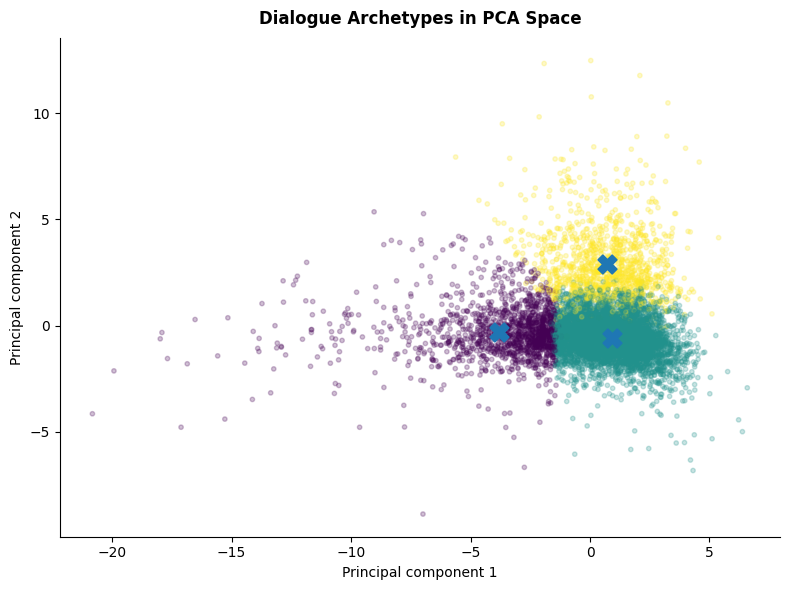

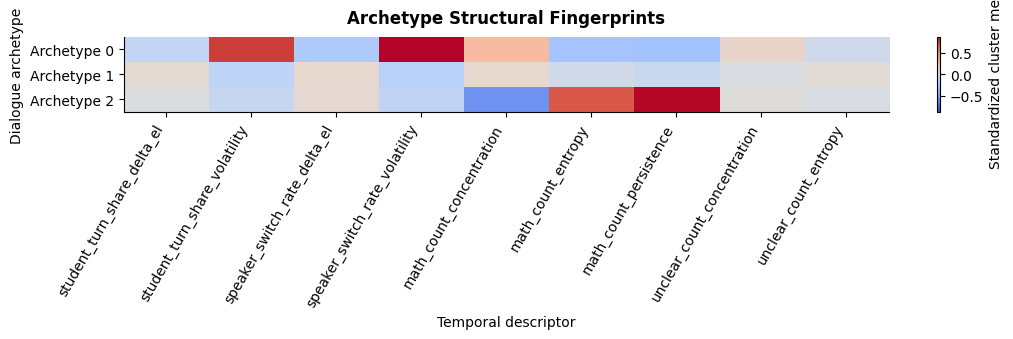

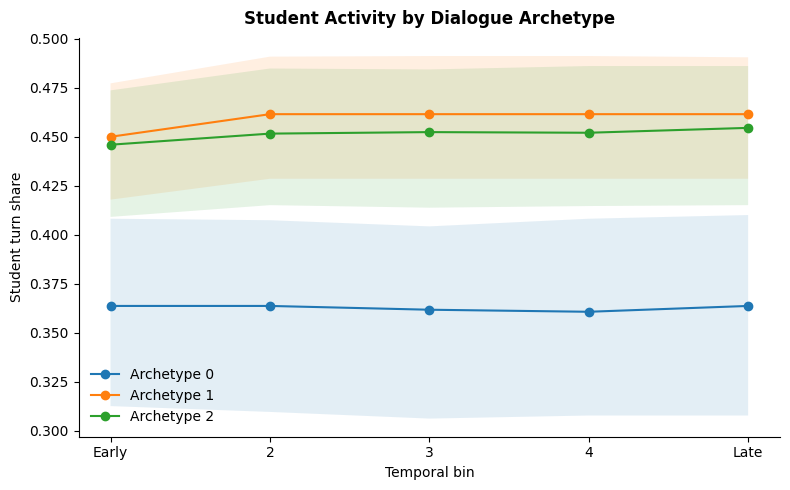

In [29]:
# PCA cluster map
def plot_archetype_pca(data, centroids, sample_size=8000, random_state=42):
    view = data.sample(min(sample_size, len(data)), random_state=random_state)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(view["pc1"], view["pc2"], c=view["archetype"], s=10, alpha=.25)
    ax.scatter(
        centroids[:, 0], centroids[:, 1],
        marker="X", s=180, linewidth=1.2
    )

    DialogueEDAUtils.style_ax(
        ax, "Dialogue Archetypes in PCA Space",
        "Principal component 1", "Principal component 2"
    )
    fig.tight_layout()
    return fig


# Standardized archetype fingerprint
def plot_archetype_fingerprint(profile):
    values = profile.to_numpy()
    limit = np.nanmax(np.abs(values))

    fig, ax = plt.subplots(figsize=(11, max(3.5, .7 * len(profile))))
    im = ax.imshow(values, aspect="auto", vmin=-limit, vmax=limit, cmap="coolwarm")

    ax.set_xticks(range(len(profile.columns)), labels=profile.columns, rotation=60, ha="right")
    ax.set_yticks(range(len(profile)), labels=[f"Archetype {i}" for i in profile.index])

    DialogueEDAUtils.style_ax(
        ax, "Archetype Structural Fingerprints",
        "Temporal descriptor", "Dialogue archetype"
    )
    fig.colorbar(im, ax=ax, label="Standardized cluster mean")
    fig.tight_layout()
    return fig


# Median trajectory + IQR
def plot_archetype_trajectory(profile, metric="student_turn_share"):
    fig, ax = plt.subplots(figsize=(8, 5))

    for archetype, group in profile.groupby("archetype"):
        group = group.sort_values("bin")
        x = group["bin"] + 1

        ax.plot(
            x, group[f"{metric}_median"],
            marker="o", label=f"Archetype {archetype}"
        )
        ax.fill_between(
            x,
            group[f"{metric}_q25"],
            group[f"{metric}_q75"],
            alpha=.12
        )

    DialogueEDAUtils.style_ax(
        ax, "Student Activity by Dialogue Archetype",
        "Temporal bin", "Student turn share"
    )
    ax.set_xticks(range(1, 6), ["Early", "2", "3", "4", "Late"])
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig

figs = [
    plot_archetype_pca(archetype_pca, centroid_pca),
    plot_archetype_fingerprint(archetype_profile_z),
    plot_archetype_trajectory(archetype_trajectory_profile)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.6 — Insight 💡

The target-blind clustering reveals **three reproducible dialogue regimes**, but they should be interpreted as overlapping structural archetypes rather than sharply separated session classes.

**Archetype 0** is the most distinct behaviourally: Student turn share is lower, Student and speaker-switch trajectories are more volatile, and mathematical activity tends to be more temporally localized.

**Archetype 1** shows higher and relatively stable Student participation, with a more intermediate temporal distribution of mathematical activity.

**Archetype 2** also maintains stable Student participation, but its strongest defining feature is different: mathematical activity is substantially **less concentrated, more persistent, and more evenly distributed across the session**.

Interestingly, the median Student trajectories are fairly flat within all three archetypes. This means the clusters are not simply “rising vs falling Student participation” patterns — much of the meaningful separation comes from **temporal volatility and the distribution of mathematical activity**.

The PCA projection shows substantial overlap, which is consistent with the modest silhouette score (`0.178`), while the very high resampling stability (`ARI = 0.989`) indicates that the broad partition itself is reproducible.

> **Takeaway:** the three archetypes are useful as **session-level structural context**, especially for distinguishing localized vs persistent dialogue activity, but they are not objective-specific mastery signals and should not be treated as hard latent learner types. 🧩

# 04.7 — Session Outcome Context 🎯

Okay, this is the first point where target information enters Notebook 04.

Everything from **04.1 → 04.6 is already frozen**, so we will not rebuild trajectories, change archetypes, or create target-informed dialogue features.

Instead, we'll ask:

> **Do the target-blind dialogue structures relate to the overall outcome context of a session?**

Each session will be described as:

- `ALL_POSITIVE`
- `MIXED`
- `ALL_NEGATIVE`

One important boundary remains:

> **Session context ≠ objective-specific mastery.**

A mixed session can contain both positive and negative objectives while sharing the same dialogue structure.

Let's attach the outcome context carefully 👇

In [30]:
responses = pd.read_parquet(RESPONSES_PATH, columns=["session_id", "target", "fold"])

CONTEXT_ORDER = ["ALL_POSITIVE", "MIXED", "ALL_NEGATIVE"]

# Session outcome context
def build_session_outcome_context(responses):
    out = (
        responses.groupby("session_id", sort=False)
        .agg(n_objectives=("target", "size"), n_positive=("target", "sum"), fold=("fold", "first"))
        .reset_index()
    )

    out["n_negative"] = out["n_objectives"] - out["n_positive"]
    out["positive_fraction"] = out["n_positive"] / out["n_objectives"]

    out["outcome_context"] = np.select(
        [out["n_negative"].eq(0), out["n_positive"].eq(0)],
        ["ALL_POSITIVE", "ALL_NEGATIVE"],
        default="MIXED"
    )
    out["outcome_context"] = pd.Categorical(out["outcome_context"], categories=CONTEXT_ORDER, ordered=True)
    return out


session_outcome = build_session_outcome_context(responses)

display(
    session_outcome.groupby("outcome_context", observed=True)
    .agg(
        sessions=("session_id", "size"),
        median_objectives=("n_objectives", "median"),
        median_positive_fraction=("positive_fraction", "median")
    )
    .reindex(CONTEXT_ORDER)
)
session_outcome

,sessions,median_objectives,median_positive_fraction
outcome_context,,,
ALL_POSITIVE,13582,1.0,1.0
MIXED,3207,2.0,0.5
ALL_NEGATIVE,6032,1.0,0.0


,session_id,n_objectives,n_positive,fold,n_negative,positive_fraction,outcome_context
0,bcaufvc,4,4.0,0,0.0,1.00,ALL_POSITIVE
1,eyutanf,3,3.0,4,0.0,1.00,ALL_POSITIVE
2,juptkxd,1,0.0,2,1.0,0.00,ALL_NEGATIVE
3,ntwkcfj,4,1.0,0,3.0,0.25,MIXED
4,jqriibm,1,0.0,0,1.0,0.00,ALL_NEGATIVE
...,...,...,...,...,...,...,...
22816,irnipdg,1,0.0,3,1.0,0.00,ALL_NEGATIVE
22817,nfgjefg,1,1.0,2,0.0,1.00,ALL_POSITIVE
22818,kxnefbp,1,0.0,0,1.0,0.00,ALL_NEGATIVE
22819,hrahrpn,1,0.0,0,1.0,0.00,ALL_NEGATIVE


## Bring the frozen dialogue structure together 🧩

Now we'll attach the outcome context to the structural information already built in earlier sections.

We won't dump every available field into the analysis. Instead, we'll keep a focused set from:

- participation and role balance,
- interaction structure,
- temporal dynamics,
- local response cycles,
- frozen dialogue archetypes.

This gives us one clean table:

> **one row = one session**

In [31]:
ROLE_CONTEXT_COLS = [
    "student_share", "tutor_share", "pedagogical_dominance",
    "speaker_switch_rate", "student_tutor_switch_rate",
    "transition_entropy", "student_run_mean", "tutor_run_mean"
]

TEMPORAL_CONTEXT_COLS = [
    "student_turn_share_delta_el", "student_turn_share_volatility",
    "speaker_switch_rate_delta_el", "speaker_switch_rate_volatility",
    "math_count_concentration", "math_count_entropy", "math_count_persistence"
]

CYCLE_CONTEXT_COLS = [
    "median_delta_word_count", "median_lexical_novelty",
    "median_post_latency_seconds", "median_anchor_post_overlap"
]


# Session context table
def build_session_context_table(outcome, clock, role, cycles, temporal, archetypes):
    out = outcome.merge(
        clock[["session_id", "n_turns", "duration_minutes"]],
        on="session_id", validate="1:1"
    )
    out = out.merge(
        role[["session_id", *ROLE_CONTEXT_COLS]],
        on="session_id", validate="1:1"
    )
    out = out.merge(
        cycles[["session_id", *CYCLE_CONTEXT_COLS]],
        on="session_id", how="left", validate="1:1"
    )
    out = out.merge(
        temporal[["session_id", *TEMPORAL_CONTEXT_COLS]],
        on="session_id", validate="1:1"
    )
    out = out.merge(
        archetypes[["session_id", "archetype"]],
        on="session_id", validate="1:1"
    )
    return out


session_context_analysis = build_session_context_table(
    session_outcome,
    session_clock,
    session_role_dynamics,
    session_response_cycles,
    session_temporal_dynamics,
    dialogue_archetypes
)

context_multi = session_context_analysis.loc[session_context_analysis["n_objectives"].ge(2)].copy()

print(f"All sessions             : {len(session_context_analysis):,}")
print(f"Multi-objective sessions : {len(context_multi):,}")
print(f"Analysis fields          : {session_context_analysis.shape[1] - 1}")


session_context_analysis.head()

All sessions             : 22,821
Multi-objective sessions : 8,364
Analysis fields          : 28


,session_id,n_objectives,n_positive,fold,n_negative,positive_fraction,outcome_context,n_turns,duration_minutes,student_share,...,median_post_latency_seconds,median_anchor_post_overlap,student_turn_share_delta_el,student_turn_share_volatility,speaker_switch_rate_delta_el,speaker_switch_rate_volatility,math_count_concentration,math_count_entropy,math_count_persistence,archetype
0,bcaufvc,4,4.0,0,0.0,1.00,ALL_POSITIVE,330,44.750000,0.454545,...,5.0,0.0,0.030303,0.042855,0.017016,0.022230,0.166667,0.942631,1.0,1
1,eyutanf,3,3.0,4,0.0,1.00,ALL_POSITIVE,280,44.850000,0.439286,...,4.0,0.0,0.017857,0.040089,-0.034740,0.069940,0.222222,0.891254,1.0,1
2,juptkxd,1,0.0,2,1.0,0.00,ALL_NEGATIVE,291,44.950000,0.477663,...,6.0,0.0,-0.025132,0.021396,-0.030925,0.016974,0.151235,0.962716,1.0,2
3,ntwkcfj,4,1.0,0,3.0,0.25,MIXED,265,45.066667,0.467925,...,8.0,0.0,0.000000,0.036586,0.002540,0.036285,0.305556,0.787124,0.6,1
4,jqriibm,1,0.0,0,1.0,0.00,ALL_NEGATIVE,270,35.033333,0.377778,...,4.5,0.0,-0.018519,0.030089,-0.109015,0.073136,1.000000,-0.000000,0.2,0


In [32]:
def context_support(data):
    return (
        data.groupby("outcome_context", observed=True)
        .agg(
            sessions=("session_id", "size"),
            median_objectives=("n_objectives", "median"),
            p90_objectives=("n_objectives", lambda x: x.quantile(.90)),
            median_turns=("n_turns", "median"),
            median_duration=("duration_minutes", "median")
        )
        .reindex(CONTEXT_ORDER)
    )


support_full = context_support(session_context_analysis)
support_multi = context_support(context_multi)

objective_count_support = (
    session_outcome["n_objectives"]
    .value_counts().sort_index()
    .rename_axis("n_objectives").rename("sessions").reset_index()
)

print("Full population")
display(support_full.round(2))

print("\nMulti-objective population")
display(support_multi.round(2))

print("\nObjectives per session")
display(objective_count_support)

Full population


,sessions,median_objectives,p90_objectives,median_turns,median_duration
outcome_context,,,,,
ALL_POSITIVE,13582,1.0,3.0,267.0,43.25
MIXED,3207,2.0,4.0,268.0,44.30
ALL_NEGATIVE,6032,1.0,2.0,268.0,43.07



Multi-objective population


,sessions,median_objectives,p90_objectives,median_turns,median_duration
outcome_context,,,,,
ALL_POSITIVE,4526,2.0,3.0,265.0,43.90
MIXED,3207,2.0,4.0,268.0,44.30
ALL_NEGATIVE,631,2.0,3.0,263.0,43.63



Objectives per session


,n_objectives,sessions
0,1,14457
1,2,5640
2,3,1904
3,4,581
4,5,168
5,6,48
6,7,17
7,8,4
8,10,2


## Do frozen dialogue signals differ by context? 🔍

Now we'll compare a small set of representative signals across the three outcome contexts.

The primary comparison uses **multi-objective sessions**, so `MIXED` is compared against sessions that could actually have become mixed.

We'll focus on medians and IQRs first — formal confirmation belongs later.

In [33]:
CONTEXT_SIGNALS = [
    "student_share", "pedagogical_dominance",
    "speaker_switch_rate", "transition_entropy",
    "student_turn_share_delta_el", "student_turn_share_volatility",
    "math_count_concentration", "math_count_persistence",
    "median_delta_word_count", "median_lexical_novelty",
    "median_post_latency_seconds"
]


# Context signal summary
def summarize_context_signals(data, signals):
    long = data[["outcome_context", *signals]].melt(
        id_vars="outcome_context", var_name="signal", value_name="value"
    )

    summary = (
        long.groupby(["signal", "outcome_context"], observed=True)["value"]
        .agg(
            n="count",
            q25=lambda x: x.quantile(.25),
            median="median",
            q75=lambda x: x.quantile(.75)
        )
        .reset_index()
    )

    med = summary.pivot(index="signal", columns="outcome_context", values="median").reindex(columns=CONTEXT_ORDER)
    effects = med.copy()
    effects["pos_minus_neg"] = med["ALL_POSITIVE"] - med["ALL_NEGATIVE"]
    effects["pos_minus_mixed"] = med["ALL_POSITIVE"] - med["MIXED"]
    effects["mixed_minus_neg"] = med["MIXED"] - med["ALL_NEGATIVE"]

    return summary, effects.reset_index()


context_summary, context_effects = summarize_context_signals(context_multi, CONTEXT_SIGNALS)

display(context_effects.round(4))

outcome_context,signal,ALL_POSITIVE,MIXED,ALL_NEGATIVE,pos_minus_neg,pos_minus_mixed,mixed_minus_neg
0,math_count_concentration,0.2969,0.2898,0.3056,-0.0087,0.0071,-0.0158
1,math_count_persistence,0.8000,0.8000,0.8000,0.0000,0.0000,0.0000
2,median_delta_word_count,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,median_lexical_novelty,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000
4,median_post_latency_seconds,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000
5,pedagogical_dominance,0.5385,0.5403,0.5410,-0.0025,-0.0018,-0.0007
6,speaker_switch_rate,0.8291,0.8246,0.8270,0.0021,0.0045,-0.0024
7,student_share,0.4474,0.4455,0.4438,0.0036,0.0019,0.0017
8,student_turn_share_delta_el,0.0127,0.0069,0.0000,0.0127,0.0058,0.0069
9,student_turn_share_volatility,0.0327,0.0334,0.0340,-0.0013,-0.0008,-0.0006


In [34]:
# Outcome-context trajectory
def build_context_trajectory(trajectory, outcome, metric):
    data = trajectory[["session_id", "bin", metric]].merge(
        outcome[["session_id", "n_objectives", "outcome_context"]],
        on="session_id", validate="m:1"
    )
    data = data.loc[data["n_objectives"].ge(2)]

    return (
        data.groupby(["outcome_context", "bin"], observed=True)[metric]
        .agg(
            median="median",
            q25=lambda x: x.quantile(.25),
            q75=lambda x: x.quantile(.75)
        )
        .reset_index()
    )


student_context_trajectory = build_context_trajectory(
    trajectory_5, session_outcome, "student_turn_share"
)

display(student_context_trajectory.round(4))


def context_trajectory_direction(trajectory, outcome, metric):
    profile = build_context_trajectory(trajectory, outcome, metric)
    wide = profile.pivot(index="outcome_context", columns="bin", values="median").reindex(CONTEXT_ORDER)
    return (wide.iloc[:, -1] - wide.iloc[:, 0]).rename("late_minus_early")


student_resolution_check = pd.concat({
    "3-bin": context_trajectory_direction(trajectory_3, session_outcome, "student_turn_share"),
    "5-bin": context_trajectory_direction(trajectory_5, session_outcome, "student_turn_share"),
    "10-bin": context_trajectory_direction(trajectory_10, session_outcome, "student_turn_share")
}, axis=1)

display(student_resolution_check.round(4))

,outcome_context,bin,median,q25,q75
0,ALL_POSITIVE,0,0.4390,0.4000,0.4706
1,ALL_POSITIVE,1,0.4488,0.4068,0.4839
2,ALL_POSITIVE,2,0.4500,0.4054,0.4853
3,ALL_POSITIVE,3,0.4490,0.4058,0.4844
4,ALL_POSITIVE,4,0.4510,0.4085,0.4844
5,MIXED,0,0.4407,0.4000,0.4727
6,MIXED,1,0.4478,0.4000,0.4857
7,MIXED,2,0.4490,0.4000,0.4857
8,MIXED,3,0.4468,0.4000,0.4857
9,MIXED,4,0.4493,0.4000,0.4844


,3-bin,5-bin,10-bin
outcome_context,,,
ALL_POSITIVE,0.0078,0.0120,0.0212
MIXED,0.0055,0.0086,0.0152
ALL_NEGATIVE,0.0026,0.0044,0.0135


## Frozen archetypes × outcome context 🧩

The three dialogue archetypes were discovered without targets and are already frozen.

Now we can ask:

> **Are those structural regimes equally common across ALL_POSITIVE, MIXED, and ALL_NEGATIVE sessions?**

We will only overlay the outcome context — the clustering itself will not change.

In [35]:
archetype_context = (
    pd.crosstab(
        context_multi["outcome_context"],
        context_multi["archetype"],
        normalize="index"
    )
    .reindex(CONTEXT_ORDER)
)

archetype_context.columns = [f"Archetype {c}" for c in archetype_context.columns]

display(archetype_context.style.format("{:.2%}"))

,Archetype 0,Archetype 1,Archetype 2
outcome_context,,,
ALL_POSITIVE,18.01%,68.63%,13.37%
MIXED,18.93%,65.86%,15.22%
ALL_NEGATIVE,19.02%,66.24%,14.74%


In [36]:
STABILITY_SIGNALS = [
    "student_share",
    "speaker_switch_rate",
    "student_turn_share_delta_el",
    "math_count_concentration",
    "median_delta_word_count"
]


# Fold direction stability
def context_fold_stability(data, signals):
    med = (
        data.groupby(["fold", "outcome_context"], observed=True)[signals]
        .median()
    )

    rows = []
    for signal in signals:
        wide = med[signal].unstack("outcome_context").reindex(columns=CONTEXT_ORDER)
        effect = (wide["ALL_POSITIVE"] - wide["ALL_NEGATIVE"]).rename("pos_minus_neg").reset_index()
        effect["signal"] = signal
        rows.append(effect)

    return pd.concat(rows, ignore_index=True)[["signal", "fold", "pos_minus_neg"]]


fold_context_stability = context_fold_stability(context_multi, STABILITY_SIGNALS)

fold_stability_summary = (
    fold_context_stability.groupby("signal")["pos_minus_neg"]
    .agg(
        mean_effect="mean",
        min_effect="min",
        max_effect="max",
        positive_folds=lambda x: (x > 0).sum(),
        negative_folds=lambda x: (x < 0).sum()
    )
    .reset_index()
)

display(fold_context_stability.round(4))
display(fold_stability_summary.round(4))

,signal,fold,pos_minus_neg
0,student_share,0,0.0119
1,student_share,1,0.0019
2,student_share,2,0.0059
3,student_share,3,-0.0009
4,student_share,4,0.0004
5,speaker_switch_rate,0,0.0030
6,speaker_switch_rate,1,-0.0034
7,speaker_switch_rate,2,0.0181
8,speaker_switch_rate,3,0.0025
9,speaker_switch_rate,4,-0.0043


,signal,mean_effect,min_effect,max_effect,positive_folds,negative_folds
0,math_count_concentration,-0.0087,-0.0300,0.0031,1,2
1,median_delta_word_count,0.0000,0.0000,0.0000,0,0
2,speaker_switch_rate,0.0032,-0.0043,0.0181,3,2
3,student_share,0.0038,-0.0009,0.0119,4,1
4,student_turn_share_delta_el,0.0064,-0.0078,0.0161,3,2


In [37]:
context_multi["objective_count_band"] = pd.cut(
    context_multi["n_objectives"],
    bins=[1, 2, 4, np.inf],
    labels=["2", "3–4", "5+"],
    right=True
)

OBJECTIVE_COUNT_SIGNALS = [
    "student_share",
    "speaker_switch_rate",
    "student_turn_share_delta_el",
    "math_count_concentration"
]

objective_count_effects = (
    context_multi.groupby(
        ["objective_count_band", "outcome_context"],
        observed=True
    )[OBJECTIVE_COUNT_SIGNALS]
    .median()
    .reset_index()
)

display(objective_count_effects.round(4))

,objective_count_band,outcome_context,student_share,speaker_switch_rate,student_turn_share_delta_el,math_count_concentration
0,2,ALL_POSITIVE,0.4483,0.8320,0.0121,0.2857
1,2,MIXED,0.4470,0.8287,0.0087,0.2885
2,2,ALL_NEGATIVE,0.4414,0.8261,0.0000,0.3015
3,3–4,ALL_POSITIVE,0.4463,0.8254,0.0145,0.3173
4,3–4,MIXED,0.4444,0.8187,0.0000,0.2898
5,3–4,ALL_NEGATIVE,0.4479,0.8341,0.0000,0.3333
6,5+,ALL_POSITIVE,0.4381,0.7992,0.0000,0.3056
7,5+,MIXED,0.4369,0.8165,0.0048,0.3056
8,5+,ALL_NEGATIVE,0.4614,0.8348,-0.0026,0.2324


## Session-context patterns at a glance 📊

Okay, now let's visualize only the relationships that answer distinct questions:

1. **Outcome-context support**
2. **Interaction structure by context**
3. **Temporal Student shift by context**
4. **Full Student trajectory across the session**
5. **Frozen archetype composition**

The main continuous comparisons use the multi-objective population.

In [38]:
# Outcome support
def plot_context_support(outcome):
    counts = outcome["outcome_context"].value_counts().reindex(CONTEXT_ORDER)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.bar(counts.index, counts.values)

    DialogueEDAUtils.style_ax(
        ax, "Session Outcome Context",
        "Outcome context", "Sessions"
    )
    fig.tight_layout()
    return fig


# Continuous context comparison
def plot_context_box(data, signal, title, ylabel):
    values = [
        data.loc[data["outcome_context"].eq(context), signal].dropna()
        for context in CONTEXT_ORDER
    ]

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.boxplot(values, tick_labels=CONTEXT_ORDER, showfliers=False)

    DialogueEDAUtils.style_ax(ax, title, "Outcome context", ylabel)
    fig.tight_layout()
    return fig


# Student trajectory overlay
def plot_context_trajectory(profile):
    fig, ax = plt.subplots(figsize=(8, 5))

    for context in CONTEXT_ORDER:
        x = profile.loc[profile["outcome_context"].eq(context)].sort_values("bin")
        bins = x["bin"].to_numpy() + 1

        ax.plot(bins, x["median"], marker="o", label=context)
        ax.fill_between(bins, x["q25"], x["q75"], alpha=.12)

    DialogueEDAUtils.style_ax(
        ax, "Student Activity by Session Outcome Context",
        "Temporal bin", "Student turn share"
    )
    ax.set_xticks(range(1, 6), ["Early", "2", "3", "4", "Late"])
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


# Frozen archetype composition
def plot_archetype_context(table):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    table.plot(kind="bar", stacked=True, ax=ax)

    DialogueEDAUtils.style_ax(
        ax, "Dialogue Archetypes by Outcome Context",
        "Outcome context", "Share of sessions"
    )
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(frameon=False, title=None)
    fig.tight_layout()
    return fig

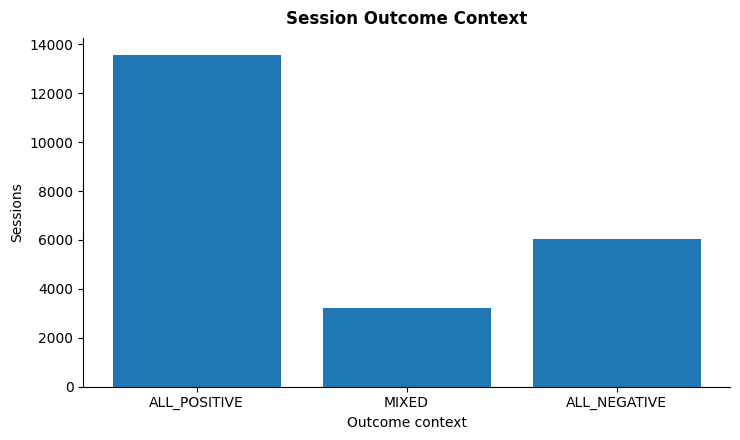

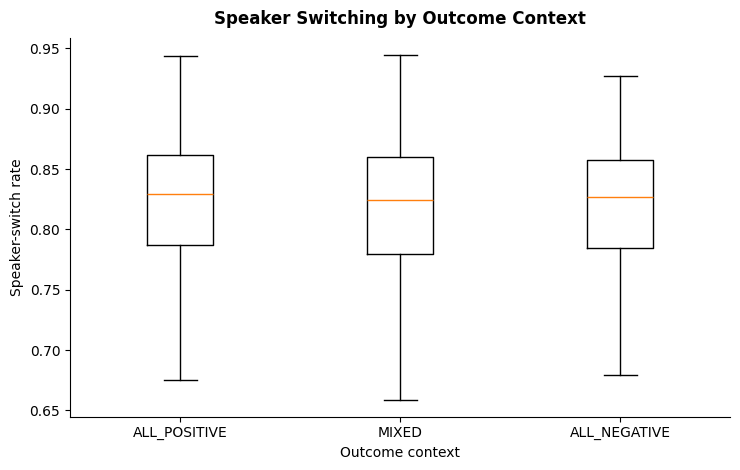

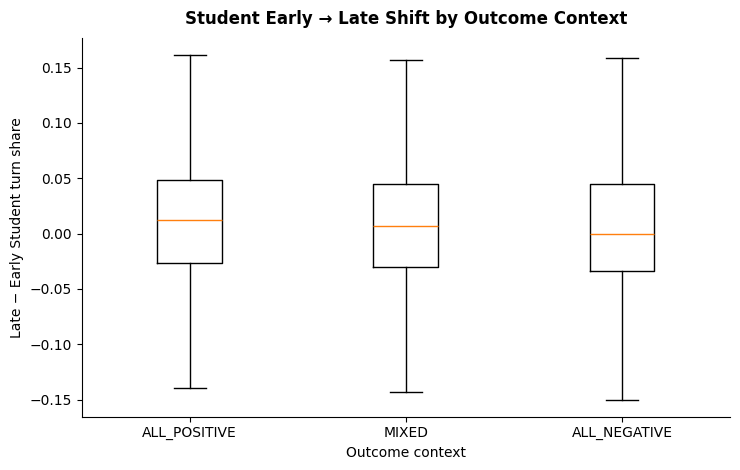

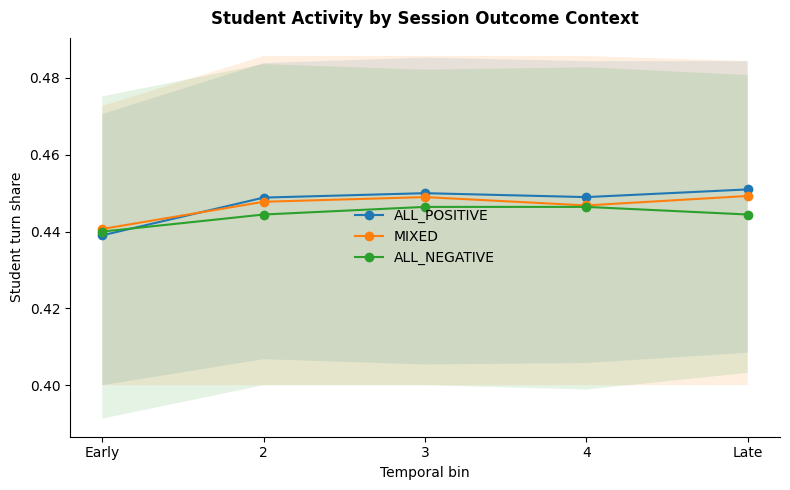

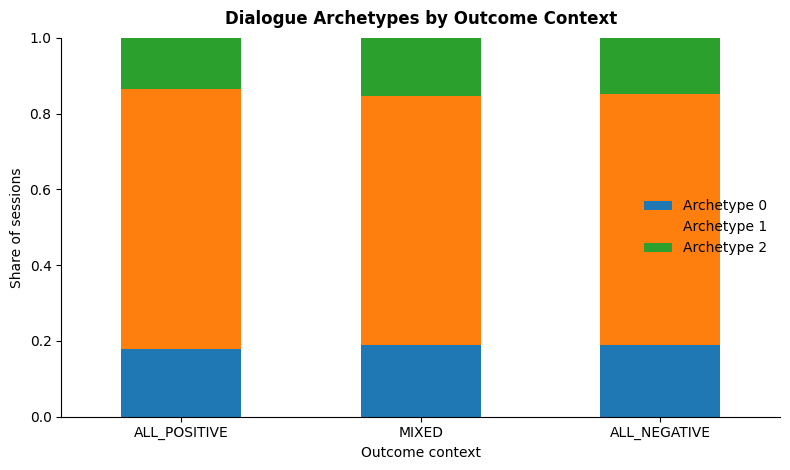

In [39]:
figs = [
    plot_context_support(session_outcome),
    plot_context_box(
        context_multi, "speaker_switch_rate",
        "Speaker Switching by Outcome Context", "Speaker-switch rate"
    ),
    plot_context_box(
        context_multi, "student_turn_share_delta_el",
        "Student Early → Late Shift by Outcome Context", "Late − Early Student turn share"
    ),
    plot_context_trajectory(student_context_trajectory),
    plot_archetype_context(archetype_context)
]

for fig in figs:
    display(fig)
    plt.close(fig)

# 04.8 — Repetition as a Modelling Phenomenon 🔁

Okay, now we'll study what happens when the **same exact content appears again inside a session**.

Repetition is not automatically:

- an error,
- confusion,
- copying,
- failed tutoring,
- or useless evidence.

It is simply an observable dialogue property.

We'll ask:

> **Who repeats whom, how far apart are the repetitions, where do they occur in the session, and how much redundancy do they create?**

The canonical `content_hash` will define exact content identity, so we won't rebuild or re-normalize text.

Let's trace the repetition structure 👇

In [40]:
REPEAT_ROLES = ["student", "tutor"]
REPEAT_PAIRS = ["student→student", "student→tutor", "tutor→student", "tutor→tutor"]


# Repetition events
def build_repetition_events(turns, text_metrics, sessions):
    text = text_metrics[
        ["session_id", "turn_index", "content_hash", "text_norm", "word_count"]
    ].copy()

    text["contains_unclear"] = text["text_norm"].str.contains("[UNCLEAR]", regex=False)
    text.drop(columns="text_norm", inplace=True)

    source = turns[
        [
            "session_id", "turn_index", "role",
            "relative_turn_position", "elapsed_from_session_start",
            "bin_3", "bin_5", "bin_10"
        ]
    ].merge(text, on=["session_id", "turn_index"], validate="1:1")

    source = source.merge(
        sessions[["session_id", "n_turns"]],
        on="session_id", validate="m:1"
    )

    g = source.groupby(["session_id", "content_hash"], sort=False)

    source["occurrence_number"] = g.cumcount() + 1
    source["repeat_group_size"] = g["turn_index"].transform("size")

    source["repeat_prev_turn"] = g["turn_index"].shift()
    source["repeat_prev_role"] = g["role"].shift()
    source["repeat_prev_elapsed"] = g["elapsed_from_session_start"].shift()

    source["repeat_first_turn"] = g["turn_index"].transform("first")
    source["repeat_first_role"] = g["role"].transform("first")
    source["is_repeat"] = source["occurrence_number"].gt(1)

    events = source.loc[source["is_repeat"]].copy()

    events["repeat_lag_turns"] = (
        events["turn_index"] - events["repeat_prev_turn"]
    ).astype("int32")

    events["repeat_lag_seconds"] = (
        events["elapsed_from_session_start"] - events["repeat_prev_elapsed"]
    )

    events["repeat_relative_lag"] = (
        events["repeat_lag_turns"] / (events["n_turns"] - 1)
    )

    events["repeat_role_pair"] = (
        events["repeat_prev_role"].str.cat(events["role"], sep="→")
    )

    groups = (
        source.loc[source["repeat_group_size"].gt(1)]
        .drop_duplicates(["session_id", "content_hash"])
        [
            [
                "session_id", "content_hash", "word_count",
                "repeat_group_size", "repeat_first_turn", "repeat_first_role"
            ]
        ]
        .copy()
    )
    groups["repeat_events_contributed"] = groups["repeat_group_size"] - 1

    source = source[
        [
            "session_id", "turn_index", "role", "word_count",
            "contains_unclear", "bin_3", "bin_5", "bin_10",
            "is_repeat"
        ]
    ]

    return source, events, groups


repetition_source, repeat_events, repeat_groups = build_repetition_events(
    turns_core,
    turn_text_metrics,
    sessions
)

print(f"Turns analysed          : {len(repetition_source):,}")
print(f"Repeated occurrences    : {len(repeat_events):,}")
print(f"Repeated text groups    : {len(repeat_groups):,}")
print(f"Sessions with repetition: {repeat_events['session_id'].nunique():,}")

display(repetition_source.head())
display(repeat_events.head())
display(repeat_groups)

Turns analysed          : 6,139,854
Repeated occurrences    : 965,738
Repeated text groups    : 233,214
Sessions with repetition: 22,814


,session_id,turn_index,role,word_count,contains_unclear,bin_3,bin_5,bin_10,is_repeat
0,aaaedit,0,tutor,1,False,0,0,0,False
1,aaaedit,1,background,1,False,0,0,0,False
2,aaaedit,2,background,1,False,0,0,0,False
3,aaaedit,3,tutor,7,False,0,0,0,False
4,aaaedit,4,student,1,False,0,0,0,False


,session_id,turn_index,role,relative_turn_position,elapsed_from_session_start,bin_3,bin_5,bin_10,content_hash,word_count,...,repeat_prev_turn,repeat_prev_role,repeat_prev_elapsed,repeat_first_turn,repeat_first_role,is_repeat,repeat_lag_turns,repeat_lag_seconds,repeat_relative_lag,repeat_role_pair
6,aaaedit,6,student,0.023715,12.0,0,0,0,22c16c191562325739cf592873463b98dcee8635a53e52...,1,...,4.0,student,7.0,4,student,True,2,5.0,0.007905,student→student
17,aaaedit,17,student,0.067194,139.0,0,0,0,4aee62307dc3bb7003686fd5cc96433ec7074bb4b87870...,1,...,10.0,student,63.0,10,student,True,7,76.0,0.027668,student→student
30,aaaedit,30,student,0.118577,277.0,0,0,1,4aee62307dc3bb7003686fd5cc96433ec7074bb4b87870...,1,...,17.0,student,139.0,10,student,True,13,138.0,0.051383,student→student
43,aaaedit,43,tutor,0.169960,411.0,0,0,1,239674fd86ecd7be8672a4f17e6de45a479c64086d40bb...,1,...,1.0,background,0.0,1,background,True,42,411.0,0.166008,background→tutor
55,aaaedit,55,tutor,0.217391,532.0,0,1,2,5f3ae5049949f6dd9f1986ccf528fc68d8b866946bf400...,3,...,12.0,student,96.0,12,student,True,43,436.0,0.169960,student→tutor


,session_id,content_hash,word_count,repeat_group_size,repeat_first_turn,repeat_first_role,repeat_events_contributed
0,aaaedit,c36b40652bc4e6a89a36d5fd0a79cacb49f113c865de86...,1,2,0,tutor,1
1,aaaedit,239674fd86ecd7be8672a4f17e6de45a479c64086d40bb...,1,4,1,background,3
2,aaaedit,4487548212d8f2f4736ac097d1a3043ffa5f56459056b8...,1,2,2,background,1
4,aaaedit,22c16c191562325739cf592873463b98dcee8635a53e52...,1,2,4,student,1
10,aaaedit,4aee62307dc3bb7003686fd5cc96433ec7074bb4b87870...,1,14,10,student,13
...,...,...,...,...,...,...,...
6139621,nxmkhia,25e60d393e54b97a8d1756e104664c9da7a0c78dcbabed...,1,5,138,student,4
6139640,nxmkhia,646f93e0cef30903f9be7fc1662d5bc7c1624d6579d228...,1,2,157,student,1
6139664,nxmkhia,91c766a45909bb2078564436ed3c87c84c967a7f425bb2...,8,2,181,tutor,1
6139745,nxmkhia,91bf647e3b0cd24da1d6cd4506b979c66604537bad6e99...,2,2,262,student,1


## Who repeats whom — and after how long? 🔍

Each repeated occurrence now has two useful references:

- **first occurrence** → where this exact content originally appeared
- **previous occurrence** → the most recent matching turn

For the modelling analysis, the previous occurrence is especially useful because it gives us:

- role direction,
- turn lag,
- wall-time lag,
- and relative session distance.

We'll keep Student/Tutor repetition as the primary pedagogical view, while Background-involved repetition remains preserved separately.

In [41]:
# Role-direction repeat rates
def build_repeat_role_matrix(source, events):
    current_turns = (
        source.loc[source["role"].isin(REPEAT_ROLES)]
        .groupby("role").size()
        .reindex(REPEAT_ROLES)
    )

    counts = pd.crosstab(
        events.loc[
            events["repeat_prev_role"].isin(REPEAT_ROLES) &
            events["role"].isin(REPEAT_ROLES),
            "repeat_prev_role"
        ],
        events.loc[
            events["repeat_prev_role"].isin(REPEAT_ROLES) &
            events["role"].isin(REPEAT_ROLES),
            "role"
        ]
    ).reindex(index=REPEAT_ROLES, columns=REPEAT_ROLES, fill_value=0)

    return counts.div(current_turns, axis=1)


# Repeat-lag ECDF
def build_repeat_lag_ecdf(events):
    out = (
        events.loc[events["repeat_role_pair"].isin(REPEAT_PAIRS)]
        .groupby(["repeat_role_pair", "repeat_lag_turns"])
        .size().rename("events").reset_index()
        .sort_values(["repeat_role_pair", "repeat_lag_turns"])
    )

    out["ecdf"] = (
        out.groupby("repeat_role_pair")["events"].cumsum() /
        out.groupby("repeat_role_pair")["events"].transform("sum")
    )
    return out


# Temporal repetition trajectory
def build_repetition_trajectory(source, bin_col):
    return (
        source.groupby(["session_id", bin_col], sort=False)
        .agg(
            turns=("turn_index", "size"),
            repeat_events=("is_repeat", "sum")
        )
        .assign(repeat_rate=lambda x: x["repeat_events"] / x["turns"])
        .reset_index()
        .rename(columns={bin_col: "bin"})
    )

repeat_role_matrix = build_repeat_role_matrix(repetition_source, repeat_events)
repeat_lag_ecdf = build_repeat_lag_ecdf(repeat_events)

repeat_trajectory_3 = build_repetition_trajectory(repetition_source, "bin_3")
repeat_trajectory_5 = build_repetition_trajectory(repetition_source, "bin_5")
repeat_trajectory_10 = build_repetition_trajectory(repetition_source, "bin_10")

display(repeat_role_matrix.style.format("{:.2%}"))

role,student,tutor
repeat_prev_role,,
student,20.05%,3.49%
tutor,4.35%,3.23%


In [42]:
# Role-direction × temporal location
def build_repeat_role_time_matrix(source, events, bin_col="bin_5", n_bins=5):
    rows = []

    for pair in REPEAT_PAIRS:
        prev_role, current_role = pair.split("→")

        denominator = (
            source.loc[source["role"].eq(current_role)]
            .groupby(bin_col).size()
            .reindex(range(n_bins), fill_value=0)
        )

        numerator = (
            events.loc[
                events["repeat_prev_role"].eq(prev_role) &
                events["role"].eq(current_role)
            ]
            .groupby(bin_col).size()
            .reindex(range(n_bins), fill_value=0)
        )

        rate = numerator / denominator.replace(0, np.nan)
        rows.append(pd.Series(rate.to_numpy(), index=range(n_bins), name=pair))

    return pd.DataFrame(rows)


repeat_role_time = build_repeat_role_time_matrix(
    repetition_source,
    repeat_events,
    bin_col="bin_5",
    n_bins=5
)

display(repeat_role_time.style.format("{:.2%}"))

,0,1,2,3,4
student→student,15.03%,19.50%,20.91%,21.48%,23.19%
student→tutor,2.77%,3.28%,3.60%,3.81%,3.98%
tutor→student,4.18%,3.83%,4.24%,4.52%,4.98%
tutor→tutor,2.23%,2.98%,3.47%,3.75%,3.72%


In [43]:
# Session-level repetition summary
def summarize_session_repetition(source, events, groups, trajectory, n_bins=5):
    base = (
        source.groupby("session_id", sort=False)
        .agg(
            n_turns=("turn_index", "size"),
            repeat_event_count=("is_repeat", "sum")
        )
    )
    base["repeat_turn_rate"] = base["repeat_event_count"] / base["n_turns"]

    group_stats = (
        groups.groupby("session_id")
        .agg(
            unique_repeated_group_count=("content_hash", "size"),
            max_repeat_multiplicity=("repeat_group_size", "max")
        )
    )

    lag_stats = (
        events.groupby("session_id")
        .agg(
            adjacent_repeat_share=("repeat_lag_turns", lambda x: x.eq(1).mean()),
            median_repeat_lag_turns=("repeat_lag_turns", "median"),
            p90_repeat_lag_turns=("repeat_lag_turns", lambda x: x.quantile(.90)),
            median_repeat_relative_lag=("repeat_relative_lag", "median"),
            unclear_repeat_share=("contains_unclear", "mean")
        )
    )

    role_turns = (
        source.groupby(["session_id", "role"]).size()
        .unstack(fill_value=0)
        .reindex(columns=REPEAT_ROLES, fill_value=0)
    )

    pair_counts = (
        events.loc[
            events["repeat_prev_role"].isin(REPEAT_ROLES) &
            events["role"].isin(REPEAT_ROLES)
        ]
        .groupby(["session_id", "repeat_role_pair"]).size()
        .unstack(fill_value=0)
        .reindex(columns=REPEAT_PAIRS, fill_value=0)
    )

    role_rates = pd.DataFrame(index=base.index)
    for pair in REPEAT_PAIRS:
        current_role = pair.split("→")[1]
        role_rates[f"{pair.replace('→', '_to_')}_repeat_rate"] = (
            pair_counts[pair] /
            role_turns[current_role].replace(0, np.nan)
        )

    background_share = (
        events.loc[
            events["repeat_prev_role"].eq("background") |
            events["role"].eq("background")
        ]
        .groupby("session_id").size() /
        events.groupby("session_id").size()
    ).rename("background_involved_repeat_share")

    rate = (
        trajectory.pivot(index="session_id", columns="bin", values="repeat_rate")
        .reindex(columns=range(n_bins))
    )

    mass = (
        trajectory.pivot(index="session_id", columns="bin", values="repeat_events")
        .reindex(columns=range(n_bins), fill_value=0)
        .fillna(0)
    )

    temporal = rate.copy()
    temporal.columns = [f"repeat_rate_b{i}" for i in range(n_bins)]
    temporal["repeat_delta_el"] = rate.iloc[:, -1] - rate.iloc[:, 0]

    total = mass.sum(axis=1)
    p = mass.div(total.replace(0, np.nan), axis=0)
    temporal["repeat_temporal_entropy"] = (
        -(p * np.log(p.where(p > 0))).sum(axis=1, min_count=1) /
        np.log(n_bins)
    )

    return (
        base.join(group_stats)
        .join(lag_stats)
        .join(role_rates)
        .join(background_share)
        .join(temporal)
        .reset_index()
    )


session_repetition_dynamics = summarize_session_repetition(
    repetition_source,
    repeat_events,
    repeat_groups,
    repeat_trajectory_5,
    n_bins=5
)

session_repetition_dynamics.head(100)

,session_id,n_turns,repeat_event_count,repeat_turn_rate,unique_repeated_group_count,max_repeat_multiplicity,adjacent_repeat_share,median_repeat_lag_turns,p90_repeat_lag_turns,median_repeat_relative_lag,...,tutor_to_student_repeat_rate,tutor_to_tutor_repeat_rate,background_involved_repeat_share,repeat_rate_b0,repeat_rate_b1,repeat_rate_b2,repeat_rate_b3,repeat_rate_b4,repeat_delta_el,repeat_temporal_entropy
0,aaaedit,254,35,0.137795,12.0,14.0,0.057143,20.0,142.6,0.079051,...,0.035088,0.036765,0.057143,0.078431,0.078431,0.160000,0.156863,0.215686,0.137255,0.953286
1,aaaptjd,360,24,0.066667,9.0,8.0,0.041667,48.5,90.8,0.135097,...,0.011236,0.000000,0.208333,0.013889,0.069444,0.125000,0.055556,0.069444,0.055556,0.902456
2,aabkeov,281,52,0.185053,13.0,26.0,0.057692,11.0,93.2,0.039286,...,0.044118,0.021898,0.038462,0.089286,0.160714,0.214286,0.214286,0.245614,0.156328,0.968540
3,aacggvb,235,41,0.174468,15.0,11.0,0.024390,30.0,80.0,0.128205,...,0.062500,0.008475,0.073171,0.063830,0.063830,0.297872,0.234043,0.212766,0.148936,0.898894
4,aadexbc,104,5,0.048077,2.0,5.0,0.200000,17.0,36.0,0.165049,...,0.000000,0.000000,0.200000,0.000000,0.142857,0.050000,0.000000,0.047619,0.047619,0.590436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,absjqop,234,15,0.064103,10.0,4.0,0.133333,34.0,107.2,0.145923,...,0.030612,0.000000,0.200000,0.021277,0.021277,0.086957,0.063830,0.127660,0.106383,0.871078
96,absmyud,278,41,0.147482,8.0,28.0,0.048780,8.0,86.0,0.028881,...,0.032787,0.034483,0.097561,0.142857,0.072727,0.160714,0.127273,0.232143,0.089286,0.959811
97,abtepuj,103,19,0.184466,4.0,15.0,0.000000,7.0,37.2,0.068627,...,0.000000,0.000000,0.157895,0.095238,0.250000,0.190476,0.150000,0.238095,0.142857,0.968715
98,abtmcwd,339,76,0.224189,11.0,25.0,0.026316,14.0,76.5,0.041420,...,0.097222,0.043243,0.039474,0.191176,0.220588,0.328358,0.161765,0.220588,0.029412,0.982446


In [44]:
REPETITION_SUMMARY = [
    "repeat_turn_rate",
    "unique_repeated_group_count",
    "max_repeat_multiplicity",
    "student_to_student_repeat_rate",
    "student_to_tutor_repeat_rate",
    "tutor_to_student_repeat_rate",
    "tutor_to_tutor_repeat_rate",
    "adjacent_repeat_share",
    "median_repeat_lag_turns",
    "p90_repeat_lag_turns",
    "median_repeat_relative_lag",
    "repeat_delta_el",
    "repeat_temporal_entropy",
    "unclear_repeat_share"
]

repeat_summary = (
    session_repetition_dynamics[REPETITION_SUMMARY]
    .quantile([.10, .25, .50, .75, .90, .99]).T
)

repeat_summary.columns = ["p10", "p25", "median", "p75", "p90", "p99"]

display(repeat_summary.round(4))




,p10,p25,median,p75,p90,p99
repeat_turn_rate,0.0915,0.1186,0.1507,0.1859,0.2194,0.2889
unique_repeated_group_count,6.0000,8.0000,10.0000,12.0000,15.0000,21.0000
max_repeat_multiplicity,7.0000,10.0000,15.0000,23.0000,33.0000,56.0000
student_to_student_repeat_rate,0.0787,0.1214,0.1818,0.2562,0.3294,0.4667
student_to_tutor_repeat_rate,0.0091,0.0189,0.0312,0.0459,0.0615,0.1053
tutor_to_student_repeat_rate,0.0125,0.0241,0.0396,0.0588,0.0806,0.1566
tutor_to_tutor_repeat_rate,0.0000,0.0105,0.0238,0.0431,0.0683,0.1481
adjacent_repeat_share,0.0000,0.0152,0.0417,0.0833,0.1429,0.3823
median_repeat_lag_turns,7.0000,10.0000,14.5000,20.5000,27.5000,44.5000
p90_repeat_lag_turns,43.2000,56.8000,74.2000,95.2000,116.8000,161.3870


## Is repetition mostly coming from short generic text? 📝

Exact repetition can be heavily inflated by very short utterances such as:

```text
Yes
No
Okay
Right
[UNCLEAR]

In [45]:
# Word length × repetition
def build_repeat_length_profile(source):
    out = (
        source.groupby("word_count")
        .agg(
            turns=("turn_index", "size"),
            repeat_events=("is_repeat", "sum")
        )
        .reset_index()
    )

    out["repeat_rate"] = out["repeat_events"] / out["turns"]
    return out


# Repeated-group concentration
def build_repeat_concentration(groups):
    contributions = (
        groups["repeat_events_contributed"]
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    return pd.DataFrame({
        "cumulative_group_share": np.arange(1, len(contributions) + 1) / len(contributions),
        "cumulative_repeat_share": contributions.cumsum() / contributions.sum()
    })


repeat_length_profile = build_repeat_length_profile(repetition_source)
repeat_concentration = build_repeat_concentration(repeat_groups)

WORD_LENGTH_P95 = int(repetition_source["word_count"].quantile(.95))

print(f"95% of turns contain ≤ {WORD_LENGTH_P95} whitespace tokens")





top_10_idx = np.searchsorted(
    repeat_concentration["cumulative_group_share"].to_numpy(),
    0.10
)

top_10_repeat_share = repeat_concentration.iloc[
    min(top_10_idx, len(repeat_concentration) - 1)
]["cumulative_repeat_share"]

print(f"Overall repeat-turn rate          : {repetition_source['is_repeat'].mean():.2%}")
print(f"Repeated text groups             : {len(repeat_groups):,}")
print(f"Median session repeat rate       : {session_repetition_dynamics['repeat_turn_rate'].median():.2%}")
print(f"Top 10% groups create            : {top_10_repeat_share:.2%} of repeat events")

95% of turns contain ≤ 48 whitespace tokens
Overall repeat-turn rate          : 15.73%
Repeated text groups             : 233,214
Median session repeat rate       : 15.07%
Top 10% groups create            : 45.83% of repeat events


## Repetition structure at a glance 📊

Now let's visualize five different questions:

1. **Who repeats whom?**
2. **How quickly do repeats happen?**
3. **Does repeat direction change across session time?**
4. **Is repetition mainly driven by short utterances?**
5. **Do a few repeated phrases create most of the redundancy?**

These views are complementary — no single repeat-rate number can answer all five.

In [46]:
# Role-direction matrix
def plot_repeat_role_matrix(matrix):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    im = ax.imshow(matrix.to_numpy(), aspect="auto")

    ax.set_xticks(range(2), ["Student", "Tutor"])
    ax.set_yticks(range(2), ["Student", "Tutor"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2%}", ha="center", va="center")

    DialogueEDAUtils.style_ax(
        ax, "Exact Repetition by Role Direction",
        "Current repeating role", "Previous same-text role"
    )
    fig.colorbar(im, ax=ax, label="Repeat rate")
    fig.tight_layout()
    return fig


# Repeat-lag ECDF
def plot_repeat_lag_ecdf(ecdf):
    fig, ax = plt.subplots(figsize=(8, 5))

    for pair in REPEAT_PAIRS:
        x = ecdf.loc[ecdf["repeat_role_pair"].eq(pair)]
        ax.plot(x["repeat_lag_turns"], x["ecdf"], label=pair)

    ax.set_xscale("log")

    DialogueEDAUtils.style_ax(
        ax, "How Quickly Does Exact Repetition Reappear?",
        "Turn lag (log scale)", "Cumulative share of repeat events"
    )
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


# Role × temporal region
def plot_repeat_role_time(matrix):
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(matrix.to_numpy(), aspect="auto")

    ax.set_xticks(range(5), ["Early", "2", "3", "4", "Late"])
    ax.set_yticks(range(len(matrix)), matrix.index)

    for i in range(len(matrix)):
        for j in range(5):
            ax.text(j, i, f"{matrix.iloc[i, j]:.1%}", ha="center", va="center")

    DialogueEDAUtils.style_ax(
        ax, "Role-Directed Repetition Across Session Time",
        "Temporal region", "Repeat direction"
    )
    fig.colorbar(im, ax=ax, label="Repeat rate")
    fig.tight_layout()
    return fig


# Word length × repeat probability
def plot_repeat_length(profile, max_words):
    view = profile.loc[profile["word_count"].le(max_words)]

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.plot(view["word_count"], view["repeat_rate"], marker="o", markersize=3)

    DialogueEDAUtils.style_ax(
        ax, "Exact Repetition vs Utterance Length",
        "Whitespace-token count", "Exact-repeat rate"
    )
    fig.tight_layout()
    return fig


# Repeated-group concentration
def plot_repeat_concentration(curve):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        curve["cumulative_group_share"],
        curve["cumulative_repeat_share"]
    )
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2)

    DialogueEDAUtils.style_ax(
        ax, "Concentration of Repeated Dialogue",
        "Cumulative share of repeated text groups",
        "Cumulative share of repeat events"
    )
    fig.tight_layout()
    return fig

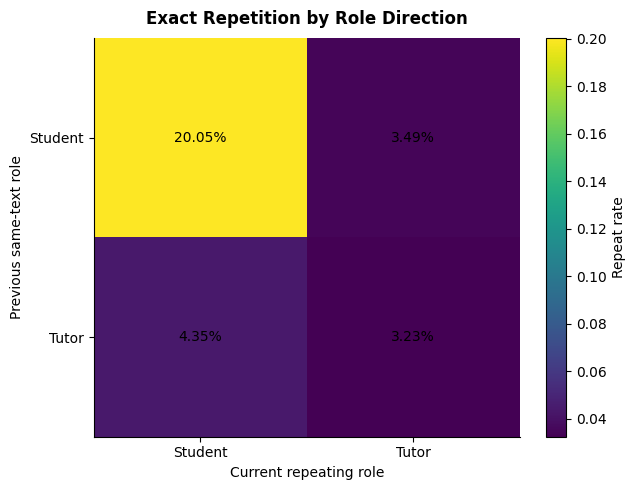

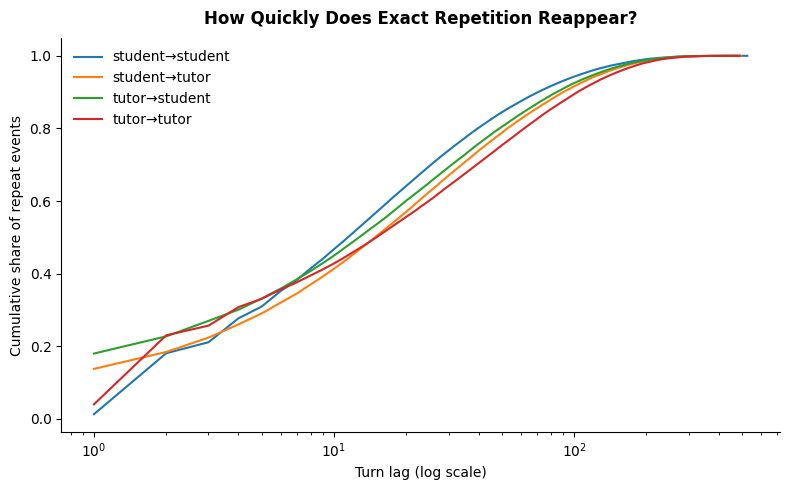

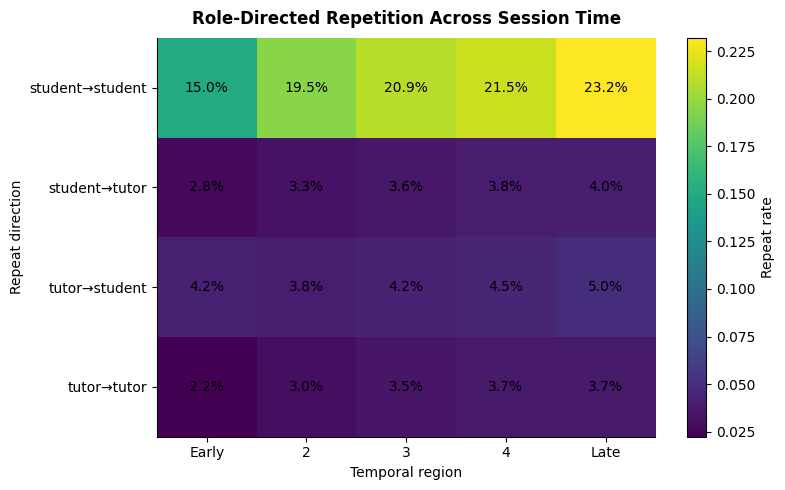

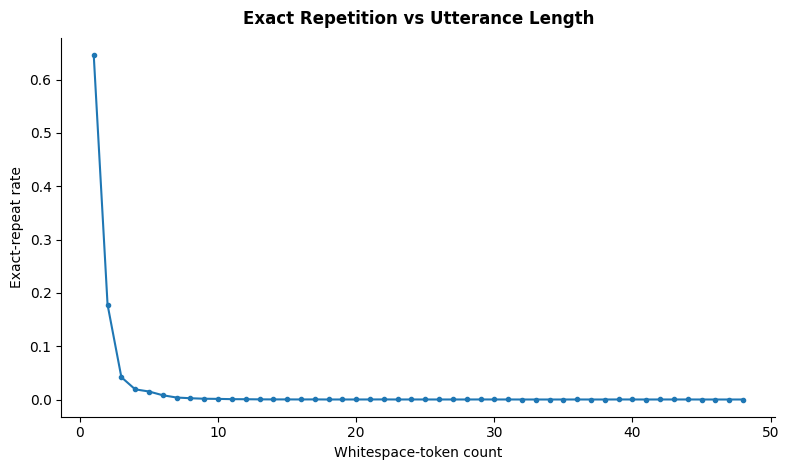

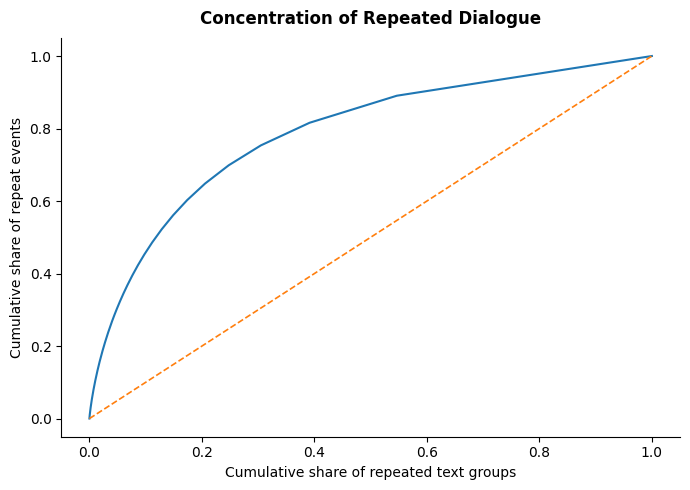

In [47]:
figs = [
    plot_repeat_role_matrix(repeat_role_matrix),
    plot_repeat_lag_ecdf(repeat_lag_ecdf),
    plot_repeat_role_time(repeat_role_time),
    plot_repeat_length(repeat_length_profile, WORD_LENGTH_P95),
    plot_repeat_concentration(repeat_concentration)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.8 — Insight 💡

Exact repetition is a regular part of the tutoring dialogue rather than a rare event. The median session contains roughly **15% repeated turns**, with about **10 repeated text groups**, while the most frequently repeated text in a typical session can appear around **15 times**.

The repetition structure is strongly asymmetric. **Student → Student** exact repetition is by far the dominant pedagogical direction (`20.05%`), whereas Student–Tutor cross-role and Tutor self-repetition rates are much smaller. Cross-role repeats also tend to reappear more locally, while self-repetition is distributed over longer turn distances.

Repetition becomes increasingly common toward the end of a session, especially for Student self-repetition (`15.0% → 23.2%`). However, this should not be interpreted as a behavioural deterioration: later turns also have a much larger history available to repeat from, so temporal exposure itself contributes to the increase.

The strongest guardrail comes from utterance length. Exact-repeat probability is extremely high for **one-word turns (~65%)**, falls sharply for two- and three-word turns, and becomes very small for longer utterances. This shows that much of the raw repetition signal is driven by short dialogue units rather than repeated substantive explanations.

Repeated dialogue is also highly concentrated: a relatively small fraction of within-session repeated-text groups accounts for a large share of all repeat events.

> **Takeaway:** raw repetition rate alone is too coarse. The useful modelling information lies in **role direction, lag, text length, multiplicity, and redundancy concentration**. Repeated turns should remain in the canonical transcript, but later retrieval and evidence packing should explicitly test whether highly repetitive evidence should be downweighted or diversified rather than counted as fully independent evidence. 🔁

# 04.9 — Context Length & Packing Pressure 📏

Hmm, a turn can be only **one turn** structurally but still carry a very large share of the session's text.

So now we'll ask:

> **Can a small number of turns dominate the available dialogue context?**

We'll study:

- utterance length by role,
- where long-tail turns appear in session time,
- how much session text one or a few turns can dominate,
- local neighbourhood dominance,
- and how repetition changes the actual textual mass.

A few important boundaries:

> **Long turn ≠ bad turn**  
> **Long turn ≠ automatically truncate**  
> **Long Student turn ≠ mastery**  
> **Long Tutor turn ≠ useless explanation**

We'll reuse the frozen `word_count` for this stage. Exact ModernBERT token-budget analysis will come later when the production tokenizer is frozen.

Okay, let's map the context pressure 👇

In [48]:
# Turn-length dynamics
def build_turn_length_dynamics(repetition):
    out = repetition[
        [
            "session_id", "turn_index", "role", "word_count",
            "bin_3", "bin_5", "bin_10", "is_repeat"
        ]
    ].copy()

    g = out.groupby("session_id", sort=False)
    total = g["word_count"].transform("sum")

    prev_words = g["word_count"].shift(1).fillna(0)
    next_words = g["word_count"].shift(-1).fillna(0)
    local_total = prev_words + out["word_count"] + next_words

    out["turn_session_share"] = out["word_count"] / total
    out["local_dominance"] = out["word_count"] / local_total

    return out


# Role × temporal length
def build_role_time_length(data, bin_col):
    return (
        data.groupby(["session_id", "role", bin_col], sort=False)["word_count"]
        .quantile(.95)
        .rename("p95_words")
        .reset_index()
        .rename(columns={bin_col: "bin"})
    )


# Session-level length summary
def summarize_session_length(data):
    g = data.groupby("session_id", sort=False)

    out = g["word_count"].agg(
        total_words="sum",
        median_turn_words="median",
        max_turn_words="max"
    )
    out["p95_turn_words"] = g["word_count"].quantile(.95)
    out["max_turn_share"] = g["turn_session_share"].max()

    top3_words = g["word_count"].nlargest(3).groupby(level=0).sum()
    out["top3_turn_share"] = top3_words / out["total_words"]

    out["max_local_dominance"] = g["local_dominance"].max()
    out["p95_local_dominance"] = g["local_dominance"].quantile(.95)

    repeat_words = (
        data["word_count"].where(data["is_repeat"], 0)
        .groupby(data["session_id"], sort=False).sum()
    )
    out["repeat_word_mass_share"] = repeat_words / out["total_words"]

    role_p95 = (
        data.groupby(["session_id", "role"], sort=False)["word_count"]
        .quantile(.95).unstack("role")
        .reindex(columns=ROLES)
        .add_suffix("_p95_words")
    )

    return out.join(role_p95).reset_index()


# Turn-mass concentration
def build_turn_mass_concentration(data, grid=np.arange(.05, 1.01, .05)):
    ranked = (
        data[["session_id", "word_count"]]
        .sort_values(["session_id", "word_count"], ascending=[True, False])
    )

    g = ranked.groupby("session_id", sort=False)

    ranked["rank"] = g.cumcount() + 1
    ranked["n_turns"] = g["word_count"].transform("size")
    ranked["cumulative_word_share"] = (
        g["word_count"].cumsum() /
        g["word_count"].transform("sum")
    )

    session_sizes = (
        ranked.groupby("session_id", sort=False)["n_turns"]
        .first()
        .reset_index()
    )

    targets = pd.concat([
        session_sizes.assign(
            top_turn_share=share,
            rank=np.ceil(session_sizes["n_turns"] * share).astype("int32")
        )[["session_id", "top_turn_share", "rank"]]
        for share in grid
    ], ignore_index=True)

    values = targets.merge(
        ranked[["session_id", "rank", "cumulative_word_share"]],
        on=["session_id", "rank"],
        validate="m:1"
    )

    return (
        values.groupby("top_turn_share")["cumulative_word_share"]
        .agg(
            median="median",
            q25=lambda x: x.quantile(.25),
            q75=lambda x: x.quantile(.75)
        )
        .reset_index()
    )

In [49]:
turn_length_dynamics = build_turn_length_dynamics(repetition_source)

role_time_3 = build_role_time_length(turn_length_dynamics, "bin_3")
role_time_5 = build_role_time_length(turn_length_dynamics, "bin_5")
role_time_10 = build_role_time_length(turn_length_dynamics, "bin_10")

session_length_dynamics = summarize_session_length(turn_length_dynamics)

turn_mass_concentration = build_turn_mass_concentration(turn_length_dynamics)

print(f"Turns summarized    : {len(turn_length_dynamics):,}")
print(f"Sessions summarized : {len(session_length_dynamics):,}")

display(turn_length_dynamics.head(50))
display(session_length_dynamics.head(50))
display(turn_mass_concentration.head(50))

Turns summarized    : 6,139,854
Sessions summarized : 22,821


,session_id,turn_index,role,word_count,bin_3,bin_5,bin_10,is_repeat,turn_session_share,local_dominance
0,aaaedit,0,tutor,1,0,0,0,False,0.000321,0.500000
1,aaaedit,1,background,1,0,0,0,False,0.000321,0.333333
2,aaaedit,2,background,1,0,0,0,False,0.000321,0.111111
3,aaaedit,3,tutor,7,0,0,0,False,0.002246,0.777778
4,aaaedit,4,student,1,0,0,0,False,0.000321,0.055556
5,aaaedit,5,tutor,10,0,0,0,False,0.003208,0.833333
6,aaaedit,6,student,1,0,0,0,True,0.000321,0.050000
7,aaaedit,7,tutor,9,0,0,0,False,0.002887,0.118421
8,aaaedit,8,student,66,0,0,0,False,0.021174,0.660000
9,aaaedit,9,tutor,25,0,0,0,False,0.008021,0.271739


,session_id,total_words,median_turn_words,max_turn_words,p95_turn_words,max_turn_share,top3_turn_share,max_local_dominance,p95_local_dominance,repeat_word_mass_share,student_p95_words,tutor_p95_words,background_p95_words
0,aaaedit,3117,7.0,71,42.00,0.022778,0.066089,0.965517,0.871989,0.014116,40.45,42.00,6.70
1,aaaptjd,6306,9.0,154,63.05,0.024421,0.060260,0.950820,0.892034,0.003806,40.00,78.40,57.60
2,aabkeov,3031,6.0,110,41.00,0.036292,0.087760,0.943820,0.840909,0.018476,40.25,43.40,32.95
3,aacggvb,4107,7.0,194,71.80,0.047236,0.110299,0.984848,0.917667,0.012905,43.85,91.60,25.80
4,aadexbc,2618,15.0,123,96.65,0.046982,0.132544,0.920000,0.754009,0.001910,24.55,102.00,4.80
5,aadinwu,2160,4.0,123,35.00,0.056944,0.126389,0.966667,0.918000,0.026852,13.00,43.30,8.00
6,aadljmq,3794,7.0,75,30.45,0.019768,0.050870,0.967213,0.897105,0.020559,21.00,37.45,19.70
7,aadmino,2856,11.0,81,41.30,0.028361,0.068627,0.941176,0.839728,0.014006,37.40,48.00,34.40
8,aadsgow,3494,10.0,61,43.40,0.017459,0.049227,0.960784,0.862069,0.010017,33.00,46.60,23.00
9,aadylxv,4309,11.0,132,78.00,0.030634,0.084010,0.973214,0.908059,0.007890,25.00,86.75,43.80


,top_turn_share,median,q25,q75
0,0.05,0.243725,0.225700,0.264287
1,0.10,0.390732,0.367276,0.416823
2,0.15,0.503736,0.478270,0.531896
3,0.20,0.592828,0.567327,0.620845
4,0.25,0.666667,0.642070,0.693616
5,0.30,0.728707,0.705545,0.753916
6,0.35,0.780958,0.759352,0.803520
7,0.40,0.824304,0.804822,0.844366
8,0.45,0.861470,0.844192,0.879012
9,0.50,0.892106,0.876907,0.906988


## What does the length structure look like? 🔍

Okay, before plotting let's get three compact views:

1. **Role-wise length scale**
2. **Role × session-time long-tail**
3. **Session-level context concentration**

The 5-bin view will remain primary, while 3 and 10 bins act as temporal robustness checks.

In [50]:
role_length_summary = (
    turn_length_dynamics.groupby("role")["word_count"]
    .quantile([.50, .75, .90, .95, .99])
    .unstack()
    .reindex(ROLES)
)
role_length_summary.columns = ["median", "p75", "p90", "p95", "p99"]

role_time_heatmap = (
    role_time_5.groupby(["role", "bin"])["p95_words"]
    .median().unstack("bin")
    .reindex(index=ROLES, columns=range(5))
)

resolution_rows = []
for name, table in {"3-bin": role_time_3, "5-bin": role_time_5, "10-bin": role_time_10}.items():
    med = (
        table.groupby(["role", "bin"])["p95_words"]
        .median().unstack("bin")
        .reindex(ROLES)
    )
    resolution_rows.append((med.iloc[:, -1] - med.iloc[:, 0]).rename(name))

role_time_resolution = pd.concat(resolution_rows, axis=1)

SESSION_LENGTH_COLS = [
    "total_words", "median_turn_words", "p95_turn_words", "max_turn_words",
    "max_turn_share", "top3_turn_share",
    "max_local_dominance", "p95_local_dominance",
    "repeat_word_mass_share",
    "student_p95_words", "tutor_p95_words", "background_p95_words"
]

session_length_summary = (
    session_length_dynamics[SESSION_LENGTH_COLS]
    .quantile([.10, .25, .50, .75, .90, .99]).T
)
session_length_summary.columns = ["p10", "p25", "median", "p75", "p90", "p99"]

display(role_length_summary.round(2))
display(role_time_heatmap.round(2))
display(role_time_resolution.round(2))
display(session_length_summary.round(4))

checks = {
    "turn_rows_preserved": len(turn_length_dynamics) == len(turns_core),
    "session_rows_preserved": len(session_length_dynamics) == len(sessions),
    "session_share_range": turn_length_dynamics["turn_session_share"].between(0, 1).all(),
    "local_dominance_range": turn_length_dynamics["local_dominance"].between(0, 1).all(),
    "repeat_mass_range": session_length_dynamics["repeat_word_mass_share"].between(0, 1).all()
}

failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise AssertionError(f"04.9 audit failed: {failed}")

print("\n04.9 audit : PASS ✅")
print(f"Turn rows  : {len(turn_length_dynamics):,}")
print(f"Sessions   : {len(session_length_dynamics):,}")
print("Failed     : 0")



repeat_mass_context = (
    session_repetition_dynamics[["session_id", "repeat_turn_rate"]]
    .merge(
        session_length_dynamics[["session_id", "repeat_word_mass_share"]],
        on="session_id", validate="1:1"
    )
)

display(repeat_mass_context.head(40))

,median,p75,p90,p95,p99
role,,,,,
student,3.0,9.0,21.0,32.0,60.0
tutor,12.0,24.0,42.0,57.0,90.0
background,5.0,13.0,27.0,39.0,70.0


bin,0,1,2,3,4
role,,,,,
student,21.45,24.65,24.85,24.85,24.45
tutor,42.45,47.20,47.15,46.80,50.30
background,6.70,13.00,13.50,13.00,13.00


,3-bin,5-bin,10-bin
role,,,
student,2.0,3.00,5.25
tutor,4.2,7.85,15.50
background,4.4,6.30,8.00


,p10,p25,median,p75,p90,p99
total_words,2410.0000,2998.0000,3625.0000,4206.0000,4752.0000,5745.0000
median_turn_words,6.0000,6.0000,7.0000,9.0000,10.0000,14.0000
p95_turn_words,33.0000,38.1500,45.7000,55.0000,65.5500,90.2400
max_turn_words,69.0000,81.0000,99.0000,120.0000,145.0000,212.0000
max_turn_share,0.0194,0.0229,0.0278,0.0349,0.0442,0.0758
top3_turn_share,0.0527,0.0613,0.0731,0.0890,0.1093,0.1768
max_local_dominance,0.9429,0.9583,0.9692,0.9767,0.9817,0.9880
p95_local_dominance,0.8023,0.8395,0.8753,0.9052,0.9259,0.9520
repeat_word_mass_share,0.0067,0.0093,0.0131,0.0175,0.0228,0.0418
student_p95_words,17.6000,22.1500,28.6000,36.4000,45.4000,66.8000



04.9 audit : PASS ✅
Turn rows  : 6,139,854
Sessions   : 22,821
Failed     : 0


,session_id,repeat_turn_rate,repeat_word_mass_share
0,aaaedit,0.137795,0.014116
1,aaaptjd,0.066667,0.003806
2,aabkeov,0.185053,0.018476
3,aacggvb,0.174468,0.012905
4,aadexbc,0.048077,0.001910
5,aadinwu,0.214592,0.026852
6,aadljmq,0.196237,0.020559
7,aadmino,0.123077,0.014006
8,aadsgow,0.124528,0.010017
9,aadylxv,0.119149,0.007890


## Context pressure at a glance 📊

Now let's look at five different questions:

1. **Which role produces the heavier utterance-length tail?**
2. **Where in the session do long-tail turns appear?**
3. **Does a long turn also dominate its local neighbourhood?**
4. **How few turns carry most of the session's text?**
5. **Are repeated turns mostly tiny responses or substantial repeated text?**

These plots describe context pressure — they do not define a truncation policy.

In [51]:
# Role-wise length ECDF
def plot_role_length_ecdf(data):
    q = np.linspace(.001, 1, 1000)

    fig, ax = plt.subplots(figsize=(8, 5))

    for role in ROLES:
        values = data.loc[
            data["role"].eq(role) & data["word_count"].gt(0),
            "word_count"
        ]
        ax.plot(values.quantile(q).to_numpy(), q, label=role.title())

    ax.set_xscale("log")
    DialogueEDAUtils.style_ax(
        ax, "Turn-Length Distribution by Role",
        "Whitespace-token count (log scale)", "Cumulative share of turns"
    )
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


# Role × temporal long-tail
def plot_role_time_length(matrix):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    im = ax.imshow(matrix.to_numpy(), aspect="auto")

    ax.set_xticks(range(5), ["Early", "2", "3", "4", "Late"])
    ax.set_yticks(range(len(matrix)), [r.title() for r in matrix.index])

    for i in range(len(matrix)):
        for j in range(5):
            ax.text(j, i, f"{matrix.iloc[i, j]:.1f}", ha="center", va="center")

    DialogueEDAUtils.style_ax(
        ax, "Role-Specific Long-Tail Across Session Time",
        "Temporal region", "Role"
    )
    fig.colorbar(im, ax=ax, label="Median session-level p95 word count")
    fig.tight_layout()
    return fig


# Absolute length vs local context dominance
def plot_length_local_dominance(data, sample_size=300_000):
    view = data.loc[
        data["word_count"].gt(0),
        ["word_count", "local_dominance"]
    ]
    view = view.sample(min(sample_size, len(view)), random_state=42)

    fig, ax = plt.subplots(figsize=(8, 5.2))
    hb = ax.hexbin(
        view["word_count"],
        view["local_dominance"],
        gridsize=55,
        mincnt=1,
        xscale="log"
    )

    DialogueEDAUtils.style_ax(
        ax, "Turn Length vs Local Context Dominance",
        "Whitespace-token count (log scale)", "Immediate-neighbourhood dominance"
    )
    fig.colorbar(hb, ax=ax, label="Turn density")
    fig.tight_layout()
    return fig


# Session text concentration
def plot_turn_mass_concentration(curve):
    fig, ax = plt.subplots(figsize=(7.5, 5))

    ax.plot(
        curve["top_turn_share"],
        curve["median"],
        marker="o",
        label="Median session"
    )
    ax.fill_between(
        curve["top_turn_share"],
        curve["q25"],
        curve["q75"],
        alpha=.15,
        label="IQR"
    )
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, label="Equal-length reference")

    DialogueEDAUtils.style_ax(
        ax, "How Concentrated Is Session Text?",
        "Top cumulative share of turns", "Cumulative share of session words"
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig


# Repeated turns vs repeated textual mass
def plot_repeat_turn_vs_mass(data):
    fig, ax = plt.subplots(figsize=(7.5, 5))
    hb = ax.hexbin(
        data["repeat_turn_rate"],
        data["repeat_word_mass_share"],
        gridsize=45,
        mincnt=1
    )

    limit = max(
        data["repeat_turn_rate"].max(),
        data["repeat_word_mass_share"].max()
    )
    ax.plot([0, limit], [0, limit], linestyle="--", linewidth=1.2)

    DialogueEDAUtils.style_ax(
        ax, "Repeated Turns vs Repeated Textual Mass",
        "Repeat-turn rate", "Repeated word-mass share"
    )
    fig.colorbar(hb, ax=ax, label="Sessions")
    fig.tight_layout()
    return fig

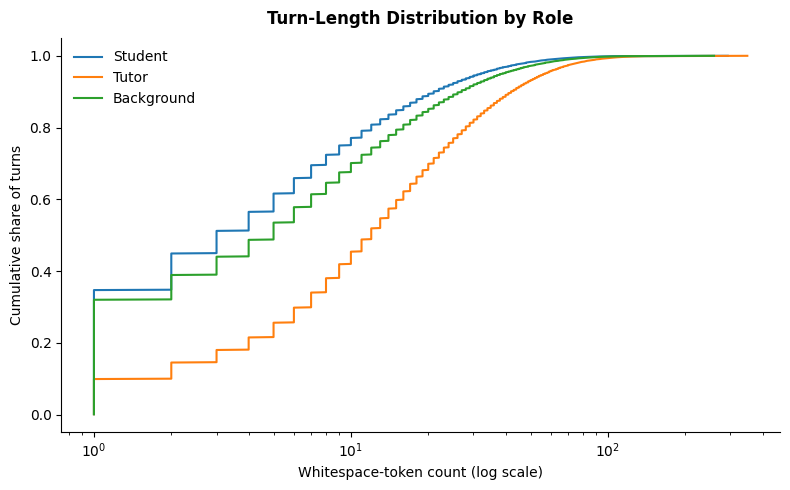

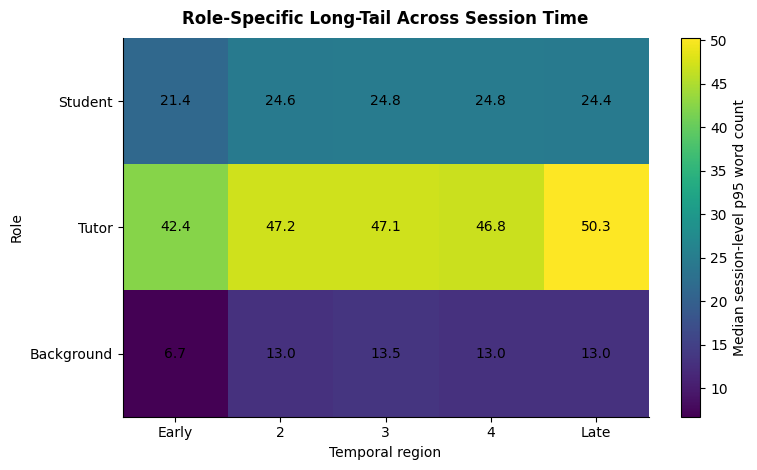

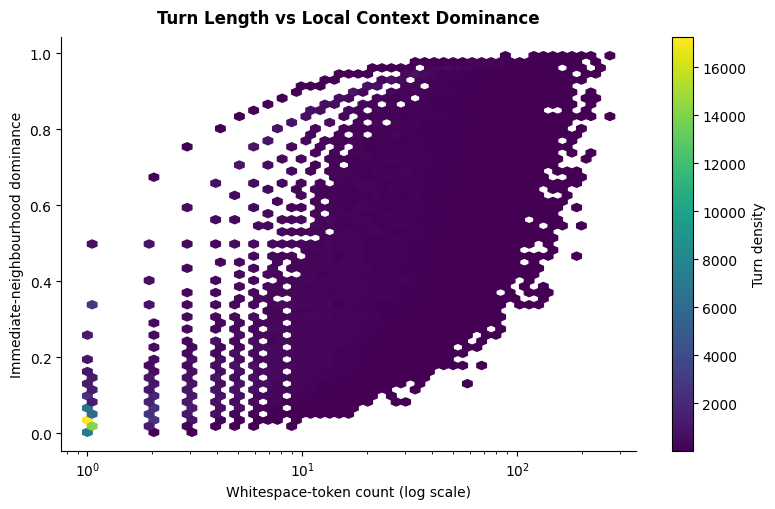

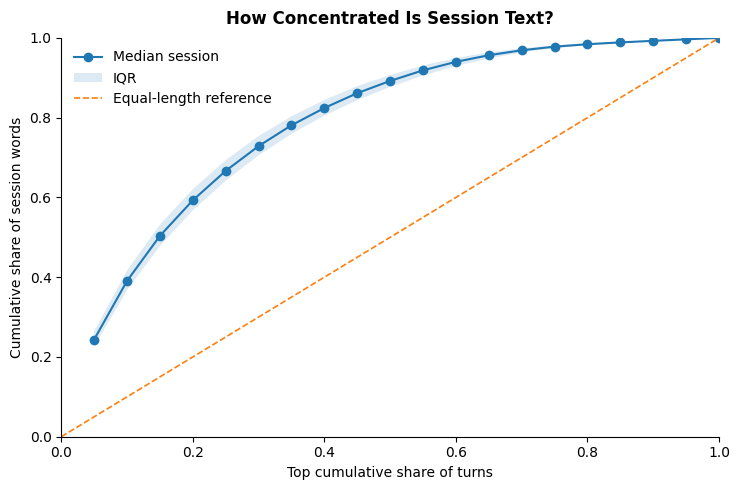

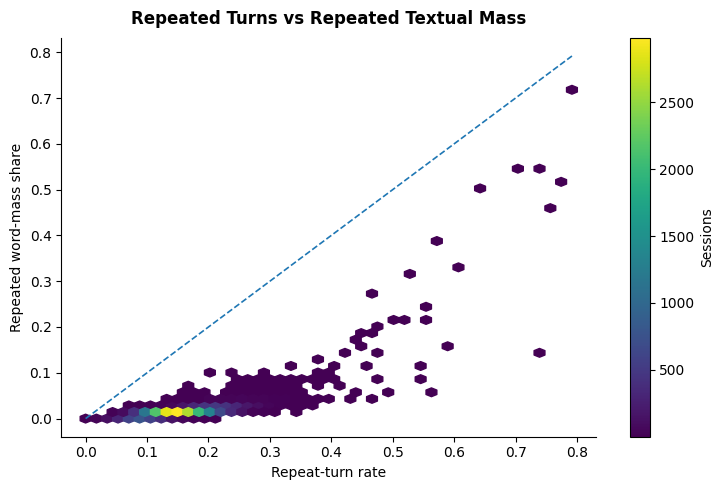

In [52]:
figs = [
    plot_role_length_ecdf(turn_length_dynamics),
    plot_role_time_length(role_time_heatmap),
    plot_length_local_dominance(turn_length_dynamics),
    plot_turn_mass_concentration(turn_mass_concentration),
    plot_repeat_turn_vs_mass(repeat_mass_context)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.9 — Insight 💡

Dialogue length is highly uneven across both roles and turns.

Tutor utterances are substantially longer than Student utterances across the entire distribution: the median Tutor turn contains **12 words** versus only **3 words** for Student turns, while the p95 values are **57 vs 32 words**. Tutor turns therefore represent the strongest role-specific source of potential context pressure.

The long-tail also shifts later in the session. Across the 3 / 5 / 10-bin views, early-to-late p95 length increases consistently for all roles, with the strongest change occurring for Tutor turns. The exact magnitude is resolution-dependent, but the direction is stable.

Session text is strongly concentrated in a relatively small number of turns. In a typical session, roughly the **top 15% of turns carry about half of the total word mass**, while the top half of turns carry close to **90%**. Turn count therefore does not represent context cost uniformly.

Absolute turn length and local dominance are related but not equivalent: turns of similar length can occupy very different shares of their immediate neighbourhood. This makes local context pressure a useful complement to raw utterance length.

Repetition becomes especially informative when measured by textual mass. Most sessions lie well below the `repeat-turn rate = repeat-word-mass share` reference line, showing that repeated turns are usually much shorter than average turns. This confirms the earlier finding that exact repetition is largely driven by short dialogue units, although a smaller tail of highly repetitive sessions also carries substantial repeated text.

> **Takeaway:** future evidence packing should not treat every selected turn as having equal context cost. The important packing dimensions are **relevance, role, turn length, local dominance, and repetition-aware textual diversity**. Exact 2048-token pressure should be measured later using the frozen production tokenizer rather than approximated from word counts. 📏

# 04.10 — Robustness & Trust Audit 🛡️

Okay, 04.1 → 04.9 told us **what patterns exist**.

Now the question is different:

> **Which of those findings are actually stable enough to trust?**

We will not discover new signals here.

Instead, a small set of important findings is frozen first and then tested using only the robustness checks that are relevant to each finding:

- session-level bootstrap uncertainty
- micro vs macro aggregation
- 3 / 5 / 10-bin temporal stability
- frozen-fold consistency
- objective-count sensitivity

The independent resampling unit is always the **session**, never individual turns or events.

Let's audit the evidence 👇

In [53]:
# 5-bin Tutor late-shift
tutor_p95 = role_time_5[role_time_5["role"].eq("tutor")].pivot(index="session_id", columns="bin", values="p95_words")
tutor_p95_shift = (tutor_p95.iloc[:, -1] - tutor_p95.iloc[:, 0]).rename("F10_tutor_p95_late_shift")

# Frozen session-level structural effects
structural_effects = session_temporal_dynamics[["session_id", "student_turn_share_delta_el"]].merge(
    session_length_dynamics[["session_id", "student_p95_words", "tutor_p95_words", "top3_turn_share", "repeat_word_mass_share"]],
    on="session_id", validate="1:1"
)
structural_effects = structural_effects.merge(
    session_repetition_dynamics[["session_id", "repeat_turn_rate", "student_to_student_repeat_rate", "tutor_to_student_repeat_rate"]],
    on="session_id", validate="1:1"
).set_index("session_id")

structural_effects["F01_tutor_student_p95_gap"] = structural_effects["tutor_p95_words"] - structural_effects["student_p95_words"]
structural_effects["F02_student_delta_el"] = structural_effects["student_turn_share_delta_el"]
structural_effects["F03_student_self_repeat_margin"] = structural_effects["student_to_student_repeat_rate"] - structural_effects["tutor_to_student_repeat_rate"]
structural_effects["F04_repeat_turn_mass_gap"] = structural_effects["repeat_turn_rate"] - structural_effects["repeat_word_mass_share"]
structural_effects["F05_top3_turn_share"] = structural_effects["top3_turn_share"]

structural_effects = structural_effects.join(tutor_p95_shift)[[
    "F01_tutor_student_p95_gap", "F02_student_delta_el", "F03_student_self_repeat_margin",
    "F04_repeat_turn_mass_gap", "F05_top3_turn_share", "F10_tutor_p95_late_shift"
]]

OUTCOME_FINDINGS = {
    "F06_outcome_student_share": "student_share",
    "F07_outcome_student_delta": "student_turn_share_delta_el",
    "F08_outcome_speaker_switch": "speaker_switch_rate",
    "F09_outcome_math_concentration": "math_count_concentration"
}

In [54]:
# Session-level structural bootstrap
def bootstrap_session_effects(data, n_boot=1000, random_state=42):
    x = data.to_numpy(dtype="float64")
    rng = np.random.default_rng(random_state)
    original = np.nanmedian(x, axis=0)
    boot = np.empty((n_boot, x.shape[1]))

    for i in range(n_boot):
        boot[i] = np.nanmedian(x[rng.integers(0, len(x), len(x))], axis=0)

    low, high = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    stability = np.array([np.nan if value == 0 else np.mean(np.sign(boot[:, j]) == np.sign(value)) for j, value in enumerate(original)])

    return pd.DataFrame({
        "finding_id": data.columns, "effect_original": original, "bootstrap_median": np.nanmedian(boot, axis=0),
        "ci_low": low, "ci_high": high, "sign_stability": stability, "support_sessions": data.notna().sum().to_numpy(),
        "relative_ci_width": (high - low) / (np.abs(original) + 1e-6)
    })


# POS vs NEG session-context bootstrap
def bootstrap_context_effects(data, findings, n_boot=1000, random_state=42):
    signals = list(findings.values())
    pos = data.loc[data["outcome_context"].eq("ALL_POSITIVE"), signals].to_numpy(dtype="float64")
    neg = data.loc[data["outcome_context"].eq("ALL_NEGATIVE"), signals].to_numpy(dtype="float64")

    rng = np.random.default_rng(random_state)
    original = np.nanmedian(pos, axis=0) - np.nanmedian(neg, axis=0)
    boot = np.empty((n_boot, len(signals)))

    for i in range(n_boot):
        p = pos[rng.integers(0, len(pos), len(pos))]
        n = neg[rng.integers(0, len(neg), len(neg))]
        boot[i] = np.nanmedian(p, axis=0) - np.nanmedian(n, axis=0)

    low, high = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    stability = np.array([np.nan if value == 0 else np.mean(np.sign(boot[:, j]) == np.sign(value)) for j, value in enumerate(original)])

    return pd.DataFrame({
        "finding_id": list(findings), "effect_original": original, "bootstrap_median": np.nanmedian(boot, axis=0),
        "ci_low": low, "ci_high": high, "sign_stability": stability, "support_sessions": len(pos) + len(neg),
        "relative_ci_width": (high - low) / (np.abs(original) + 1e-6)
    })

N_BOOT = 1000

structural_bootstrap = bootstrap_session_effects(structural_effects, N_BOOT)
outcome_bootstrap = bootstrap_context_effects(context_multi, OUTCOME_FINDINGS, N_BOOT)
bootstrap_results = pd.concat([structural_bootstrap, outcome_bootstrap], ignore_index=True)

display(bootstrap_results[[
    "finding_id", "effect_original", "ci_low", "ci_high",
    "sign_stability", "support_sessions", "relative_ci_width"
]].round(4))

display(structural_bootstrap.head())
display(outcome_bootstrap.head())

,finding_id,effect_original,ci_low,ci_high,sign_stability,support_sessions,relative_ci_width
0,F01_tutor_student_p95_gap,22.8250,22.5494,23.0506,1.000,22816,0.0220
1,F02_student_delta_el,0.0108,0.0091,0.0121,1.000,22821,0.2777
2,F03_student_self_repeat_margin,0.1382,0.1367,0.1402,1.000,22797,0.0253
3,F04_repeat_turn_mass_gap,0.1369,0.1362,0.1375,1.000,22821,0.0096
4,F05_top3_turn_share,0.0731,0.0727,0.0733,1.000,22821,0.0082
5,F10_tutor_p95_late_shift,6.5500,6.2987,6.8500,1.000,22814,0.0842
6,F06_outcome_student_share,0.0036,-0.0004,0.0099,0.947,5157,2.8939
7,F07_outcome_student_delta,0.0127,-0.0030,0.0149,0.882,5157,1.4186
8,F08_outcome_speaker_switch,0.0021,-0.0040,0.0068,0.673,5157,5.0528
9,F09_outcome_math_concentration,-0.0087,-0.0295,0.0198,0.658,5157,5.6781


,finding_id,effect_original,bootstrap_median,ci_low,ci_high,sign_stability,support_sessions,relative_ci_width
0,F01_tutor_student_p95_gap,22.825000,22.800000,22.549375,23.050625,1.0,22816,0.021961
1,F02_student_delta_el,0.010753,0.010753,0.009091,0.012077,1.0,22821,0.277708
2,F03_student_self_repeat_margin,0.138158,0.138264,0.136691,0.140187,1.0,22797,0.025306
3,F04_repeat_turn_mass_gap,0.136882,0.136890,0.136222,0.137542,1.0,22821,0.009644
4,F05_top3_turn_share,0.073079,0.073076,0.072739,0.073338,1.0,22821,0.008197


,finding_id,effect_original,bootstrap_median,ci_low,ci_high,sign_stability,support_sessions,relative_ci_width
0,F06_outcome_student_share,0.003581,0.003523,-0.000428,0.009939,0.947,5157,2.893907
1,F07_outcome_student_delta,0.012658,0.011408,-0.003033,0.014925,0.882,5157,1.418580
2,F08_outcome_speaker_switch,0.002140,0.002008,-0.004003,0.006817,0.673,5157,5.052824
3,F09_outcome_math_concentration,-0.008681,-0.006858,-0.029454,0.019841,0.658,5157,5.678120


## Does the finding survive a different analytical view? 🔬

Bootstrap checks session-sampling uncertainty.

Now we'll check two different failure modes:

- **Micro vs Macro** → are large sessions dominating event-derived findings?
- **Temporal Resolution** → does the same direction survive 3 / 5 / 10 bins?

These checks are only applied where they are methodologically relevant.

In [55]:
# Micro vs macro for event-derived findings
global_repeat_mass = turn_length_dynamics.loc[turn_length_dynamics["is_repeat"], "word_count"].sum() / turn_length_dynamics["word_count"].sum()

micro_macro_results = pd.DataFrame([
    ["F03_student_self_repeat_margin",
     repeat_role_matrix.loc["student", "student"] - repeat_role_matrix.loc["tutor", "student"],
     structural_effects["F03_student_self_repeat_margin"].mean()],
    ["F04_repeat_turn_mass_gap",
     repetition_source["is_repeat"].mean() - global_repeat_mass,
     structural_effects["F04_repeat_turn_mass_gap"].mean()]
], columns=["finding_id", "micro", "macro"])

micro_macro_results["micro_macro_gap"] = micro_macro_results["micro"] - micro_macro_results["macro"]


# 3 / 5 / 10-bin robustness
resolution_results = pd.DataFrame([
    ["F02_student_delta_el",
     temporal_3["student_turn_share_delta_el"].median(),
     temporal_5["student_turn_share_delta_el"].median(),
     temporal_10["student_turn_share_delta_el"].median()],
    ["F10_tutor_p95_late_shift",
     role_time_resolution.loc["tutor", "3-bin"],
     role_time_resolution.loc["tutor", "5-bin"],
     role_time_resolution.loc["tutor", "10-bin"]]
], columns=["finding_id", "3-bin", "5-bin", "10-bin"])

resolution_results["resolution_status"] = resolution_results[["3-bin", "5-bin", "10-bin"]].apply(
    lambda x: "DIRECTION_STABLE" if len(set(np.sign(x.dropna()))) == 1 else "SIGN_CHANGES", axis=1
)

display(micro_macro_results.round(4))
display(resolution_results.round(4))

,finding_id,micro,macro,micro_macro_gap
0,F03_student_self_repeat_margin,0.1570,0.1500,0.0070
1,F04_repeat_turn_mass_gap,0.1435,0.1396,0.0039


,finding_id,3-bin,5-bin,10-bin,resolution_status
0,F02_student_delta_el,0.0067,0.0108,0.0168,DIRECTION_STABLE
1,F10_tutor_p95_late_shift,4.2000,7.8500,15.5000,DIRECTION_STABLE


In [56]:
structural_with_fold = structural_effects.reset_index().merge(session_outcome[["session_id", "fold"]], on="session_id", validate="1:1")

structural_fold_effects = structural_with_fold.groupby("fold")[structural_effects.columns].median().T
structural_fold_effects = structural_fold_effects.reset_index(names="finding_id").melt(id_vars="finding_id", var_name="fold", value_name="effect")

signal_to_finding = {signal: finding for finding, signal in OUTCOME_FINDINGS.items()}
outcome_fold_effects = fold_context_stability[fold_context_stability["signal"].isin(signal_to_finding)].copy()
outcome_fold_effects["finding_id"] = outcome_fold_effects["signal"].map(signal_to_finding)
outcome_fold_effects["effect"] = outcome_fold_effects["pos_minus_neg"]

fold_effects = pd.concat([
    structural_fold_effects,
    outcome_fold_effects[["finding_id", "fold", "effect"]]
], ignore_index=True)

fold_summary = fold_effects.groupby("finding_id")["effect"].agg(
    fold_median="median", fold_min="min", fold_max="max",
    positive_folds=lambda x: (x > 0).sum(), negative_folds=lambda x: (x < 0).sum()
).reset_index()

display(fold_summary.round(4))

,finding_id,fold_median,fold_min,fold_max,positive_folds,negative_folds
0,F01_tutor_student_p95_gap,22.8000,22.4000,23.1250,5,0
1,F02_student_delta_el,0.0110,0.0094,0.0127,5,0
2,F03_student_self_repeat_margin,0.1379,0.1333,0.1445,5,0
3,F04_repeat_turn_mass_gap,0.1364,0.1362,0.1387,5,0
4,F05_top3_turn_share,0.0730,0.0725,0.0739,5,0
5,F06_outcome_student_share,0.0019,-0.0009,0.0119,4,1
6,F07_outcome_student_delta,0.0128,-0.0078,0.0161,3,2
7,F08_outcome_speaker_switch,0.0025,-0.0043,0.0181,3,2
8,F09_outcome_math_concentration,0.0000,-0.0300,0.0031,1,2
9,F10_tutor_p95_late_shift,6.6000,5.9000,7.3000,5,0


In [57]:
complexity_long = objective_count_effects.melt(
    id_vars=["objective_count_band", "outcome_context"],
    value_vars=list(OUTCOME_FINDINGS.values()),
    var_name="signal", value_name="median"
)

complexity_wide = complexity_long.pivot(index=["signal", "objective_count_band"], columns="outcome_context", values="median")
complexity_results = (complexity_wide["ALL_POSITIVE"] - complexity_wide["ALL_NEGATIVE"]).rename("effect").reset_index()
complexity_results["finding_id"] = complexity_results["signal"].map(signal_to_finding)

complexity_summary = complexity_results.pivot(index="finding_id", columns="objective_count_band", values="effect").reindex(columns=["2", "3–4", "5+"]).reset_index()
complexity_summary["complexity_status"] = complexity_summary[["2", "3–4", "5+"]].apply(
    lambda x: "DIRECTION_STABLE" if len(set(np.sign(x.dropna()))) == 1 else "SIGN_CHANGES", axis=1
)

display(complexity_summary.round(4))

objective_count_band,finding_id,2,3–4,5+,complexity_status
0,F06_outcome_student_share,0.0069,-0.0016,-0.0233,SIGN_CHANGES
1,F07_outcome_student_delta,0.0121,0.0145,0.0026,DIRECTION_STABLE
2,F08_outcome_speaker_switch,0.0059,-0.0087,-0.0356,SIGN_CHANGES
3,F09_outcome_math_concentration,-0.0158,-0.0160,0.0732,SIGN_CHANGES


## Build the trust registry 📋

Now we'll combine the robustness evidence.

We will **not** create an arbitrary numerical trust score.

Each finding will remain:

```text
PENDING_REVIEW

In [58]:
FINDING_META = pd.DataFrame([
    ["F01_tutor_student_p95_gap", "04.9", "Tutor utterance tail is heavier than Student", "PACKING_DIAGNOSTIC"],
    ["F02_student_delta_el", "04.5", "Student activity has a small early-to-late shift", "TEMPORAL_CONTEXT"],
    ["F03_student_self_repeat_margin", "04.8", "Student self-repetition exceeds Tutor-origin Student repetition", "DIALOGUE_STRUCTURE"],
    ["F04_repeat_turn_mass_gap", "04.8/04.9", "Repeat-turn rate exceeds repeated textual-mass share", "DIVERSITY_DIAGNOSTIC"],
    ["F05_top3_turn_share", "04.9", "A few turns carry substantial session text", "PACKING_DIAGNOSTIC"],
    ["F06_outcome_student_share", "04.7", "Student share differs across outcome context", "SESSION_CONTEXT"],
    ["F07_outcome_student_delta", "04.7", "Student temporal shift differs across outcome context", "TEMPORAL_CONTEXT"],
    ["F08_outcome_speaker_switch", "04.7", "Speaker switching differs across outcome context", "SESSION_CONTEXT"],
    ["F09_outcome_math_concentration", "04.7", "Math concentration differs across outcome context", "SESSION_DIAGNOSTIC"],
    ["F10_tutor_p95_late_shift", "04.9", "Tutor long-tail length increases later in session", "PACKING_DIAGNOSTIC"],
    ["F11_archetype_stability", "04.6", "K=3 dialogue archetypes are reproducible but overlapping", "ARCHETYPE_CONTEXT"]
], columns=["finding_id", "source_section", "finding", "architecture_role"])

finding_trust_registry = FINDING_META.merge(bootstrap_results, on="finding_id", how="left", validate="1:1")
finding_trust_registry = finding_trust_registry.merge(micro_macro_results, on="finding_id", how="left", validate="1:1")
finding_trust_registry = finding_trust_registry.merge(resolution_results[["finding_id", "resolution_status"]], on="finding_id", how="left", validate="1:1")
finding_trust_registry = finding_trust_registry.merge(fold_summary, on="finding_id", how="left", validate="1:1")
finding_trust_registry = finding_trust_registry.merge(complexity_summary[["finding_id", "complexity_status"]], on="finding_id", how="left", validate="1:1")

k3 = cluster_selection.loc[cluster_selection["k"].eq(3)].iloc[0]
finding_trust_registry.loc[finding_trust_registry["finding_id"].eq("F11_archetype_stability"), ["effect_original", "support_sessions"]] = [k3["stability_ari"], len(dialogue_archetypes)]
finding_trust_registry["trust_level"] = "PENDING_REVIEW"

display(finding_trust_registry[[
    "finding_id", "source_section", "effect_original", "ci_low", "ci_high",
    "sign_stability", "micro_macro_gap", "resolution_status",
    "positive_folds", "negative_folds", "complexity_status",
    "architecture_role", "trust_level"
]].round(4))



expected_bootstrap = set(structural_effects.columns) | set(OUTCOME_FINDINGS)

checks = {
    "unique_finding_ids": finding_trust_registry["finding_id"].is_unique,
    "registry_complete": len(finding_trust_registry) == len(FINDING_META),
    "bootstrap_complete": set(bootstrap_results["finding_id"]) == expected_bootstrap,
    "bootstrap_ci_ordered": (bootstrap_results["ci_low"] <= bootstrap_results["ci_high"]).all(),
    "sign_stability_valid": bootstrap_results["sign_stability"].dropna().between(0, 1).all(),
    "trust_not_prejudged": finding_trust_registry["trust_level"].eq("PENDING_REVIEW").all()
}

failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise AssertionError(f"04.10 audit failed: {failed}")

print("04.10 audit : PASS ✅")
print(f"Findings    : {len(finding_trust_registry)}")
print(f"Bootstrap   : {N_BOOT:,} session resamples")
print("Failed      : 0")

,finding_id,source_section,effect_original,ci_low,ci_high,sign_stability,micro_macro_gap,resolution_status,positive_folds,negative_folds,complexity_status,architecture_role,trust_level
0,F01_tutor_student_p95_gap,04.9,22.8250,22.5494,23.0506,1.000,NaN,NaN,5.0,0.0,NaN,PACKING_DIAGNOSTIC,PENDING_REVIEW
1,F02_student_delta_el,04.5,0.0108,0.0091,0.0121,1.000,NaN,DIRECTION_STABLE,5.0,0.0,NaN,TEMPORAL_CONTEXT,PENDING_REVIEW
2,F03_student_self_repeat_margin,04.8,0.1382,0.1367,0.1402,1.000,0.0070,NaN,5.0,0.0,NaN,DIALOGUE_STRUCTURE,PENDING_REVIEW
3,F04_repeat_turn_mass_gap,04.8/04.9,0.1369,0.1362,0.1375,1.000,0.0039,NaN,5.0,0.0,NaN,DIVERSITY_DIAGNOSTIC,PENDING_REVIEW
4,F05_top3_turn_share,04.9,0.0731,0.0727,0.0733,1.000,NaN,NaN,5.0,0.0,NaN,PACKING_DIAGNOSTIC,PENDING_REVIEW
5,F06_outcome_student_share,04.7,0.0036,-0.0004,0.0099,0.947,NaN,NaN,4.0,1.0,SIGN_CHANGES,SESSION_CONTEXT,PENDING_REVIEW
6,F07_outcome_student_delta,04.7,0.0127,-0.0030,0.0149,0.882,NaN,NaN,3.0,2.0,DIRECTION_STABLE,TEMPORAL_CONTEXT,PENDING_REVIEW
7,F08_outcome_speaker_switch,04.7,0.0021,-0.0040,0.0068,0.673,NaN,NaN,3.0,2.0,SIGN_CHANGES,SESSION_CONTEXT,PENDING_REVIEW
8,F09_outcome_math_concentration,04.7,-0.0087,-0.0295,0.0198,0.658,NaN,NaN,1.0,2.0,SIGN_CHANGES,SESSION_DIAGNOSTIC,PENDING_REVIEW
9,F10_tutor_p95_late_shift,04.9,6.5500,6.2987,6.8500,1.000,NaN,DIRECTION_STABLE,5.0,0.0,NaN,PACKING_DIAGNOSTIC,PENDING_REVIEW


04.10 audit : PASS ✅
Findings    : 11
Bootstrap   : 1,000 session resamples
Failed      : 0


## Robustness evidence at a glance 📊

We'll now visualize four different questions:

1. **Bootstrap reliability** — stable direction or fragile estimate?
2. **Micro vs Macro** — do large sessions distort event-derived findings?
3. **Temporal resolution** — does the same direction survive 3 / 5 / 10 bins?
4. **Frozen folds** — does the same structural story survive dataset partitions?
5. **Objective count** — do outcome-context findings change with session complexity?

In [59]:
# Bootstrap reliability
def plot_bootstrap_reliability(data):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(data["sign_stability"], data["relative_ci_width"], s=70)

    for _, row in data.iterrows():
        ax.annotate(row["finding_id"].split("_")[0], (row["sign_stability"], row["relative_ci_width"]), xytext=(4, 4), textcoords="offset points")

    ax.set_yscale("log")
    DialogueEDAUtils.style_ax(ax, "Bootstrap Reliability", "Sign stability", "95% CI width / |effect|  (log scale)")
    fig.tight_layout()
    return fig


# Micro vs macro
def plot_micro_macro(data):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.scatter(data["macro"], data["micro"], s=90)

    low = min(data["macro"].min(), data["micro"].min())
    high = max(data["macro"].max(), data["micro"].max())
    ax.plot([low, high], [low, high], linestyle="--", linewidth=1.2)

    for _, row in data.iterrows():
        ax.annotate(row["finding_id"].split("_")[0], (row["macro"], row["micro"]), xytext=(5, 4), textcoords="offset points")

    DialogueEDAUtils.style_ax(ax, "Micro vs Macro Agreement", "Macro session-level effect", "Micro event-weighted effect")
    fig.tight_layout()
    return fig


# Temporal resolution
def plot_resolution_robustness(data):
    raw = data.set_index("finding_id")[["3-bin", "5-bin", "10-bin"]]
    normalized = raw.div(raw.abs().max(axis=1).replace(0, 1), axis=0)

    fig, ax = plt.subplots(figsize=(7.5, 3.5))
    im = ax.imshow(normalized, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(3), raw.columns)
    ax.set_yticks(range(len(raw)), [x.split("_")[0] for x in raw.index])

    for i in range(len(raw)):
        for j in range(3):
            ax.text(j, i, f"{raw.iloc[i, j]:.4f}", ha="center", va="center")

    DialogueEDAUtils.style_ax(ax, "Temporal Resolution Robustness", "Resolution", "Finding")
    fig.colorbar(im, ax=ax, label="Row-normalized direction")
    fig.tight_layout()
    return fig


# Fold consistency
def plot_fold_consistency(data):
    raw = data.pivot(index="finding_id", columns="fold", values="effect").sort_index()
    normalized = raw.div(raw.abs().max(axis=1).replace(0, 1), axis=0)

    fig, ax = plt.subplots(figsize=(9, 6.5))
    im = ax.imshow(normalized, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(raw.columns)), [f"Fold {x}" for x in raw.columns])
    ax.set_yticks(range(len(raw)), [x.split("_")[0] for x in raw.index])

    for i in range(len(raw)):
        for j in range(len(raw.columns)):
            ax.text(j, i, f"{raw.iloc[i, j]:.3f}", ha="center", va="center", fontsize=8)

    DialogueEDAUtils.style_ax(ax, "Finding Consistency Across Frozen Folds", "Frozen fold", "Finding")
    fig.colorbar(im, ax=ax, label="Row-normalized effect")
    fig.tight_layout()
    return fig


# Objective-count sensitivity
def plot_complexity_sensitivity(data):
    raw = data.pivot(index="finding_id", columns="objective_count_band", values="effect").reindex(columns=["2", "3–4", "5+"])
    normalized = raw.div(raw.abs().max(axis=1).replace(0, 1), axis=0)

    fig, ax = plt.subplots(figsize=(7.5, 4))
    im = ax.imshow(normalized, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(3), raw.columns)
    ax.set_yticks(range(len(raw)), [x.split("_")[0] for x in raw.index])

    for i in range(len(raw)):
        for j in range(3):
            ax.text(j, i, f"{raw.iloc[i, j]:.4f}", ha="center", va="center")

    DialogueEDAUtils.style_ax(ax, "Outcome Sensitivity to Objective Count", "Objectives per session", "Finding")
    fig.colorbar(im, ax=ax, label="Row-normalized POS − NEG effect")
    fig.tight_layout()
    return fig

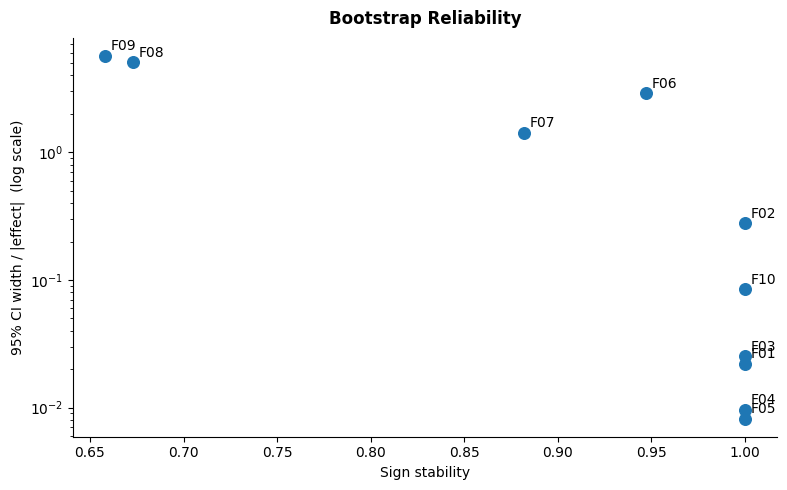

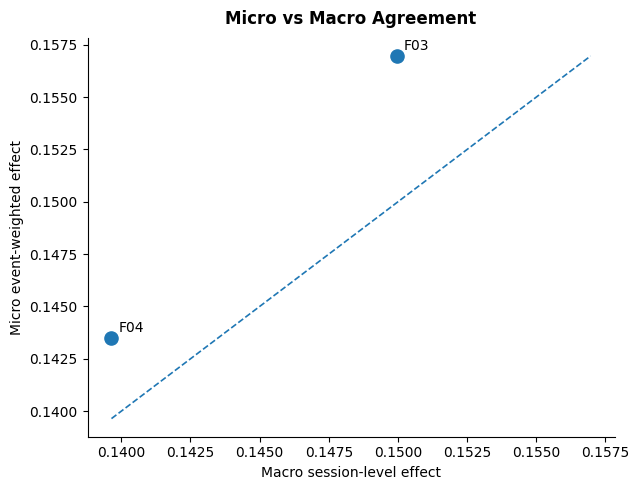

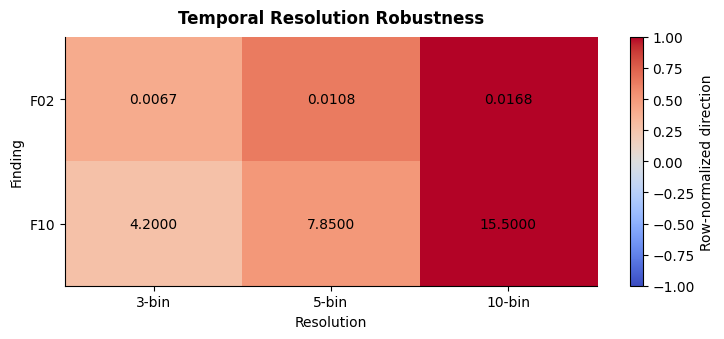

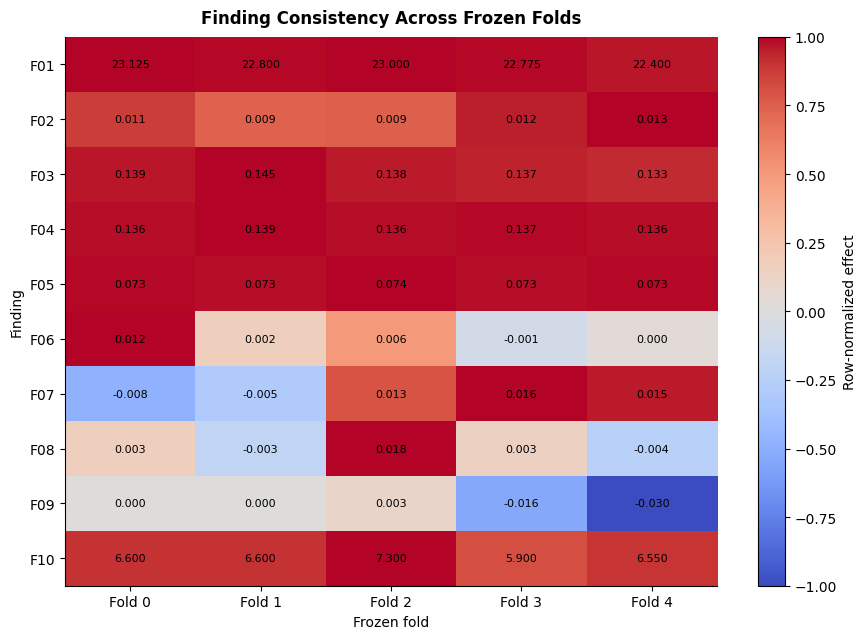

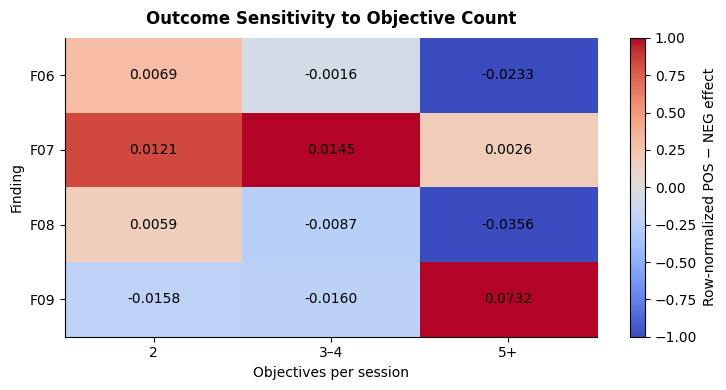

In [60]:
figs = [
    plot_bootstrap_reliability(bootstrap_results),
    plot_micro_macro(micro_macro_results),
    plot_resolution_robustness(resolution_results),
    plot_fold_consistency(fold_effects),
    plot_complexity_sensitivity(complexity_results)
]

for fig in figs:
    display(fig)
    plt.close(fig)

### 04.10 — Insight 💡

The robustness audit creates a clear separation between **stable dialogue structure** and **stable outcome discrimination**.

The major structural findings are highly reproducible. Tutor utterances retain a substantially heavier length tail than Student utterances, Student self-repetition remains dominant, repeat-turn frequency consistently exceeds repeated textual mass, and session text remains strongly concentrated in a relatively small number of turns. These findings show narrow bootstrap intervals, perfect or near-perfect direction stability, and consistent effects across all frozen folds.

The temporal findings are also directionally robust across 3 / 5 / 10-bin resolutions. Both the small Student early-to-late shift and the increase in Tutor long-tail length remain positive at every resolution, although their exact magnitudes increase as the temporal view becomes finer.

In contrast, the session outcome-context findings are weak. Positive-vs-negative differences in Student share, Student temporal shift, speaker switching, and math concentration are small, often have bootstrap intervals that cross zero, vary across frozen folds, and in several cases change direction across objective-count groups.

> **The key result is that stability and predictive usefulness are not the same thing.** The corpus contains highly reproducible structural dialogue phenomena, but those phenomena provide little stable separation between positive and negative outcomes.

These structural signals are therefore best carried forward as **session context, temporal context, packing diagnostics, and diversity diagnostics**, while the main mastery discrimination must come from **objective-conditioned evidence within the session**. 🛡️

# 04.11 — Architecture Handoff & Notebook Freeze 🧭

Okay, this is the final step of Notebook 04.

04.1 → 04.9 discovered the dialogue structure, and 04.10 tested which findings are stable.

Now we'll ask:

> **If a finding is trustworthy, what role — if any — should it have in the future architecture?**

A stable finding is **not automatically a final model feature**.

Each finding will receive:

- a final trust judgement,
- inference availability,
- claim status,
- architecture role,
- carry / diagnostic / drop decision,
- and a downstream validation requirement.

Then Notebook 04 will pass one final gate and freeze.

Let's close the notebook carefully 👇

In [61]:
FINAL_DECISIONS = pd.DataFrame([
    ["F01_tutor_student_p95_gap", "HIGH", "Large gap; narrow bootstrap CI; 5/5 folds consistent", "INFERENCE_SAFE", "TARGET_FREE", "PACKING_DIAGNOSTIC", "CARRY_FORWARD", "HIGH", "TOKENIZER_AWARE_PACKING_AUDIT", "Role-specific length pressure should guide later packing tests, not mastery scoring."],
    ["F02_student_delta_el", "HIGH", "Bootstrap and 5/5 folds stable; 3/5/10-bin direction stable; effect is small", "INFERENCE_SAFE", "TARGET_FREE", "TEMPORAL_CONTEXT", "CARRY_FORWARD", "LOW", "OOF_STRUCTURED_ABLATION", "Retain the target-free temporal signal, but treat its magnitude as small."],
    ["F03_student_self_repeat_margin", "HIGH", "Bootstrap and 5/5 folds stable; micro and macro agree", "INFERENCE_SAFE", "TARGET_FREE", "CONFIDENCE_CANDIDATE", "CARRY_FORWARD", "MEDIUM", "EVIDENCE_CONFIDENCE_ABLATION", "May indicate evidence redundancy; it is not yet a confidence-gate feature."],
    ["F04_repeat_turn_mass_gap", "HIGH", "Very narrow bootstrap CI; 5/5 folds stable; micro and macro agree", "INFERENCE_SAFE", "TARGET_FREE", "PACKING_DIAGNOSTIC", "CARRY_FORWARD", "HIGH", "PACKING_REDUNDANCY_ABLATION", "Raw repeat count overstates repeated textual mass and should inform later diversity-aware packing."],
    ["F05_top3_turn_share", "HIGH", "Extremely narrow bootstrap CI and 5/5 fold consistency", "INFERENCE_SAFE", "TARGET_FREE", "PACKING_DIAGNOSTIC", "CARRY_FORWARD", "HIGH", "TOKEN_BUDGET_PACKING_AUDIT", "A small number of turns can carry substantial context mass."],
    ["F06_outcome_student_share", "WEAK", "Tiny effect; bootstrap CI crosses zero; objective-count direction changes", "INFERENCE_SAFE", "TRAINING_ONLY_ASSOCIATION", "DROP", "DROP", "NONE", "NONE", "Student share remains computable, but its session-outcome interpretation is not reliable."],
    ["F07_outcome_student_delta", "WEAK", "Bootstrap CI crosses zero and folds disagree despite positive objective-count direction", "INFERENCE_SAFE", "TRAINING_ONLY_ASSOCIATION", "DROP", "DROP", "NONE", "NONE", "Do not create a second feature; the underlying target-free Student ΔEL already survives as F02."],
    ["F08_outcome_speaker_switch", "UNSTABLE", "Low sign stability; bootstrap CI crosses zero; folds and objective-count groups change direction", "INFERENCE_SAFE", "TRAINING_ONLY_ASSOCIATION", "DROP", "DROP", "NONE", "NONE", "Do not prioritize speaker switching as a mastery/outcome signal."],
    ["F09_outcome_math_concentration", "UNSTABLE", "Low sign stability; bootstrap CI crosses zero; strong complexity sensitivity", "INFERENCE_SAFE", "TRAINING_ONLY_ASSOCIATION", "DROP", "DROP", "NONE", "NONE", "The outcome claim is dropped; target-free math dynamics may still be studied elsewhere."],
    ["F10_tutor_p95_late_shift", "HIGH", "Bootstrap and 5/5 folds stable; 3/5/10-bin direction stable; magnitude resolution-sensitive", "INFERENCE_SAFE", "TARGET_FREE", "PACKING_DIAGNOSTIC", "CARRY_FORWARD", "HIGH", "ROLE_TIME_PACKING_AUDIT", "Tutor long-tail pressure increases later in the session and should inform packing diagnostics."],
    ["F11_archetype_stability", "HIGH", "Very high resampling stability with modest cluster separation and weak outcome association", "INFERENCE_POSSIBLE", "STRUCTURAL_DIAGNOSTIC", "SESSION_CONTEXT", "DIAGNOSTIC_ONLY", "LOW", "OPTIONAL_SESSION_CONTEXT_ABLATION", "Archetypes are reproducible structural regimes, not hard learner types or mastery classes."]
], columns=[
    "finding_id", "trust_level", "robustness_note", "signal_availability", "claim_status",
    "architecture_role", "decision", "priority", "downstream_requirement", "final_note"
])

In [62]:
EVIDENCE_COLS = [
    "finding_id", "source_section", "finding", "effect_original", "ci_low", "ci_high",
    "sign_stability", "support_sessions", "resolution_status", "positive_folds",
    "negative_folds", "complexity_status"
]

notebook04_handoff_registry = finding_trust_registry[EVIDENCE_COLS].merge(FINAL_DECISIONS, on="finding_id", validate="1:1")

display(notebook04_handoff_registry[[
    "finding_id", "source_section", "trust_level", "signal_availability", "claim_status",
    "architecture_role", "decision", "priority", "downstream_requirement"
]])

,finding_id,source_section,trust_level,signal_availability,claim_status,architecture_role,decision,priority,downstream_requirement
0,F01_tutor_student_p95_gap,04.9,HIGH,INFERENCE_SAFE,TARGET_FREE,PACKING_DIAGNOSTIC,CARRY_FORWARD,HIGH,TOKENIZER_AWARE_PACKING_AUDIT
1,F02_student_delta_el,04.5,HIGH,INFERENCE_SAFE,TARGET_FREE,TEMPORAL_CONTEXT,CARRY_FORWARD,LOW,OOF_STRUCTURED_ABLATION
2,F03_student_self_repeat_margin,04.8,HIGH,INFERENCE_SAFE,TARGET_FREE,CONFIDENCE_CANDIDATE,CARRY_FORWARD,MEDIUM,EVIDENCE_CONFIDENCE_ABLATION
3,F04_repeat_turn_mass_gap,04.8/04.9,HIGH,INFERENCE_SAFE,TARGET_FREE,PACKING_DIAGNOSTIC,CARRY_FORWARD,HIGH,PACKING_REDUNDANCY_ABLATION
4,F05_top3_turn_share,04.9,HIGH,INFERENCE_SAFE,TARGET_FREE,PACKING_DIAGNOSTIC,CARRY_FORWARD,HIGH,TOKEN_BUDGET_PACKING_AUDIT
5,F06_outcome_student_share,04.7,WEAK,INFERENCE_SAFE,TRAINING_ONLY_ASSOCIATION,DROP,DROP,NONE,NONE
6,F07_outcome_student_delta,04.7,WEAK,INFERENCE_SAFE,TRAINING_ONLY_ASSOCIATION,DROP,DROP,NONE,NONE
7,F08_outcome_speaker_switch,04.7,UNSTABLE,INFERENCE_SAFE,TRAINING_ONLY_ASSOCIATION,DROP,DROP,NONE,NONE
8,F09_outcome_math_concentration,04.7,UNSTABLE,INFERENCE_SAFE,TRAINING_ONLY_ASSOCIATION,DROP,DROP,NONE,NONE
9,F10_tutor_p95_late_shift,04.9,HIGH,INFERENCE_SAFE,TARGET_FREE,PACKING_DIAGNOSTIC,CARRY_FORWARD,HIGH,ROLE_TIME_PACKING_AUDIT


## What actually moves forward? 🚦

The registry now separates three different outcomes:

### `CARRY_FORWARD`
The finding is sufficiently justified to enter a later controlled experiment.

### `DIAGNOSTIC_ONLY`
The finding is structurally useful, but it should not currently act as a predictive candidate.

### `DROP`
The finding is not strong or stable enough to move forward from Notebook 04.

And again:

> **Carry forward ≠ final feature.**

Every carried candidate must still earn its place through later OOF or architecture-specific ablation.

In [63]:
handoff_summary = notebook04_handoff_registry.groupby(["decision", "architecture_role"], sort=False).agg(findings=("finding_id", "size"), finding_ids=("finding_id", lambda x: ", ".join(x))).reset_index()

carry_forward = notebook04_handoff_registry.loc[notebook04_handoff_registry["decision"].eq("CARRY_FORWARD"), ["finding_id", "architecture_role", "priority", "downstream_requirement"]]
diagnostic_only = notebook04_handoff_registry.loc[notebook04_handoff_registry["decision"].eq("DIAGNOSTIC_ONLY"), ["finding_id", "architecture_role", "priority", "downstream_requirement"]]
dropped_findings = notebook04_handoff_registry.loc[notebook04_handoff_registry["decision"].eq("DROP"), ["finding_id", "trust_level", "final_note"]]

display(handoff_summary)
display(carry_forward)
display(diagnostic_only)
display(dropped_findings)

,decision,architecture_role,findings,finding_ids
0,CARRY_FORWARD,PACKING_DIAGNOSTIC,4,"F01_tutor_student_p95_gap, F04_repeat_turn_mas..."
1,CARRY_FORWARD,TEMPORAL_CONTEXT,1,F02_student_delta_el
2,CARRY_FORWARD,CONFIDENCE_CANDIDATE,1,F03_student_self_repeat_margin
3,DROP,DROP,4,"F06_outcome_student_share, F07_outcome_student..."
4,DIAGNOSTIC_ONLY,SESSION_CONTEXT,1,F11_archetype_stability


,finding_id,architecture_role,priority,downstream_requirement
0,F01_tutor_student_p95_gap,PACKING_DIAGNOSTIC,HIGH,TOKENIZER_AWARE_PACKING_AUDIT
1,F02_student_delta_el,TEMPORAL_CONTEXT,LOW,OOF_STRUCTURED_ABLATION
2,F03_student_self_repeat_margin,CONFIDENCE_CANDIDATE,MEDIUM,EVIDENCE_CONFIDENCE_ABLATION
3,F04_repeat_turn_mass_gap,PACKING_DIAGNOSTIC,HIGH,PACKING_REDUNDANCY_ABLATION
4,F05_top3_turn_share,PACKING_DIAGNOSTIC,HIGH,TOKEN_BUDGET_PACKING_AUDIT
9,F10_tutor_p95_late_shift,PACKING_DIAGNOSTIC,HIGH,ROLE_TIME_PACKING_AUDIT


,finding_id,architecture_role,priority,downstream_requirement
10,F11_archetype_stability,SESSION_CONTEXT,LOW,OPTIONAL_SESSION_CONTEXT_ABLATION


,finding_id,trust_level,final_note
5,F06_outcome_student_share,WEAK,"Student share remains computable, but its sess..."
6,F07_outcome_student_delta,WEAK,Do not create a second feature; the underlying...
7,F08_outcome_speaker_switch,UNSTABLE,Do not prioritize speaker switching as a maste...
8,F09_outcome_math_concentration,UNSTABLE,The outcome claim is dropped; target-free math...


# Notebook 04 — Final Conclusions 🧠

The dialogue has clear and reproducible structure.

We found stable differences in:

- Student / Tutor interaction behaviour,
- temporal dialogue dynamics,
- exact repetition,
- role-specific utterance length,
- and session-level context concentration.

However, the robustness audit showed something equally important:

> **Stable dialogue structure does not imply strong mastery discrimination.**

The broad session-level signals showed only weak or unstable separation between positive and negative outcome contexts.

So the final architecture handoff is intentionally conservative:

```text
Stable session structure
        ↓
supporting context / confidence / packing hypotheses

Objective-conditioned evidence
        ↓
main future discrimination axis

In [64]:
session_temporal_context = session_temporal_dynamics.copy()

trajectory_summary = pd.concat([
    temporal_3.assign(resolution=3),
    temporal_5.assign(resolution=5),
    temporal_10.assign(resolution=10)
], ignore_index=True)

trajectory_cols = ["session_id", "resolution"] + [c for c in trajectory_summary.columns if c not in {"session_id", "resolution"}]
trajectory_summary = trajectory_summary[trajectory_cols]

role_transition_summary = session_role_dynamics.copy()
repetition_dynamics = session_repetition_dynamics.copy()
dialogue_archetype_summary = archetype_sizes.merge(archetype_profile_z.reset_index(), on="archetype", validate="1:1")
dialogue_signal_registry = notebook04_handoff_registry.copy()

In [65]:
ALLOWED_ROLES = {"SESSION_CONTEXT", "TEMPORAL_CONTEXT", "CONFIDENCE_CANDIDATE", "PACKING_DIAGNOSTIC", "DROP"}
ALLOWED_DECISIONS = {"CARRY_FORWARD", "DIAGNOSTIC_ONLY", "DROP"}

target_associations = notebook04_handoff_registry["claim_status"].eq("TRAINING_ONLY_ASSOCIATION")
carried = notebook04_handoff_registry["decision"].eq("CARRY_FORWARD")

checks = {
    "11_findings_frozen": len(notebook04_handoff_registry) == 11,
    "finding_ids_unique": notebook04_handoff_registry["finding_id"].is_unique,
    "trust_complete": notebook04_handoff_registry["trust_level"].notna().all(),
    "inference_status_complete": notebook04_handoff_registry["signal_availability"].notna().all(),
    "architecture_roles_valid": notebook04_handoff_registry["architecture_role"].isin(ALLOWED_ROLES).all(),
    "decisions_valid": notebook04_handoff_registry["decision"].isin(ALLOWED_DECISIONS).all(),
    "carried_findings_have_tests": notebook04_handoff_registry.loc[carried, "downstream_requirement"].ne("NONE").all(),
    "target_associations_not_carried": notebook04_handoff_registry.loc[target_associations, "decision"].eq("DROP").all(),
    "F02_retained": notebook04_handoff_registry.loc[notebook04_handoff_registry["finding_id"].eq("F02_student_delta_el"), "decision"].eq("CARRY_FORWARD").all(),
    "F07_not_duplicated": notebook04_handoff_registry.loc[notebook04_handoff_registry["finding_id"].eq("F07_outcome_student_delta"), "decision"].eq("DROP").all(),
    "F11_diagnostic_only": notebook04_handoff_registry.loc[notebook04_handoff_registry["finding_id"].eq("F11_archetype_stability"), "decision"].eq("DIAGNOSTIC_ONLY").all(),
    "local_dominance_not_carried": not notebook04_handoff_registry["finding"].str.contains("local dominance", case=False, na=False).any()
}

failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise AssertionError(f"Notebook 04 freeze gate failed: {failed}")

NOTEBOOK_04_READY = True

print("NOTEBOOK 04 FREEZE GATE : PASS ✅")
print(f"Findings               : {len(notebook04_handoff_registry)}")
print(f"Carry forward          : {(notebook04_handoff_registry['decision'] == 'CARRY_FORWARD').sum()}")
print(f"Diagnostic only        : {(notebook04_handoff_registry['decision'] == 'DIAGNOSTIC_ONLY').sum()}")
print(f"Dropped                : {(notebook04_handoff_registry['decision'] == 'DROP').sum()}")
print(f"Failed gates           : {len(failed)}")
print(f"NOTEBOOK_04_READY      : {NOTEBOOK_04_READY}")

NOTEBOOK 04 FREEZE GATE : PASS ✅
Findings               : 11
Carry forward          : 6
Diagnostic only        : 1
Dropped                : 4
Failed gates           : 0
NOTEBOOK_04_READY      : True


In [67]:
if not NOTEBOOK_04_READY:
    raise RuntimeError("Notebook 04 is not ready to freeze.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

session_temporal_context.to_parquet(OUTPUT_DIR / "session_temporal_context.parquet", index=False)
trajectory_summary.to_parquet(OUTPUT_DIR / "trajectory_summary.parquet", index=False)
role_transition_summary.to_parquet(OUTPUT_DIR / "role_transition_summary.parquet", index=False)
repetition_dynamics.to_parquet(OUTPUT_DIR / "repetition_dynamics.parquet", index=False)
dialogue_archetype_summary.to_parquet(OUTPUT_DIR / "dialogue_archetype_summary.parquet", index=False)
dialogue_signal_registry.to_parquet(OUTPUT_DIR / "dialogue_signal_registry.parquet", index=False)

findings_payload = {
    "notebook": "04_dialogue_sequence_dynamics",
    "status": "PASS",
    "notebook_04_ready": True,
    "findings": len(dialogue_signal_registry),
    "carry_forward": int(dialogue_signal_registry["decision"].eq("CARRY_FORWARD").sum()),
    "diagnostic_only": int(dialogue_signal_registry["decision"].eq("DIAGNOSTIC_ONLY").sum()),
    "dropped": int(dialogue_signal_registry["decision"].eq("DROP").sum()),
    "core_conclusion": "Dialogue structure is reproducible but provides weak general session-level mastery discrimination.",
    "next_notebook": "05_objective_evidence_geometry.ipynb"
}

with open(OUTPUT_DIR / "04_findings.json", "w", encoding="utf-8") as f:
    json.dump(findings_payload, f, indent=2, ensure_ascii=False)

print(f"Frozen outputs : {OUTPUT_DIR}")
print("Notebook 04    : FROZEN ✅")

Frozen outputs : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\scratch_mastery_outputs\02_advanced_eda\04_dialogue_sequence_dynamics
Notebook 04    : FROZEN ✅


In [69]:
EXPECTED_OUTPUTS = [
    "session_temporal_context.parquet",
    "trajectory_summary.parquet",
    "role_transition_summary.parquet",
    "repetition_dynamics.parquet",
    "dialogue_archetype_summary.parquet",
    "dialogue_signal_registry.parquet",
    "04_findings.json"
]

publication_check = pd.DataFrame({
    "artifact": EXPECTED_OUTPUTS,
    "exists": [(OUTPUT_DIR / name).exists() for name in EXPECTED_OUTPUTS]
})

if not publication_check["exists"].all():
    raise RuntimeError("Notebook 04 publication is incomplete.")

display(publication_check)

print("NOTEBOOK 04 STATUS : FROZEN ✅")
print("NEXT              : 05_objective_evidence_geometry.ipynb")

,artifact,exists
0,session_temporal_context.parquet,True
1,trajectory_summary.parquet,True
2,role_transition_summary.parquet,True
3,repetition_dynamics.parquet,True
4,dialogue_archetype_summary.parquet,True
5,dialogue_signal_registry.parquet,True
6,04_findings.json,True


NOTEBOOK 04 STATUS : FROZEN ✅
NEXT              : 05_objective_evidence_geometry.ipynb


# Notebook 04 — FROZEN ✅

Nice — the dialogue-level analysis is complete.

We now know that:

- dialogue roles behave differently,
- temporal structure is real,
- repetition is structured,
- context length is highly uneven,
- several structural findings are extremely robust,
- but broad session structure provides only weak mastery discrimination.

The retained findings are therefore **context, confidence, and packing hypotheses** — not final mastery features.

```text
NOTEBOOK 04
Dialogue Sequence Dynamics
        ↓
FROZEN ✅
        ↓
NOTEBOOK 05
Objective Evidence Geometry